# Cap. 4 — Métodos lineales para clasificación

📕 *The Elements of Statistical Learning* (Hastie, Tibshirani & Friedman), cap. 4 · págs. impresas 101–138

Este notebook explica el capítulo completo, con la cuenta hecha paso a paso y código que corre. Notación: la de ESL.

## Mapa del capítulo

| Sección | Tema | Idea central |
|---|---|---|
| 4.1 | Introducción | Clasificar = partir el espacio con fronteras; "lineal" quiere decir frontera lineal |
| 4.2 | Regresión sobre matriz indicadora | La forma más ingenua; falla por *masking* |
| 4.3 | LDA y QDA | Modelo generativo gaussiano; frontera lineal (Σ común) o cuadrática |
| 4.3.1–4.3.3 | RDA, cómputo de LDA, rango reducido | Regularizar, esferizar, proyectar a ≤ K−1 dimensiones |
| 4.4 | Regresión logística | Modelo discriminativo; ajuste por IRLS; inferencia; L1 |
| 4.5 | Hiperplanos separadores | Perceptrón y margen óptimo (puente a SVM) |
| Ejercicios 4.1–4.9 | Complementos del libro | Los citamos donde aparecen: 4.1 y 4.8 en §4.3.3, 4.2 en §4.3, 4.3 en el cierre de §4.3.3, 4.4 en §4.4.1, 4.5 en §4.4.5 y 4.6 en §4.5.1. No desarrollamos el 4.7 (sumar $D^*$ sobre todas las observaciones con $\|\beta\|=1$) ni el 4.9 (programar QDA sobre las vocales), y tampoco las notas bibliográficas |

Los datos de los libros (South African Heart Disease, vowel) no están en el repo: donde hace falta, los ejemplos usan datos simulados o de `sklearn`, y el texto lo aclara.

In [1]:
# Setup
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({
    "figure.figsize": (7, 4.5),
    "figure.dpi": 110,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## 4.1 Introducción: qué quiere decir "método lineal de clasificación"

📕 ESL §4.1 (págs. impresas 101–103)

### La idea en criollo

Hasta acá, en la regresión, la salida $Y$ era un número. Ahora la salida es una **etiqueta**: un elemento de un conjunto discreto de $K$ clases, que ESL llama $\mathcal{G}$ y numera $1, 2, \dots, K$. Nuestro predictor, $G(x)$, dice a qué clase pertenece un punto $x$.

Como $G(x)$ solo toma valores discretos, siempre podemos pensar que **partió el espacio de entrada en regiones**, una por clase. Lo que separa una región de otra es la **frontera de decisión**. En el capítulo 2 vimos que esas fronteras pueden ser rugosas (k-vecinos) o suaves (un modelo lineal).

Un método es **lineal para clasificación** cuando esas fronteras son hiperplanos: rectas en 2D, planos en 3D, y así. Nada más que eso. El capítulo entero trata de *distintas maneras de encontrar* esos hiperplanos, y las diferencias entre métodos están en **cómo se ajusta** la función lineal a los datos, no en la forma de la frontera.

> **Analogía: las fronteras entre provincias dibujadas con regla.** Si el mapa de un país se dividiera con líneas rectas, cada punto del mapa caería en una región y las regiones se tocarían a lo largo de segmentos rectos. Eso es un clasificador lineal con varias clases.
>
> **Dónde se rompe:** en un mapa de provincias las regiones las dibuja alguien a mano. Acá las rectas salen de comparar $K$ funciones ajustadas a los datos, y distintos métodos de ajuste dan rectas distintas para **los mismos datos**. El problema real es elegir bien el método de ajuste, no dibujar rectas.

> 🔗 **Conexión con la clase 1**: las "regiones" y "fronteras de decisión" de este párrafo son las $\mathcal{R}_k$ que definimos en la clase 1 (§5) al minimizar la probabilidad de error. Allá la pregunta era qué regla de asignación es óptima (la de Bayes); acá ya damos por hecha la regla "quedate con la mayor" y preguntamos qué **forma** tiene la frontera que resulta: un hiperplano. Y los k-vecinos que aparecen como contraejemplo "rugoso" son, en la taxonomía de la clase 1 (§7), una función discriminante: clasifica sin modelar ninguna probabilidad.

### Formalizándolo

#### Frontera a partir de funciones ajustadas

En el capítulo 2 ajustamos un modelo lineal a cada variable indicadora de clase y clasificamos a la clase con mayor valor ajustado. Escribimos el modelo ajustado para la clase $k$ como

$$\hat f_k(x) = \hat\beta_{k0} + \hat\beta_k^T x,$$

donde $\hat\beta_{k0}$ es el intercepto estimado (un número) y $\hat\beta_k$ el vector de coeficientes estimados (uno por variable de entrada). El sombrero indica que son estimados a partir de los datos.

La frontera entre las clases $k$ y $\ell$ es el conjunto de puntos donde ambas funciones empatan, $\hat f_k(x) = \hat f_\ell(x)$. Pasamos todo a un lado (restamos) y queda:

$$\{x : (\hat\beta_{k0} - \hat\beta_{\ell 0}) + (\hat\beta_k - \hat\beta_\ell)^T x = 0\}.$$

Fijate qué es esto: un número más un producto interno con un vector fijo, igualado a cero. Es la ecuación de un **conjunto afín** (un hiperplano que no necesita pasar por el origen). ESL aclara en una nota al pie que, estrictamente, un hiperplano pasa por el origen y un conjunto afín no, pero que a veces se ignora la diferencia. Como lo mismo vale para **cada par** de clases, el espacio queda partido en regiones de clasificación constante, con fronteras **lineales por tramos**.

#### Funciones discriminantes y posteriores

Este enfoque es un caso de una familia: modelar una **función discriminante** $\delta_k(x)$ por clase y clasificar $x$ a la clase con mayor $\delta_k(x)$. Otra familia modela las **probabilidades posteriores** $\Pr(G = k \mid X = x)$ (la probabilidad de pertenecer a la clase $k$ sabiendo que observamos $x$). Si $\delta_k(x)$ o $\Pr(G = k \mid X = x)$ son lineales en $x$, las fronteras son lineales.

Pero alcanza con menos: **alguna transformación monótona** de $\delta_k$ o del posterior tiene que ser lineal. (Una transformación monótona no cambia *cuál* de dos valores es mayor, así que no mueve la frontera.)

#### El ejemplo de dos clases: la logit

Para dos clases, un modelo popular para los posteriores es

$$\Pr(G = 1 \mid X = x) = \frac{\exp(\beta_0 + \beta^T x)}{1 + \exp(\beta_0 + \beta^T x)}, \qquad \Pr(G = 2 \mid X = x) = \frac{1}{1 + \exp(\beta_0 + \beta^T x)}. \tag{4.1}$$

Las dos probabilidades suman 1 (mismo denominador, numeradores $e^{z}$ y $1$ con $z = \beta_0 + \beta^T x$). Dividimos una por la otra: el denominador común se cancela y queda $e^{z}$. Tomando logaritmo:

$$\log \frac{\Pr(G = 1 \mid X = x)}{\Pr(G = 2 \mid X = x)} = \beta_0 + \beta^T x. \tag{4.2}$$

La transformación $\log[p/(1-p)]$ es la **logit**, y al logaritmo del cociente de probabilidades se lo llama **log-odds**. Acá la transformación monótona que se vuelve lineal es la logit. La frontera es donde las dos clases son igual de probables: cociente igual a 1, log-odds igual a cero, es decir el hiperplano $\{x \mid \beta_0 + \beta^T x = 0\}$.

#### Mapa de lo que viene

Según ESL, el capítulo presenta dos métodos muy populares que dan log-odds lineales: el **análisis discriminante lineal** (LDA) y la **regresión logística lineal**. Se derivan distinto, pero la diferencia esencial es **cómo se ajusta** la función lineal a los datos de entrenamiento.

Hay también un enfoque más directo: modelar explícitamente la frontera como hiperplano, es decir un **vector normal** (la dirección perpendicular al hiperplano) y un **punto de corte**. Se estudian dos métodos de "hiperplanos separadores": el **perceptrón** de Rosenblatt (1958), cuyo algoritmo encuentra un hiperplano separador en los datos de entrenamiento si existe, y el de Vapnik (1996), que encuentra el hiperplano **óptimamente** separador si existe, o uno que minimice algún tipo de solapamiento si no. ESL trata acá el caso separable y deja el no separable para el capítulo 12.

#### Generalizar sin salir de lo lineal

Que todo el capítulo hable de fronteras lineales no es tan restrictivo como parece. Podemos **ampliar** las variables $X_1, \dots, X_p$ agregando sus cuadrados y productos cruzados $X_1^2, X_2^2, \dots, X_1 X_2, \dots$. Son $p(p+1)/2$ variables nuevas. Una función **lineal en el espacio ampliado** es una función **cuadrática en el espacio original**, y entonces una frontera lineal ahí es una frontera cuadrática acá.

La Figura 4.1 de ESL lo ilustra con los mismos datos de tres clases: a la izquierda, fronteras lineales (por LDA) en las 2 dimensiones originales; a la derecha, fronteras lineales en el espacio de cinco dimensiones $X_1, X_2, X_1X_2, X_1^2, X_2^2$, que en el plano original se ven curvas. Esto se generaliza a cualquier **transformación de base** $h(X)$ con $h : \mathbb{R}^p \to \mathbb{R}^q$ y $q > p$, tema de capítulos posteriores.

> 🔗 **Conexión con la clase 1**: que "alguna transformación monótona no cambie cuál es la mayor" es el mismo argumento con el que en la clase 1 (§2 y §5) tirábamos el denominador de Bayes: dividir todo por el mismo número no altera el ranking, y por eso $\arg\max_k \delta_k(x)$ es la regla de Bayes cuando $\delta_k$ es monótona en la posterior. Cuidado con el vocabulario: en la clase 1 "función discriminante" era la familia 3 del §7 (SVM, k-vecinos: nada de probabilidades). Acá $\delta_k$ es más amplia: la de LDA, por ejemplo, sale de un modelo **generativo** y es el log de la posterior salvo una constante (ver §4.3, Paso 4).

### ¿Por qué nos importa?

Porque fija el vocabulario del capítulo entero y previene una confusión frecuente: "lineal" habla de **la forma de la frontera** (un hiperplano) o, más exactamente, de que **algo** (una función, o una transformación monótona del posterior) es lineal en las variables. No habla de que los datos sean linealmente separables ni de que el método sea "simple".

Además es el truco más barato para conseguir flexibilidad: si una frontera lineal no alcanza, **no cambiás de método, cambiás de variables**. Vas a ver el mismo truco en regresión polinómica, en splines y en el kernel de las SVM.

> 🔗 **Conexión con la clase 2**: es el mismo truco del §1 de la clase 2: "lineal" era en los parámetros, así que $X_1^2$, $X_1X_2$ y compañía entraban como columnas más de $\mathbf{X}$ y el modelo seguía siendo regresión lineal (una parábola en $x_1$, lineal en $\beta$). Acá lo mismo, pero para fronteras: la función es lineal en el espacio ampliado y cuadrática en el original. Lo vas a volver a usar en §4.2 para arreglar el *masking* con grado 2.

### En código

Reproducimos el fenómeno de la Figura 4.1: tres clases simuladas con LDA en las variables originales (fronteras rectas) y LDA en el espacio ampliado con $X_1^2, X_2^2, X_1X_2$ (fronteras curvas en el plano original). Usamos `LinearDiscriminantAnalysis` de sklearn porque, por ahora, lo único que nos interesa es la forma de las fronteras (la derivación de LDA llega en §4.3).

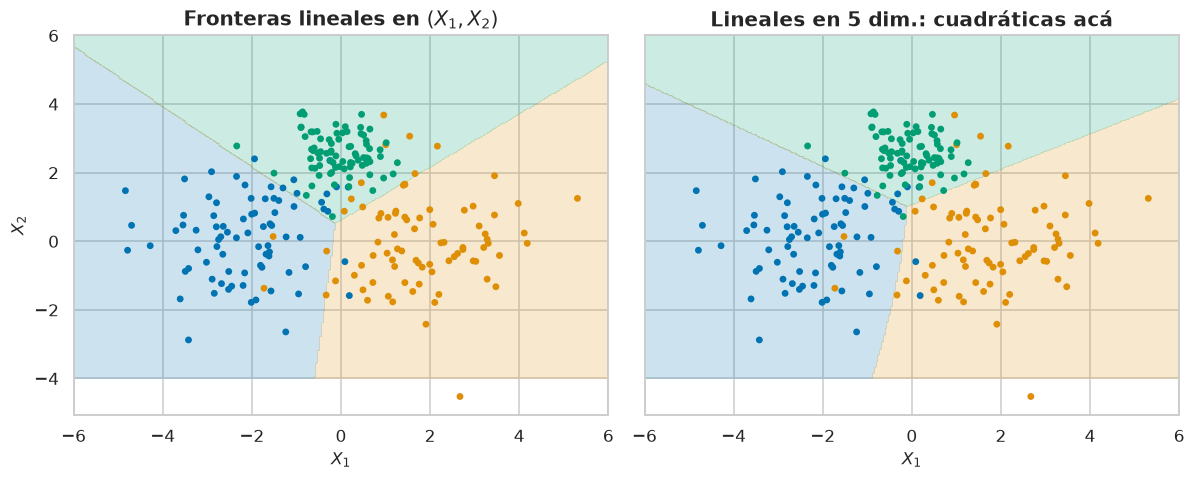

Error de entrenamiento lineal / ampliado: 0.104 0.083


In [2]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import PolynomialFeatures

rng_41 = np.random.default_rng(0)
# Tres nubes: dos con mucha dispersion y una en el medio mas chica, para que la curvatura ayude.
centros_41 = np.array([[-2.0, 0.0], [2.0, 0.0], [0.0, 2.5]])
escalas_41 = np.array([1.2, 1.2, 0.6])
X_41 = np.vstack([c + e * rng_41.standard_normal((80, 2)) for c, e in zip(centros_41, escalas_41)])
g_41 = np.repeat([0, 1, 2], 80)

# poly2 agrega X1^2, X1*X2, X2^2 (sin la columna de unos: LDA ya tiene intercepto).
poly_41 = PolynomialFeatures(2, include_bias=False)
lda_lin_41 = LinearDiscriminantAnalysis().fit(X_41, g_41)
lda_cuad_41 = LinearDiscriminantAnalysis().fit(poly_41.fit_transform(X_41), g_41)

u_41, v_41 = np.meshgrid(np.linspace(-6, 6, 300), np.linspace(-4, 6, 300))
malla_41 = np.c_[u_41.ravel(), v_41.ravel()]
pred_41 = [lda_lin_41.predict(malla_41), lda_cuad_41.predict(poly_41.transform(malla_41))]

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
titulos_41 = ["Fronteras lineales en $(X_1, X_2)$", "Lineales en 5 dim.: cuadráticas acá"]
for ax, p, t in zip(axes, pred_41, titulos_41):
    ax.contourf(u_41, v_41, p.reshape(u_41.shape), alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5],
                colors=sns.color_palette("colorblind", 3))
    ax.scatter(*X_41.T, c=[sns.color_palette("colorblind")[i] for i in g_41], s=12)
    ax.set_title(t); ax.set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")
plt.tight_layout(); plt.show()
print("Error de entrenamiento lineal / ampliado:",
      (lda_lin_41.predict(X_41) != g_41).mean().round(3),
      (lda_cuad_41.predict(poly_41.transform(X_41)) != g_41).mean().round(3))

A la izquierda las tres regiones se tocan en rectas. A la derecha las mismas tres clases, con el **mismo método** (LDA, que sigue buscando fronteras lineales), tienen fronteras curvas, porque la linealidad vive en el espacio de cinco variables. Como la nube del medio es más compacta que las de los costados, una frontera curva la rodea mejor y el error de entrenamiento baja un poco (de 0.10 a 0.08 en esta semilla; la ganancia es modesta porque los datos son casi lineales).

Ahora verificamos la ecuación (4.2): en regresión logística de dos clases, los log-odds de las probabilidades predichas **son** una función lineal de $x$.

In [3]:
from sklearn.linear_model import LogisticRegression

mask_41 = g_41 < 2                                    # nos quedamos con dos clases
X2_41, y2_41 = X_41[mask_41], g_41[mask_41]
logit_41 = LogisticRegression(C=1e6).fit(X2_41, y2_41)  # C enorme: casi sin regularizar

p1_41 = logit_41.predict_proba(X2_41)[:, 1]             # Pr(G = 'clase 1' | x)
log_odds_41 = np.log(p1_41 / (1 - p1_41))               # la logit de las probabilidades
lineal_41 = logit_41.intercept_[0] + X2_41 @ logit_41.coef_[0]  # beta_0 + beta^T x

print("log-odds == beta0 + beta^T x :", np.allclose(log_odds_41, lineal_41))
# La frontera es donde el log-odds vale 0, o sea donde Pr = 1/2:
cerca_41 = np.argsort(np.abs(lineal_41))[:5]             # los 5 puntos mas cercanos a la frontera
print("Pr en los 5 puntos mas cercanos a la frontera:", p1_41[cerca_41].round(2))

log-odds == beta0 + beta^T x : True
Pr en los 5 puntos mas cercanos a la frontera: [0.48 0.57 0.6  0.38 0.65]


### ⚠️ Confusión típica

Creer que "método lineal" significa "solo sirve si las clases se separan con una recta". Lo lineal es la **frontera en el espacio donde el método trabaja**. Si ampliás ese espacio con cuadrados y productos cruzados, el mismo método lineal dibuja fronteras curvas en el espacio original, como en la celda de arriba.

Segunda confusión: pensar que la frontera de un modelo de $K$ clases es *un* hiperplano. Es **lineal por tramos**: entre cada par de clases hay un hiperplano, y las regiones quedan delimitadas por los trozos que realmente son frontera de dos clases vecinas.

## 4.2 Regresión lineal de una matriz indicadora

📕 ESL §4.2 (págs. impresas 103–107)

### La idea en criollo

Es el método más ingenuo de clasificación lineal, y por eso es el mejor punto de partida. Si la regresión sabe predecir un número, y las clases son etiquetas, **convertimos las etiquetas en números**: para cada clase armamos una columna de ceros y unos que vale 1 si la observación es de esa clase. Ajustamos una regresión lineal por columna. Para un punto nuevo miramos las $K$ predicciones y gana la clase con la predicción más alta.

La pregunta que queda es si esto anda bien. Este apartado muestra que **anda razonablemente con 2 clases y falla de una manera específica y fea con 3 o más**: el *enmascaramiento* (masking).

> **Analogía: $K$ jueces independientes, cada uno con una regla rígida.** Cada juez mira un punto y puntúa "qué tan de mi clase parece". Gana el juez con mayor puntaje.
>
> **Dónde se rompe:** los jueces no se enteran unos de otros y cada uno solo puede puntuar con una recta. Si una clase queda *en el medio* de las otras, su juez solo dispone de una recta que, por simetría, queda casi plana y baja, y nunca supera a los puntajes de los jueces de los extremos.

### Formalizándolo

#### La matriz indicadora y el ajuste

Si $G$ tiene $K$ clases, definimos $K$ **variables indicadoras** $Y_k$, con $k = 1, \dots, K$:

$$Y_k = 1 \text{ si } G = k, \qquad Y_k = 0 \text{ en otro caso.}$$

Las juntamos en el vector $Y = (Y_1, \dots, Y_K)$. Con los $N$ casos de entrenamiento armamos la **matriz de respuesta indicadora** $\mathbf{Y}$, de tamaño $N \times K$: todo ceros y unos, con **un único 1 por fila** (la columna de la clase de esa observación).

Ajustamos una regresión lineal a **cada columna** de $\mathbf{Y}$ a la vez. Con $\mathbf{X}$ la matriz de diseño, $N \times (p+1)$, con una primera columna de unos para el intercepto, el ajuste es

$$\hat{\mathbf{Y}} = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}. \tag{4.3}$$

Es la misma fórmula del capítulo 3 (ESL §3.2), pero con $\mathbf{y}$ reemplazado por una matriz. Cada columna de $\mathbf{Y}$ tiene su propio vector de coeficientes, así que los coeficientes forman una matriz $\hat{\mathbf{B}} = (\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}$ de tamaño $(p+1) \times K$. (Multiplicar $(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ por $\mathbf{Y}$ aplica la misma operación a cada columna por separado.)

**Regla de clasificación** para una observación nueva con entrada $x$:

1. Calculamos el **vector ajustado** $\hat f(x)^T = (1, x^T)\hat{\mathbf{B}}$, un vector de $K$ componentes.
2. Nos quedamos con la componente más grande:

$$\hat G(x) = \arg\max_{k \in \mathcal{G}} \hat f_k(x). \tag{4.4}$$

($\arg\max$ quiere decir "el $k$ donde se alcanza el máximo", no el valor del máximo.)

> 🔗 **Conexión con las clases 2 y 3**: (4.3) es la ecuación normal de la clase 2 con $\mathbf{y}$ reemplazado por una matriz, o sea $\hat{\mathbf{Y}}=\mathbf{H}\mathbf{Y}$ con la **misma** matriz sombrero $\mathbf{H}=\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T$ (§3 de la clase 2; $UU^T$ en términos de la SVD de la clase 3): proyecta cada columna de $\mathbf{Y}$ sobre el mismo subespacio, porque $\mathbf{H}$ solo depende de $\mathbf{X}$. Y que el criterio (4.5) se parta en $K$ problemas independientes es la norma al cuadrado del $RSS$ de la clase 2 sumada columna por columna.

#### ¿Con qué justificación? Esperanza condicional

Una justificación formal: ver la regresión como **estimación de una esperanza condicional**. Como $Y_k$ vale 1 o 0,

$$E(Y_k \mid X = x) = 1 \cdot \Pr(Y_k = 1 \mid X = x) + 0 \cdot \Pr(Y_k = 0 \mid X = x) = \Pr(G = k \mid X = x).$$

Es decir, estimar la esperanza condicional de cada indicador **es** estimar el posterior de la clase. Objetivo razonable. El problema real, dice ESL, es qué tan buena aproximación a esa esperanza es un modelo **tan rígido** como el lineal. O dicho de otra forma: ¿son los $\hat f_k(x)$ estimaciones razonables de los posteriores y, más importante, importa que lo sean?

#### Las $\hat f_k(x)$ suman 1 (con intercepto)

Se verifica en tres líneas. Llamemos $\mathbf{1}_N$ al vector de $N$ unos y $\mathbf{1}_K$ al de $K$ unos. Como cada fila de $\mathbf{Y}$ tiene un único 1, sumar las columnas da $\mathbf{Y}\mathbf{1}_K = \mathbf{1}_N$. Entonces, sumando las $K$ columnas del ajuste:

$$\hat{\mathbf{Y}}\mathbf{1}_K = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{Y}\mathbf{1}_K = \mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{1}_N.$$

Acá usamos que hay un intercepto: la primera columna de $\mathbf{X}$ es $\mathbf{1}_N$, o sea $\mathbf{X}e_0 = \mathbf{1}_N$ con $e_0 = (1, 0, \dots, 0)^T$ (el vector que elige esa columna). Reemplazando, $\mathbf{X}^T\mathbf{1}_N = \mathbf{X}^T\mathbf{X}e_0$, y los factores se cancelan:

$$\mathbf{X}(\mathbf{X}^T\mathbf{X})^{-1}\mathbf{X}^T\mathbf{X}e_0 = \mathbf{X}e_0 = \mathbf{1}_N.$$

Así, para **cada observación de entrenamiento**, $\sum_k \hat f_k = 1$. Lo mismo vale para cualquier $x$ porque $\hat f(x)^T\mathbf{1}_K = (1, x^T)\hat{\mathbf{B}}\mathbf{1}_K$ y $\hat{\mathbf{B}}\mathbf{1}_K = e_0$ por el mismo argumento, lo que da $(1, x^T)e_0 = 1$.

**Pero** los $\hat f_k(x)$ pueden ser negativos o mayores que 1, y típicamente algunos lo son. Es consecuencia de la rigidez de la regresión lineal, sobre todo al predecir fuera de la **envoltura convexa** (el "cascarón" más chico que contiene) de los datos de entrenamiento. Suman 1 pero **no son probabilidades**.

ESL aclara que estas violaciones no garantizan que el método falle: en muchos problemas da resultados parecidos a los de métodos lineales más estándar. Y si se hace regresión lineal sobre **expansiones de base** $h(X)$ de las entradas, el método puede dar estimaciones **consistentes** de las probabilidades: a medida que crece $N$, se incluyen adaptativamente más elementos de base y la regresión se acerca a la esperanza condicional. Eso se discute en el capítulo 5.

> 🔗 **Conexión con las clases 1 y 2**: la igualdad $E(Y_k\mid X=x)=\Pr(G=k\mid X=x)$ es la misma cuenta que hicimos en la clase 1 (§4) para una $Y$ binaria, donde dijimos que era "el puente exacto" entre clasificación y regresión. Y como bajo pérdida cuadrática el óptimo es la media condicional (clase 1, §8), la regresión sobre indicadoras es la "opción 3" de ese §8 (modelar directo $E[Y\mid X]$, sin ninguna distribución) aplicada a cada columna de $\mathbf{Y}$ con el supuesto de la clase 2: que esa esperanza es lineal en $x$. Acá el problema es que la posterior, una probabilidad, difícilmente sea lineal en todo el rango de $x$.

> 🔗 **Conexión con las clases 2 y 3**: la cuenta de "suman 1" es un caso de algo que ya usamos: $\mathbf{H}$ proyecta sobre el espacio columna de $\mathbf{X}$ y deja fijo todo vector que ya esté ahí (en la clase 3 lo escribimos como $(I-\mathbf{H})\mathbf{X}=0$). Con intercepto, $\mathbf{1}_N$ **es** una columna de $\mathbf{X}$, así que $\mathbf{H}\mathbf{1}_N=\mathbf{1}_N$ y $\hat{\mathbf{Y}}\mathbf{1}_K=\mathbf{H}\mathbf{Y}\mathbf{1}_K=\mathbf{H}\mathbf{1}_N=\mathbf{1}_N$. Sin intercepto esa columna no está y la propiedad se cae.

#### Segundo punto de vista: reproducir el objetivo

Un punto de vista más simple: para cada clase construimos un **objetivo** $t_k$, la $k$-ésima columna de la matriz identidad $K \times K$ (un vector con un 1 en la posición $k$ y ceros en el resto). Para la observación $i$, su fila de $\mathbf{Y}$ es $y_i = t_k$ si $g_i = k$. Buscamos reproducir el objetivo correcto, ajustando por cuadrados mínimos:

$$\min_{\mathbf{B}} \sum_{i=1}^N \| y_i - [(1, x_i^T)\mathbf{B}]^T \|^2. \tag{4.5}$$

El criterio es una suma de **distancias euclídeas al cuadrado** entre los vectores ajustados y sus objetivos. Una observación nueva se clasifica al **objetivo más cercano**:

$$\hat G(x) = \arg\min_k \|\hat f(x) - t_k\|^2. \tag{4.6}$$

ESL afirma que esto es **exactamente lo mismo** que antes, por dos razones:

1. **El criterio (4.5) es el de regresión múltiple.** La norma al cuadrado es ella misma una suma de cuadrados, $\|y_i - \hat f\|^2 = \sum_{k=1}^K (y_{ik} - \hat f_k)^2$. La suma sobre $i$ y sobre $k$ se puede reordenar como $K$ sumas independientes, una por columna, cada una un problema de cuadrados mínimos que involucra solo la columna $k$ de $\mathbf{B}$. Esto es posible **solo porque nada en el modelo liga las respuestas entre sí**: cada una tiene sus propios coeficientes.
2. **La regla (4.6) es la regla (4.4).** Como $t_k$ tiene un 1 en la posición $k$ y ceros en las otras, $\|\hat f - t_k\|^2 = \sum_j \hat f_j^2 - 2\hat f_k + 1$. El primer y el último término **no dependen de $k$**, así que minimizar esto es maximizar $\hat f_k$.

### ¿Por qué nos importa?

Es la vara de comparación del capítulo. Se implementa con un solo ajuste de cuadrados mínimos, y sus fallas son instructivas: explican por qué **hacen falta** LDA y regresión logística.  La idea de codificar clases como objetivos vectoriales sirve para entender qué hace cada método con las mismas salidas.

### En código

Primero, a mano con numpy: matriz indicadora, $\hat{\mathbf{B}}$ por cuadrados mínimos, las tres propiedades (suma 1, valores fuera de $[0, 1]$, equivalencia argmax/argmin) y, al final, la versión de librería. Usamos los mismos datos de tres clases que armamos en §4.1.

In [4]:
K_42 = 3
N_42 = len(g_41)
X_42 = np.c_[np.ones(N_42), X_41]                  # columna de unos para el intercepto
Y_42 = np.eye(K_42)[g_41]                          # matriz indicadora N x K: un 1 por fila

# B_hat = (X^T X)^{-1} X^T Y, pero con lstsq para no invertir nada (ver §3.2 de ESL).
B_42, *_ = np.linalg.lstsq(X_42, Y_42, rcond=None)  # (p+1) x K: una columna de coef. por clase
Yhat_42 = X_42 @ B_42                               # ajuste (4.3)

print("forma de Y:", Y_42.shape, "| forma de B:", B_42.shape)
print("filas de Y suman 1:", np.allclose(Y_42.sum(axis=1), 1))
print("filas de Y_hat suman 1 (hay intercepto):", np.allclose(Yhat_42.sum(axis=1), 1))
print(f"rango de f_hat: [{Yhat_42.min():.2f}, {Yhat_42.max():.2f}]  "
      f"-> fuera de [0,1]: {((Yhat_42 < 0) | (Yhat_42 > 1)).mean():.1%} de las entradas")

G_argmax_42 = Yhat_42.argmax(axis=1)                              # regla (4.4)
G_target_42 = ((Yhat_42[:, None, :] - np.eye(K_42)) ** 2).sum(-1).argmin(axis=1)  # regla (4.6)
print("(4.4) == (4.6):", np.array_equal(G_argmax_42, G_target_42))
print("error de entrenamiento:", (G_argmax_42 != g_41).mean().round(3))

forma de Y: (240, 3) | forma de B: (3, 3)
filas de Y suman 1: True
filas de Y_hat suman 1 (hay intercepto): True
rango de f_hat: [-0.84, 1.50]  -> fuera de [0,1]: 21.9% de las entradas
(4.4) == (4.6): True
error de entrenamiento: 0.088


> 🔗 **Conexión con las clases 2 y 3**: fijate que el código usa `lstsq` y no la fórmula con `inv`: es lo que vimos en la clase 2 (§2), donde $(\mathbf{X}^T\mathbf{X})^{-1}$ es notación y no receta. La razón de fondo está en la clase 3 (§5): armar $\mathbf{X}^T\mathbf{X}$ eleva al cuadrado el número de condición. Lo mismo vale para el `solve` del IRLS de §4.4.1.

##### 🏭 Así se hace en la industria

En sklearn, `LinearRegression` acepta una respuesta multi-columna y ajusta una regresión por columna. Es exactamente el $\hat{\mathbf{B}}$ de arriba (sklearn separa el intercepto, pero es el mismo modelo).

In [5]:
from sklearn.linear_model import LinearRegression

reg_42 = LinearRegression().fit(X_41, Y_42)        # sklearn agrega el intercepto solo
B_sk_42 = np.vstack([reg_42.intercept_, reg_42.coef_.T])  # apilamos para comparar con B_42
print("coeficientes iguales:", np.allclose(B_42, B_sk_42))
print("clasificaciones iguales:", np.array_equal(reg_42.predict(X_41).argmax(axis=1), G_argmax_42))

coeficientes iguales: True
clasificaciones iguales: True


#### El problema del enmascaramiento (masking)

Para $K \ge 3$ hay un problema serio, sobre todo cuando $K$ es grande. Por la rigidez del modelo, **unas clases pueden quedar enmascaradas por otras**. La Figura 4.2 de ESL muestra un caso extremo con $K = 3$: tres clases en $\mathbb{R}^2$ perfectamente separables con fronteras lineales, y sin embargo la regresión lineal de los indicadores **no encuentra nunca** la clase del medio (nunca domina). LDA, en cambio, separa las tres bien.

La Figura 4.3 lo explica en una dimensión. Se proyectan los datos sobre la recta que une los tres centroides (en ese ejemplo no hay información en la dirección ortogonal) y se codifican las tres respuestas $Y_1, Y_2, Y_3$. Las tres rectas de regresión salen así: la de la clase del medio es **horizontal** y sus valores ajustados **nunca son los mayores**, así que las observaciones de la clase 2 se clasifican como clase 1 o clase 3. Con regresión **cuadrática** en vez de lineal, el problema se resuelve en este ejemplo (error de entrenamiento 0.33 con grado 1 y 0.04 con grado 2 en la figura del libro; el error de Bayes es 0.025, igual al de LDA).

Según ESL, con cuatro clases alineadas así una cuadrática no "baja" lo bastante rápido y se necesitaría una cúbica. La regla general, laxa según ESL: si hay $K \ge 3$ clases alineadas, pueden hacer falta **términos polinómicos hasta grado $K-1$**. Son polinomios a lo largo de la dirección derivada que pasa por los centroides, y esa dirección puede tener orientación arbitraria. En un espacio de entrada de dimensión $p$, resolver el peor caso exigiría términos polinómicos generales y productos cruzados de grado total $K-1$: $O(p^{K-1})$ términos.

Reproducimos primero la Figura 4.3 (una dimensión, tres clases) con grados 1 y 2.

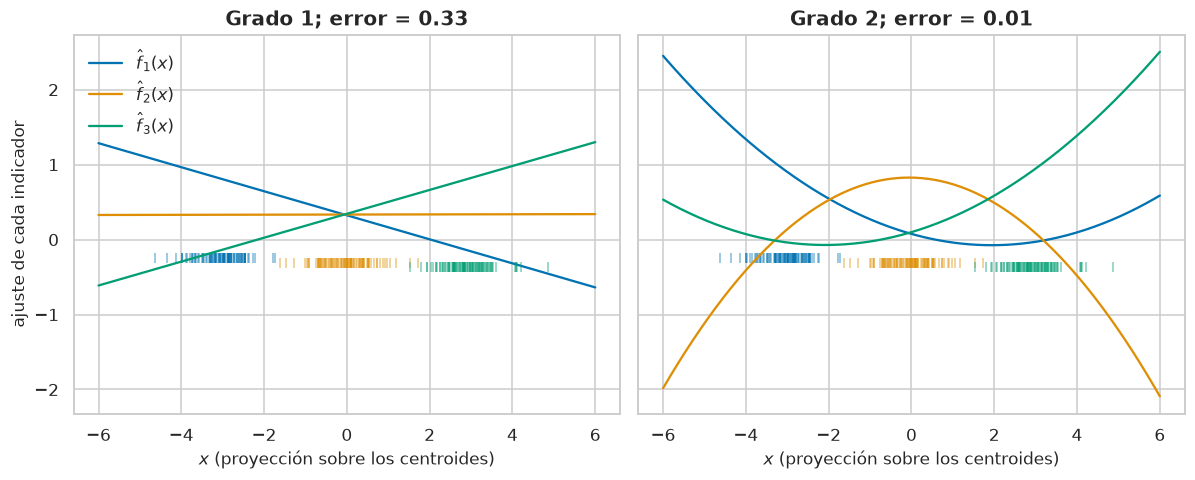

In [6]:
from sklearn.preprocessing import PolynomialFeatures as PF

def masking_1d_42(K, sep=3.0, n=100, sd=0.6, seed=1):
    # K clases alineadas en una recta, equiespaciadas y centradas en 0.
    r = np.random.default_rng(seed)
    centros = (np.arange(K) - (K - 1) / 2) * sep
    x = np.concatenate([c + sd * r.standard_normal(n) for c in centros])
    return x[:, None], np.repeat(np.arange(K), n)

def ajustar_42(x, g, grado):
    F = PF(grado, include_bias=False).fit_transform(x)   # 1, x, x^2, ... (regresion polinomica)
    m = LinearRegression().fit(F, np.eye(g.max() + 1)[g])  # una regresion por indicador
    return m, (m.predict(F).argmax(1) != g).mean()

x3_42, g3_42 = masking_1d_42(3)
xs_42 = np.linspace(-6, 6, 400)[:, None]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, d in zip(axes, [1, 2]):
    m, err = ajustar_42(x3_42, g3_42, d)
    curvas = m.predict(PF(d, include_bias=False).fit_transform(xs_42))
    for k in range(3):
        ax.plot(xs_42, curvas[:, k], label=f"$\\hat f_{k+1}(x)$")
        ax.plot(x3_42[g3_42 == k], np.full((g3_42 == k).sum(), -0.25 - 0.06 * k), "|",
                color=sns.color_palette("colorblind")[k], alpha=0.5)   # rug plot
    ax.set_title(f"Grado {d}; error = {err:.2f}"); ax.set_xlabel("$x$ (proyección sobre los centroides)")
axes[0].set_ylabel("ajuste de cada indicador"); axes[0].legend()
plt.tight_layout(); plt.show()

A la izquierda, con grado 1, la recta de la clase 2 (la del medio) queda casi horizontal, en $\approx 1/3$: por simetría las tres rectas se cruzan en $x = 0$ en ese valor, y la clase 2 solo gana en un punto. A la derecha, con grado 2, la clase 2 tiene una parábola con un pico en el centro y las tres clases se separan. El error pasa de 0.33 (un tercio de las observaciones, toda la clase del medio) a cerca de 0.01. Es el mismo fenómeno de la Figura 4.3, con datos simulados por nosotros.

Ahora el aviso de "grado $K-1$": con $K = 4$ clases alineadas, ¿qué grados hacen falta en nuestra simulación?

In [7]:
x4_42, g4_42 = masking_1d_42(4, sep=3.0, sd=0.5)
for d in [1, 2, 3]:
    m, err = ajustar_42(x4_42, g4_42, d)
    F = PF(d, include_bias=False).fit_transform(x4_42)
    pred = m.predict(F).argmax(1)
    frec = np.bincount(pred, minlength=4) / len(pred)
    print(f"K=4, grado {d}: error = {err:.3f} | fracción predicha por clase = {frec.round(2)}")

K=4, grado 1: error = 0.500 | fracción predicha por clase = [0.5 0.  0.  0.5]
K=4, grado 2: error = 0.007 | fracción predicha por clase = [0.25 0.24 0.25 0.25]
K=4, grado 3: error = 0.007 | fracción predicha por clase = [0.24 0.26 0.25 0.25]


Con grado 1 las dos clases de adentro quedan completamente tapadas: toda la predicción se reparte entre las dos de los costados (fracción 0.5 y 0.5, error 0.5). Con grado 2 ya aparecen las cuatro. Ojo con esto: la regla de ESL del grado $K-1 = 3$ es **laxa**, una cota de lo que *podría* hacer falta en el peor caso. En nuestro ejemplo las clases están equiespaciadas, con el mismo desvío y casi sin solapamiento (separación 3.0, desvío 0.5): es el caso más amable posible, y con grado 2 cada parábola se acomoda lo bastante cerca de su clase. Eso **no refuta** a ESL: el libro no afirma que siempre haga falta grado $K-1$, sino que puede hacer falta. Probá cambiar `sep` y `sd` en la celda anterior: con `sep=1.5` y `sd=0.5` el error con grado 2 es de cerca de 0.07 y con grado 3 sigue ahí (0.08), porque a esa altura las clases ya se solapan de verdad y lo que queda no es *masking* sino error que esos datos no permiten bajar. La regla del grado $K-1$ habla del peor caso del *masking*, no de ese solapamiento. Lo que la simulación sí confirma es lo central: **los grados bajos enmascaran**, y con $K = 3$ o $K = 4$ el grado 1 nunca alcanza.

Por último, la versión bidimensional (Figura 4.2): tres clases en el plano a lo largo de una recta, separables, y las regiones de decisión de regresión lineal frente a las de LDA.

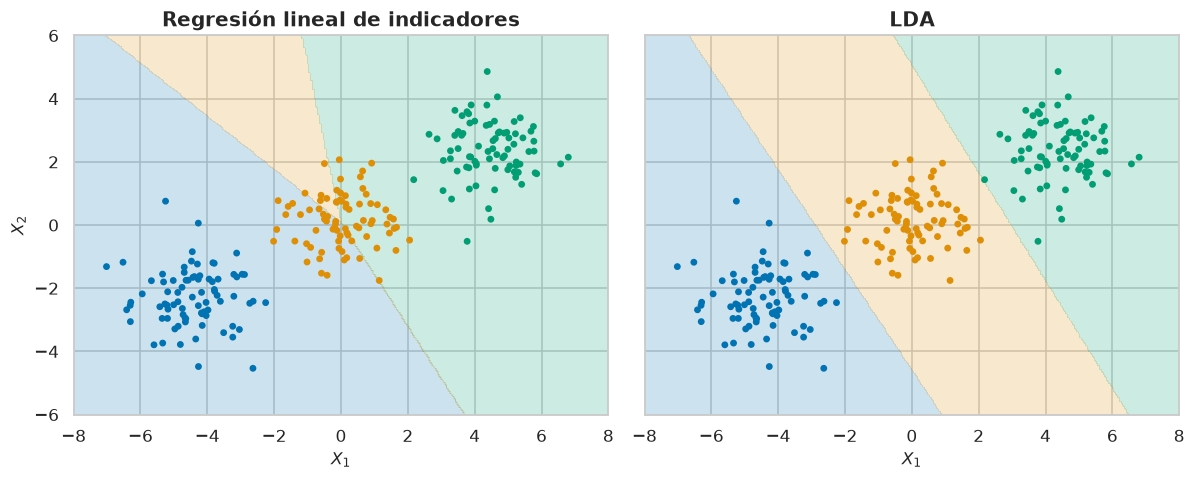

error regresión: 0.304 | error LDA: 0.0


In [8]:
rng_2d_42 = np.random.default_rng(3)
dir_42 = np.array([1.0, 0.5]) / np.hypot(1.0, 0.5)   # direccion sobre la que se alinean las clases
cent_42 = np.array([-5.0, 0.0, 5.0])[:, None] * dir_42
X2d_42 = np.vstack([c + 0.9 * rng_2d_42.standard_normal((80, 2)) for c in cent_42])
g2d_42 = np.repeat([0, 1, 2], 80)

reg2d_42 = LinearRegression().fit(X2d_42, np.eye(3)[g2d_42])
lda2d_42 = LinearDiscriminantAnalysis().fit(X2d_42, g2d_42)
a_42, b_42 = np.meshgrid(np.linspace(-8, 8, 300), np.linspace(-6, 6, 300))
M_42 = np.c_[a_42.ravel(), b_42.ravel()]
pcol_42 = sns.color_palette("colorblind", 3)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
for ax, pred, t in zip(axes, [reg2d_42.predict(M_42).argmax(1), lda2d_42.predict(M_42)],
                       ["Regresión lineal de indicadores", "LDA"]):
    ax.contourf(a_42, b_42, pred.reshape(a_42.shape), alpha=0.2, levels=[-0.5, 0.5, 1.5, 2.5], colors=pcol_42)
    ax.scatter(*X2d_42.T, c=[pcol_42[i] for i in g2d_42], s=12)
    ax.set_title(t); ax.set_xlabel("$X_1$")
axes[0].set_ylabel("$X_2$")
plt.tight_layout(); plt.show()
print("error regresión:", (reg2d_42.predict(X2d_42).argmax(1) != g2d_42).mean().round(3),
      "| error LDA:", (lda2d_42.predict(X2d_42) != g2d_42).mean().round(3))

En el panel de la izquierda la clase del medio casi no tiene región propia: la regresión la ignora, pese a que las tres nubes están bien separadas por rectas. En el panel de la derecha LDA dibuja tres regiones. Mismo dato, misma forma de frontera (lineal), distinto método de ajuste: es justamente lo que anunció §4.1.

#### Un ejemplo realista: los datos de vocales

Como ilustración menos extrema, ESL (Figura 4.4) proyecta los datos de entrenamiento de un problema de **reconocimiento de vocales** sobre un subespacio bidimensional informativo. Hay $K = 11$ clases en $p = 10$ dimensiones. Es un problema difícil: los mejores métodos logran alrededor de 40% de error en test. La Tabla 4.1 del libro resume el resultado (error de entrenamiento y de test, con los mismos datos):

| Método | Entrenamiento | Test |
|---|---|---|
| Regresión lineal | 0.48 | 0.67 |
| LDA | 0.32 | 0.56 |
| QDA | 0.01 | 0.53 |
| Regresión logística | 0.22 | 0.51 |

Los 67% y 56% de los que hablamos son los de **test**. ESL lo lee así: la regresión lineal sale perjudicada por el enmascaramiento, con errores de entrenamiento y de test más de un 10% mayores (el texto del caption, tal cual). Dos datos más del caption: de las diez dimensiones, tres concentran el 90% de la varianza (por componentes principales), o sea que las once clases viven casi en un subespacio chico. Y fijate en QDA: 1% de error de entrenamiento y 53% en test, el sobreajuste de tener una covarianza por clase (la cuenta de parámetros viene más abajo, en §4.3). Todos los demás métodos del capítulo también usan funciones lineales de $x$, pero de un modo que **evita** el enmascaramiento. No reproducimos ese conjunto porque no viene con sklearn y no descargamos datos de internet. La simulación de arriba ya muestra el mecanismo: clases alineadas y pocas dimensiones para acomodarlas.

### ⚠️ Confusión típica

Interpretar $\hat f_k(x)$ como "probabilidad de la clase $k$". Suman 1, pero pueden ser negativos o mayores que 1, y la celda de arriba lo mostró con números. Sirven para **elegir la clase** con el argmax, no como probabilidades calibradas.

Segunda: creer que si la regresión falla con tres clases es un problema de "el modelo es poco flexible en $x$" y se arregla con más datos. No: el problema es estructural. Con $N \to \infty$ la recta de la clase del medio sigue siendo plana. Se arregla cambiando la base (grado $K-1$), el método (LDA, logística) o ambos.

Tercera: pensar que con 2 clases se nota el problema. Con $K = 2$ las dos columnas de $\mathbf{Y}$ suman 1 y $\hat f_2 = 1 - \hat f_1$: comparar entre clases equivale a una sola regresión con umbral en $1/2$. No hay "medio" para enmascarar.

### ❓ La pregunta que quedó abierta

ESL plantea al comienzo de la sección: ¿son los $\hat f_k(x)$ buenas estimaciones de los posteriores y, **más importante, importa que lo sean**? La respuesta parcial del libro: no son buenos estimadores (se salen de $[0,1]$), pero esa violación por sí sola no rompe la clasificación, que solo necesita el **orden** entre las $\hat f_k$. Lo que sí la rompe es el enmascaramiento, que aparece cuando las clases se alinean. Las soluciones que propone ESL en adelante son LDA (§4.3) y regresión logística (§4.4), que usan funciones lineales evitando el problema, y la expansión de base (capítulo 5).

## 4.3 Análisis discriminante lineal (LDA) y cuadrático (QDA)

📕 ESL §4.3 (texto principal, antes de §4.3.1)

### La idea en criollo

Hasta ahora modelamos $\Pr(G\mid X)$ directamente (regresión sobre indicadores, y en §4.4 la logística). Acá damos vuelta el problema: modelamos **cómo se ven los datos dentro de cada clase** y después usamos Bayes para obtener la probabilidad de cada clase.

La receta tiene tres pasos:

1. Suponés que dentro de cada clase los predictores $X$ siguen una distribución normal multivariada (una "nube" elíptica).
2. Estimás de los datos el centro de cada nube, su forma y cuánto pesa cada clase.
3. Para un punto nuevo, preguntás: "¿qué clase lo vuelve más plausible, contando también qué tan frecuente es esa clase?".

La diferencia entre LDA y QDA es una sola pregunta: **¿las nubes tienen todas la misma forma (misma matriz de covarianza) o cada una tiene la suya?** Si comparten forma, las fronteras entre clases resultan rectas (hiperplanos). Si no, resultan curvas cuadráticas.

> **Analogía: tres barrios en un mapa.** Pensá en tres barrios con sus casas dibujadas en un mapa. Cada barrio es una mancha ovalada de casas. Un punto nuevo lo asignás al barrio cuya mancha lo "explica" mejor, ponderando por cuántas casas tiene cada barrio.
>
> **Dónde se rompe la analogía.** Las manchas de un mapa tienen borde nítido. Acá cada clase tiene una densidad que decae suave hacia el infinito: todas las clases "llegan" a todos los puntos, sólo que con probabilidades distintas. Por eso la frontera no es un borde de barrio, sino el lugar donde dos probabilidades posteriores se igualan.

> 🔗 **Conexión con la clase 1**: este es el "Ejemplo 3" que la clase 1 dejó prometido para cuando llegáramos a análisis discriminante (§4), y es el caso más limpio de la **familia 1** del §7: modelo generativo que estima $p(x\mid G=k)$ y $\pi_k$, y de ahí saca la posterior con Bayes. Es el `GaussianNB` que probamos entonces (ahí con una sola variable), ahora con normales multivariadas que tienen covarianza y no solo varianza.

### Formalizándolo

#### Paso 1: Bayes con densidades por clase

Notación (ESL §4.3). $G$ es la clase (toma valores $1,\dots,K$). $f_k(x)$ es la **densidad condicional** de $X$ dentro de la clase $k$: qué tan plausible es ver el valor $x$ si sabemos que el punto es de la clase $k$. $\pi_k$ (leelo "pi sub k") es la **probabilidad a priori** de la clase $k$, o sea cuánto pesa esa clase antes de mirar $x$, con $\sum_{k=1}^K \pi_k = 1$.

El teorema de Bayes, más la ley de probabilidad total en el denominador, da:

$$\Pr(G=k\mid X=x)=\frac{f_k(x)\,\pi_k}{\sum_{\ell=1}^{K} f_\ell(x)\,\pi_\ell}$$

El denominador es la densidad marginal de $x$: suma la contribución de cada clase. No depende de $k$. Esto importa: para **comparar** clases, el denominador es el mismo y se cancela. ESL lo resume así: tener los $f_k(x)$ es casi lo mismo que tener las posteriores $\Pr(G=k\mid X=x)$.

Distintas técnicas nacen de distintos modelos para $f_k$: gaussianas (LDA y QDA), mezclas de gaussianas (más flexibles: permiten fronteras no lineales), estimaciones no paramétricas de cada densidad, lo más flexible (§6.6.2), y Naive Bayes (los predictores son independientes dentro de cada clase, así que $f_k$ es un producto de densidades marginales). Acá hacemos el caso gaussiano.

#### Paso 2: la gaussiana multivariada

Modelamos cada clase como una normal de dimensión $p$ (ecuación (4.8) de ESL):

$$f_k(x)=\frac{1}{(2\pi)^{p/2}|\Sigma_k|^{1/2}}\exp\!\Big\{-\tfrac12 (x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)\Big\}$$

Símbolos: $\mu_k$ (mu sub k) es el **vector de medias** de la clase $k$, el centro de la nube. $\Sigma_k$ (sigma mayúscula) es su **matriz de covarianza** $p\times p$: la diagonal tiene las varianzas de cada predictor y fuera de la diagonal cómo co-varían de a pares. Es simétrica y definida positiva. $|\Sigma_k|$ es su determinante y $\Sigma_k^{-1}$ su inversa.

El exponente $(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)$ es la **distancia de Mahalanobis al cuadrado** entre $x$ y el centro: una distancia que "sabe" la forma de la nube. Los puntos a igual distancia de Mahalanobis forman una elipse (elipsoide si $p>2$).

#### Paso 3: LDA, el caso de covarianza común

**LDA** es el caso particular $\Sigma_k=\Sigma$ para todo $k$. Para comparar dos clases $k$ y $\ell$ alcanza mirar el **log-cociente** de posteriores. Usamos el log porque convierte productos en sumas y porque $\log$ es creciente: $\Pr(k\mid x)>\Pr(\ell\mid x)$ si y sólo si el log-cociente es positivo. El denominador de Bayes se cancela:

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=\ell\mid X=x)}=\log\frac{f_k(x)}{f_\ell(x)}+\log\frac{\pi_k}{\pi_\ell}$$

Como $\Sigma$ es la misma, los factores $(2\pi)^{p/2}|\Sigma|^{1/2}$ son idénticos arriba y abajo y se cancelan. Queda sólo la diferencia de exponentes:

$$\log\frac{f_k(x)}{f_\ell(x)}=-\tfrac12\Big[(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)-(x-\mu_\ell)^T\Sigma^{-1}(x-\mu_\ell)\Big]$$

Expandimos cada forma cuadrática. Como $\Sigma^{-1}$ es simétrica, $x^T\Sigma^{-1}\mu_k=\mu_k^T\Sigma^{-1}x$ (un escalar es igual a su transpuesta), y los dos términos cruzados se juntan:

$$(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)=x^T\Sigma^{-1}x-2x^T\Sigma^{-1}\mu_k+\mu_k^T\Sigma^{-1}\mu_k$$

Al restar la versión con $\ell$, el término $x^T\Sigma^{-1}x$ **aparece en los dos y se cancela**. Esa es la razón por la que la frontera es lineal: la parte cuadrática en $x$ desaparece. Queda:

$$-\tfrac12\Big[-2x^T\Sigma^{-1}(\mu_k-\mu_\ell)+\mu_k^T\Sigma^{-1}\mu_k-\mu_\ell^T\Sigma^{-1}\mu_\ell\Big]$$

Un último paso de álgebra: $\mu_k^T\Sigma^{-1}\mu_k-\mu_\ell^T\Sigma^{-1}\mu_\ell=(\mu_k+\mu_\ell)^T\Sigma^{-1}(\mu_k-\mu_\ell)$. Se verifica abriendo el lado derecho: da $\mu_k^T\Sigma^{-1}\mu_k-\mu_k^T\Sigma^{-1}\mu_\ell+\mu_\ell^T\Sigma^{-1}\mu_k-\mu_\ell^T\Sigma^{-1}\mu_\ell$, y los dos cruzados son iguales por simetría, así que se cancelan. Entonces el **log-odds** es:

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=\ell\mid X=x)}=\log\frac{\pi_k}{\pi_\ell}-\tfrac12(\mu_k+\mu_\ell)^T\Sigma^{-1}(\mu_k-\mu_\ell)+x^T\Sigma^{-1}(\mu_k-\mu_\ell)$$

Es una función **lineal en $x$**: un término constante más $x$ multiplicado por un vector fijo. La frontera entre $k$ y $\ell$ es el conjunto donde los dos posteriores son iguales, o sea donde este log-odds vale $0$. Es un hiperplano (una recta si $p=2$). Vale para cada par, así que **todas** las fronteras son lineales y el espacio queda partido en regiones por hiperplanos.

#### Paso 4: funciones discriminantes lineales

Para no arrastrar pares, reordenamos: lo que depende de $k$ va en una función y lo que depende de $\ell$ en otra. Definimos la **función discriminante lineal** (ESL (4.10)):

$$\delta_k(x)=x^T\Sigma^{-1}\mu_k-\tfrac12\mu_k^T\Sigma^{-1}\mu_k+\log\pi_k$$

El log-odds es exactamente $\delta_k(x)-\delta_\ell(x)$ (verificalo: restando se recupera la expresión de arriba). Por eso la regla de Bayes equivale a

$$G(x)=\arg\max_k\ \delta_k(x)$$

porque $\delta_k$ difiere de $\log\Pr(G=k\mid X=x)$ sólo en una constante que no depende de $k$ (el log del denominador más términos que no dependen de $k$). Elegir el mayor $\delta_k$ es elegir la clase más probable.

#### Paso 5: estimación con datos

En la práctica no conocemos $\pi_k,\mu_k,\Sigma$. Los estimamos con los datos de entrenamiento ($N$ observaciones, $N_k$ en la clase $k$; el sombrero indica "estimado"):

- $\hat\pi_k=N_k/N$: la proporción de la clase en la muestra.
- $\hat\mu_k=\sum_{g_i=k}x_i/N_k$: el promedio de los puntos de la clase $k$.
- $\hat\Sigma=\sum_{k=1}^K\sum_{g_i=k}(x_i-\hat\mu_k)(x_i-\hat\mu_k)^T/(N-K)$: la **covarianza pooled** (agrupada). Se centra cada punto en **la media de su propia clase** y se promedia todo junto.

Sobre el divisor $N-K$: para estimar $K$ medias "gastamos" $K$ grados de libertad, igual que la varianza muestral divide por $n-1$ y no por $n$. Con $N-K$ el estimador es insesgado. Ojo: ESL usa este divisor; `sklearn` usa $N$ en su atributo `covariance_`. Lo vamos a ver en el código.

Con $\hat\pi_k,\hat\mu_k,\hat\Sigma$ en lugar de los verdaderos, se obtiene $\hat\delta_k(x)$ y la regla estimada. Como la frontera estimada no es la de Bayes, ESL muestra en la Fig. 4.5 (panel derecho, 30 puntos por clase) la frontera estimada bailando alrededor de la teórica.

#### Paso 6: geometría, Mahalanobis y esferizado

Tomamos $-2\times$ el log de la densidad y quitamos lo que no depende de $k$ (con $\Sigma$ común). Maximizar $\delta_k$ es lo mismo que **minimizar**

$$(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)-2\log\pi_k$$

Esto sale de completar el cuadrado: $-\tfrac12(x-\mu_k)^T\Sigma^{-1}(x-\mu_k)=x^T\Sigma^{-1}\mu_k-\tfrac12\mu_k^T\Sigma^{-1}\mu_k-\tfrac12x^T\Sigma^{-1}x$, y el último término es común a todas las clases. Entonces la regla LDA es: **asigná $x$ al centroide más cercano en distancia de Mahalanobis, corrigiendo por el prior** (una clase frecuente "corre" la frontera hacia las clases raras).

Si $\Sigma$ fuera la identidad (o esférica, $\sigma^2 I$) y los priors iguales, la regla sería "centroide más cercano en distancia euclídea" y las fronteras serían las mediatrices (perpendiculares bisectrices) entre centroides. ESL avisa que, en general, **no lo son**, porque $\Sigma^{-1}$ deforma el espacio. Transformar los datos con $\Sigma^{-1/2}$ ("esferizar") convierte a las nubes en círculos y vuelve a la regla euclídea; es la idea de §4.3.2, que §4.3.3 aprovecha para reducir la dimensión.

#### Paso 7: QDA, cada clase con su covarianza

Si **no** suponemos $\Sigma_k=\Sigma$, las cancelaciones del Paso 3 no ocurren: el término $x^T\Sigma_k^{-1}x$ queda distinto para cada clase, y los determinantes $|\Sigma_k|$ tampoco se cancelan. La función discriminante **cuadrática** (ESL (4.12)) es

$$\delta_k(x)=-\tfrac12\log|\Sigma_k|-\tfrac12(x-\mu_k)^T\Sigma_k^{-1}(x-\mu_k)+\log\pi_k$$

y la frontera entre $k$ y $\ell$ es $\{x:\delta_k(x)=\delta_\ell(x)\}$, una ecuación cuadrática en $x$ (elipse, parábola, hipérbola o par de rectas en $p=2$). Las estimaciones son las mismas que en LDA, pero con una $\hat\Sigma_k$ propia por clase, calculada sólo con los puntos de la clase $k$.

#### Paso 8: cuenta de parámetros

Las fronteras dependen sólo de las **diferencias** $\delta_k-\delta_K$ respecto de una clase de referencia (la última), así que contamos parámetros de esas diferencias:

- **LDA:** cada diferencia es lineal en $x$: $p$ coeficientes más una constante, o sea $p+1$. En total $(K-1)(p+1)$.
- **QDA:** cada diferencia tiene parte cuadrática (una matriz simétrica $p\times p$: $p(p+1)/2$ números), parte lineal ($p$) y una constante ($1$): $p(p+1)/2+p+1=p(p+3)/2+1$. En total $(K-1)\{p(p+3)/2+1\}$.

Para $p$ grande, QDA crece **cuadráticamente** en $p$ y LDA linealmente. Una nota de ESL: aunque para LDA ajustamos toda la $\hat\Sigma$, sólo hace falta una función reducida de ella (del orden de $p$ parámetros) para fijar las fronteras.

#### Paso 9: LDA vs QDA, y QDA con funciones de base cuadráticas

Otra manera de obtener fronteras cuadráticas: agrandar el espacio con $X_1,X_2,X_1X_2,X_1^2,X_2^2$ (para $p=2$) y correr **LDA** ahí. Es lineal en las 5 variables, pero cuadrático en $(X_1,X_2)$. ESL (Fig. 4.6) compara las dos vías: las diferencias son en general pequeñas, QDA es lo preferido y LDA en el espacio ampliado es una alternativa cómoda. No son idénticas: QDA estima una covarianza por clase, y LDA ampliada impone una covarianza común en el espacio de 5 dimensiones.

#### Paso 10: LDA de dos clases y mínimos cuadrados

Con dos clases, LDA clasifica a la clase 2 si (ESL (4.11))

$$x^T\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)>\tfrac12(\hat\mu_2+\hat\mu_1)^T\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)-\log(N_2/N_1)$$

y a la clase 1 en caso contrario. Es la condición $\delta_2(x)>\delta_1(x)$ escrita con los estimadores. Si codificás el objetivo como $+1$ y $-1$ y hacés regresión lineal por mínimos cuadrados, el vector de coeficientes resulta **proporcional** a la dirección LDA $\hat\Sigma^{-1}(\hat\mu_2-\hat\mu_1)$. Vale para cualquier par de codificaciones distintas (ESL lo deja como Ejercicio 4.2; acá lo verificamos numéricamente, no lo demostramos). Pero:

- Si $N_1\ne N_2$ los **interceptos difieren**, así que las reglas de decisión difieren.
- Como la dirección de mínimos cuadrados no usa la hipótesis gaussiana, tiene sentido aun con datos no gaussianos. El punto de corte de (4.11) sí necesita la gaussianidad, por eso ESL sugiere elegir el corte que **minimiza el error de entrenamiento** empíricamente.
- Con más de dos clases, LDA **no** coincide con regresión sobre la matriz de indicadores, y evita el problema de *masking* (§4.2). La conexión general se hace mediante *optimal scoring* (que ESL retoma en el capítulo 12).

> 🔗 **Conexión con la clase 1**: el Paso 1 es el teorema de Bayes de la clase 1 (§2) con su denominador armado por la regla de la suma, y el argumento de "se cancela porque no depende de $k$" es el de §5: para decidir no hace falta $p(x)$. Podés chequear todo el Paso 10 contra la figura de la clase 1: con $p=1$, $\Sigma=1$, priors iguales y medias 0 y 2, la condición de (4.11) da $x>1$, que es justo el umbral donde se cruzaban las dos campanas. LDA es esa figura con $\mu_k$ y $\Sigma$ estimados de datos.

### ¿Por qué nos importa?

LDA y QDA tienen un historial sorprendente. En el proyecto STATLOG (Michie et al., 1994), según ESL, LDA estuvo entre los tres mejores clasificadores en 7 de 22 conjuntos de datos, QDA en 4, y al menos uno de los dos en 10. (No suman 11 porque en algunos conjuntos estuvieron los dos.) Ninguno de los dos es un método exótico: son dos herramientas simples que conviene tener siempre a mano.

¿Por qué funcionan tan bien? ESL descarta la explicación más tentadora: no es probable que los datos sean realmente gaussianos ni que las covarianzas sean iguales. La explicación más plausible es un **compromiso sesgo-varianza**: los datos sólo soportan fronteras simples (lineales o cuadráticas), y el modelo gaussiano las estima con **baja varianza**. Aceptás el sesgo de forzar una frontera lineal a cambio de estimarla mucho más establemente que una alternativa flexible. ESL aclara que el argumento es menos creíble para QDA, que tiene muchos parámetros, aunque quizá menos que otras alternativas.

Para tu trabajo: LDA es el baseline natural para clasificación con predictores continuos, da probabilidades posteriores calibradas si el modelo es correcto, y se generaliza a más de dos clases sin cambios.

> 🔗 **Conexión con la clase 1**: este es el canje que te anticipó el §7: como la tabla completa de $p(X,G)$ es imposible en dimensión alta, "suponés una forma" y estimás pocos parámetros, y eso es cambiar datos por supuestos. La cuenta del Paso 8 lo vuelve número: una normal multivariada con covarianza común cuesta $(K-1)(p+1)$ parámetros para la frontera, y una por clase, $(K-1)\{p(p+3)/2+1\}$. Si la forma elegida está cerca de la verdad ganás varianza baja (LDA); si no, pagás sesgo.

> 🔗 **Conexión con las clases 4 y 5**: es el mismo trato de ridge y lasso. Gauss–Markov dice que OLS es el mejor estimador *insesgado*, y las dos clases dejaron pendiente el compromiso sesgo-varianza que justifica salirse de esa categoría. Acá lo cobrás: LDA fuerza una frontera lineal (sesgo) y a cambio la estima con muy poca varianza, igual que ridge achica coeficientes (sesgo hacia cero) para ganar estabilidad.

### En código

Simulamos como en la Fig. 4.5: tres gaussianas en $p=2$ con la misma covarianza y medias distintas. Primero dibujamos la frontera de Bayes (conociendo los parámetros verdaderos) y la frontera estimada con 30 puntos por clase.

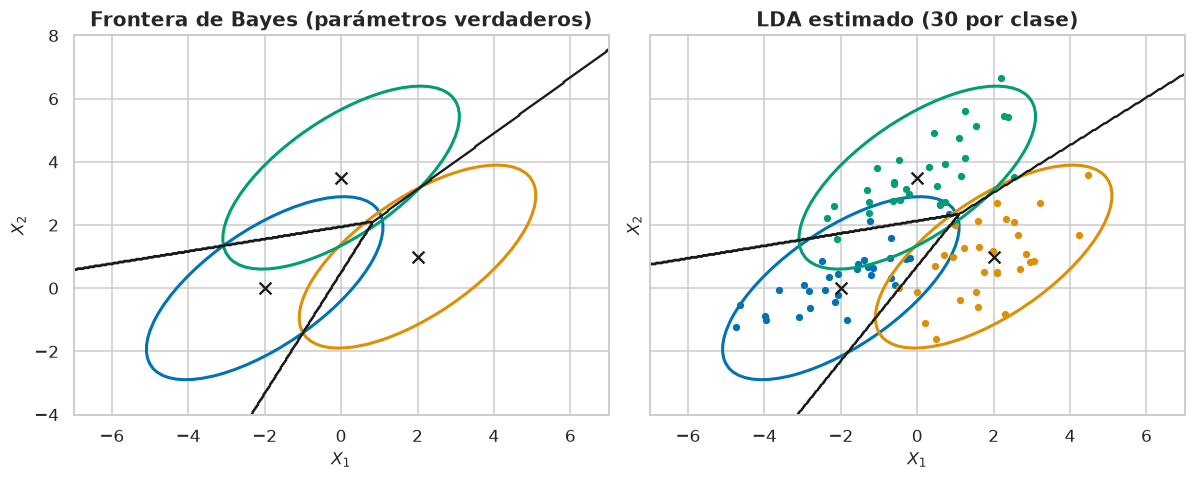

pi_hat: [0.333 0.333 0.333]
mu_hat:
 [[-1.99  0.26]
 [ 1.84  0.91]
 [ 0.16  3.63]]
Sigma_hat:
 [[1.7  0.98]
 [0.98 1.21]]


In [9]:
from matplotlib.patches import Ellipse
from scipy.stats import chi2

rng_lda = np.random.default_rng(0)
K_lda = 3
mu_true_lda = np.array([[-2.0, 0.0], [2.0, 1.0], [0.0, 3.5]])
Sigma_true_lda = np.array([[1.6, 1.0], [1.0, 1.4]])      # común a las 3 clases
pi_true_lda = np.full(K_lda, 1 / K_lda)

def simular_lda(n_por_clase, rng):
    X = np.vstack([rng.multivariate_normal(m, Sigma_true_lda, n_por_clase) for m in mu_true_lda])
    g = np.repeat(np.arange(K_lda), n_por_clase)
    return X, g

def delta_lda(X, pi, mu, Sigma):
    # delta_k(x) = x' S^-1 mu_k - 1/2 mu_k' S^-1 mu_k + log pi_k   (ESL 4.10)
    Sinv = np.linalg.inv(Sigma)
    return X @ Sinv @ mu.T - 0.5 * np.einsum("kp,pq,kq->k", mu, Sinv, mu) + np.log(pi)

def elipse_lda(ax, mu, Sigma, color, nivel=0.95):
    # radio^2 del contorno de 95% = cuantil chi2 con p=2 grados de libertad
    val, vec = np.linalg.eigh(Sigma)
    ang = np.degrees(np.arctan2(vec[1, -1], vec[0, -1]))
    w, h = 2 * np.sqrt(val[::-1] * chi2.ppf(nivel, 2))
    ax.add_patch(Ellipse(mu, w, h, angle=ang, fill=False, color=color, lw=2))

X_lda, g_lda = simular_lda(30, rng_lda)
xx_lda, yy_lda = np.meshgrid(np.linspace(-7, 7, 400), np.linspace(-4, 8, 400))
grid_lda = np.c_[xx_lda.ravel(), yy_lda.ravel()]

# Estimadores a mano (ESL 4.3): pi_k, mu_k y Sigma pooled con divisor N-K
N_lda = len(X_lda)
pi_hat_lda = np.bincount(g_lda) / N_lda
mu_hat_lda = np.array([X_lda[g_lda == k].mean(axis=0) for k in range(K_lda)])
Sigma_hat_lda = sum((X_lda[g_lda == k] - mu_hat_lda[k]).T @ (X_lda[g_lda == k] - mu_hat_lda[k])
                    for k in range(K_lda)) / (N_lda - K_lda)

reg_bayes_lda = delta_lda(grid_lda, pi_true_lda, mu_true_lda, Sigma_true_lda).argmax(1).reshape(xx_lda.shape)
reg_est_lda = delta_lda(grid_lda, pi_hat_lda, mu_hat_lda, Sigma_hat_lda).argmax(1).reshape(xx_lda.shape)

fig, axs = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)
cols_lda = sns.color_palette("colorblind", 3)
for ax, reg, tit in zip(axs, [reg_bayes_lda, reg_est_lda],
                        ["Frontera de Bayes (parámetros verdaderos)", "LDA estimado (30 por clase)"]):
    ax.contour(xx_lda, yy_lda, reg, levels=[0.5, 1.5], colors="k", linewidths=1.5)
    for k in range(K_lda):
        elipse_lda(ax, mu_true_lda[k], Sigma_true_lda, cols_lda[k])
        if ax is axs[1]:
            ax.scatter(*X_lda[g_lda == k].T, s=14, color=cols_lda[k])
    ax.scatter(*mu_true_lda.T, c="k", marker="x", s=60)
    ax.set_title(tit); ax.set_xlabel("$X_1$"); ax.set_ylabel("$X_2$")
plt.tight_layout(); plt.show()
print("pi_hat:", pi_hat_lda.round(3))
print("mu_hat:\n", mu_hat_lda.round(2))
print("Sigma_hat:\n", Sigma_hat_lda.round(2))

Fijate en tres cosas del gráfico. Las elipses (contornos de 95 % de probabilidad) son **idénticas** en forma en las tres clases: esa es la hipótesis de LDA. Las fronteras son rectas que se cortan en un punto. Y no son las mediatrices de los segmentos entre centroides: la covarianza inclinada las deforma, tal como advierte ESL. A la derecha, la frontera estimada con una muestra chica se desvía algo de la de Bayes, pero la sigue.

En la figura del libro, además de las fronteras gruesas (las que separan de verdad las tres regiones), se dibujan con línea cortada las fronteras de **cada par** de clases, prolongadas: son rectas completas, pero sólo un tramo de cada una es frontera efectiva; fuera de ese tramo gana la tercera clase. Es la misma idea de "lineal por tramos" de §4.1.

ESL remata con una observación: la Fig. 4.1 (la de §4.1) es **otro ejemplo** de LDA, pero ahí las clases no son gaussianas. LDA se ajusta igual, porque la fórmula de $\hat\delta_k$ no chequea que los datos sean gaussianos.

Ahora verificamos la fórmula contra la librería.

##### 🏭 Así se hace en la industria

`LinearDiscriminantAnalysis` de sklearn ajusta por dentro el mismo modelo que armamos a mano. El código de abajo chequea que la covarianza, las predicciones y las posteriores coinciden con las nuestras.

> 🔗 **Conexión con la clase 1**: esta figura repite, en dos dimensiones, lo que hicimos en la clase 1 (§5) con `GaussianNB` en una: la frontera de Bayes usa los parámetros verdaderos y es el **techo** (el error de Bayes, el mínimo que ningún método baja con estos atributos); la estimada usa $\hat\mu_k,\hat\Sigma,\hat\pi_k$ sacados de 30 puntos por clase y baila alrededor. Esa distancia entre lo estimado y lo verdadero es exactamente lo que el sombrero de la notación de la clase 1 quiere recordarte.

In [10]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_sk = LinearDiscriminantAnalysis(solver="lsqr").fit(X_lda, g_lda)

# sklearn estima Sigma con divisor N (no N-K): por eso reescalamos para comparar con ESL
print("covariance_ * N/(N-K) == Sigma_hat a mano:",
      np.allclose(lda_sk.covariance_ * N_lda / (N_lda - K_lda), Sigma_hat_lda))

Xtest_lda, gtest_lda = simular_lda(2000, np.random.default_rng(1))
d_mano = delta_lda(Xtest_lda, pi_hat_lda, mu_hat_lda, Sigma_hat_lda)
pred_mano = d_mano.argmax(1)
print("predicciones a mano == sklearn:", np.array_equal(pred_mano, lda_sk.predict(Xtest_lda)))

# Con el mismo Sigma (divisor N) las posteriores coinciden al decimal
Sigma_ml_lda = Sigma_hat_lda * (N_lda - K_lda) / N_lda
d_ml = delta_lda(Xtest_lda, pi_hat_lda, mu_hat_lda, Sigma_ml_lda)
post_mano = np.exp(d_ml - d_ml.max(1, keepdims=True))
post_mano /= post_mano.sum(1, keepdims=True)        # softmax de los delta = posterior
print("posteriores a mano == sklearn:", np.allclose(post_mano, lda_sk.predict_proba(Xtest_lda)))

acc_bayes = (delta_lda(Xtest_lda, pi_true_lda, mu_true_lda, Sigma_true_lda).argmax(1) == gtest_lda).mean()
print(f"accuracy test: LDA estimado {lda_sk.score(Xtest_lda, gtest_lda):.3f} | Bayes {acc_bayes:.3f}")

covariance_ * N/(N-K) == Sigma_hat a mano: True
predicciones a mano == sklearn: True
posteriores a mano == sklearn: True
accuracy test: LDA estimado 0.927 | Bayes 0.930


Dos cosas para llevarse. Primero, la posterior es la **softmax de los $\delta_k$**: $\Pr(G=k\mid x)=e^{\delta_k}/\sum_\ell e^{\delta_\ell}$, porque $\delta_k$ es el log de la posterior salvo una constante común. Segundo, el divisor $N$ vs $N-K$ cambia un poco la escala de $\hat\Sigma$ pero casi nunca las predicciones. Con la muestra de 30 por clase la accuracy queda muy cerca de la de Bayes, que es el techo alcanzable.

Verificamos también la lectura geométrica: maximizar $\delta_k$ equivale a minimizar la distancia de Mahalanobis al cuadrado al centroide menos $2\log\hat\pi_k$.

> 🔗 **Conexión con la clase 3**: que `sklearn` divida por $N$ y ESL por $N-K$ es exactamente el asunto de la clase 3 (§2): el estimador de máxima verosimilitud de una varianza divide por $N$ y queda sesgado hacia abajo, porque ya "gastaste" grados de libertad estimando las medias. Allá eran $p+1$ coeficientes y el factor era $N-p-1$; acá son $K$ medias de clase y el factor es $N-K$. Por eso el corrector cambia la escala de $\hat\Sigma$ pero casi nunca las predicciones.

In [11]:
from scipy.spatial.distance import cdist

# Mahalanobis^2 a cada centroide, corregida por el prior
Sinv_lda = np.linalg.inv(Sigma_hat_lda)
maha2 = cdist(Xtest_lda, mu_hat_lda, metric="mahalanobis", VI=Sinv_lda) ** 2
pred_maha = (maha2 - 2 * np.log(pi_hat_lda)).argmin(1)
print("argmin Mahalanobis^2 - 2 log(pi) == argmax delta:", np.array_equal(pred_maha, pred_mano))

# Sin la corrección de prior y con Sigma=I sería el "centroide más cercano" euclídeo:
pred_euc = cdist(Xtest_lda, mu_hat_lda).argmin(1)
print(f"coinciden con la regla euclídea el {(pred_euc == pred_mano).mean():.1%} de los puntos")

argmin Mahalanobis^2 - 2 log(pi) == argmax delta: True
coinciden con la regla euclídea el 93.2% de los puntos


La regla euclídea coincide en la mayoría de los puntos, pero no en todos: los que discrepan están cerca de las fronteras, donde la forma de $\Sigma$ importa.

#### QDA: fronteras curvas cuando las covarianzas difieren

Ahora dos clases con covarianzas **distintas**. Comparamos la frontera de Bayes (cuadrática), LDA, QDA y LDA sobre las cinco variables de base cuadrática. Medimos el error en un conjunto de test grande.

QDA a mano == sklearn: True
Bayes                        0.1292
LDA                          0.1726
QDA                          0.1288
LDA en espacio cuadrático    0.1442
Name: error de test, dtype: float64


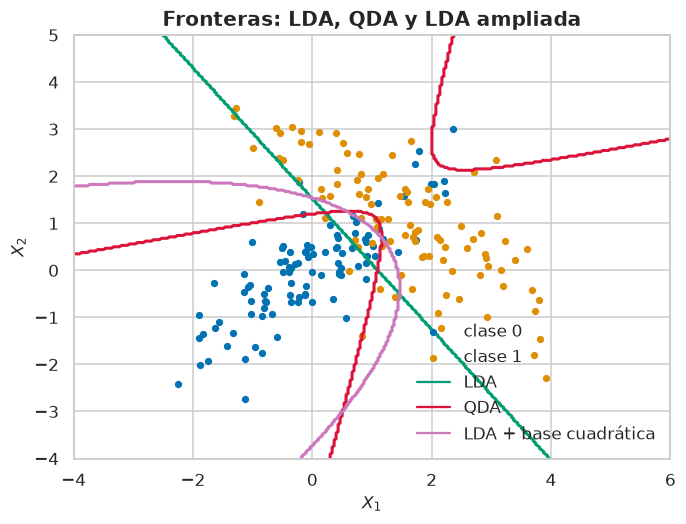

In [12]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.preprocessing import PolynomialFeatures

rng_q = np.random.default_rng(3)
mu_q = np.array([[0.0, 0.0], [1.5, 1.0]])
S_q = [np.array([[1.0, 0.8], [0.8, 1.0]]), np.array([[1.5, -1.0], [-1.0, 1.5]])]

def simular_q(n, rng):
    X = np.vstack([rng.multivariate_normal(mu_q[k], S_q[k], n) for k in range(2)])
    return X, np.repeat([0, 1], n)

Xq, gq = simular_q(100, rng_q)
Xq_te, gq_te = simular_q(5000, np.random.default_rng(4))

# A mano: QDA con Sigma_k propia (divisor N_k - 1, como hace sklearn)
def delta_q(X, pi, mu, Sig):
    out = []
    for k in range(len(pi)):
        d = X - mu[k]
        maha = np.einsum("ij,jk,ik->i", d, np.linalg.inv(Sig[k]), d)
        out.append(-0.5 * np.linalg.slogdet(Sig[k])[1] - 0.5 * maha + np.log(pi[k]))
    return np.array(out).T

pi_q = np.bincount(gq) / len(gq)
mu_hq = np.array([Xq[gq == k].mean(0) for k in range(2)])
S_hq = [np.cov(Xq[gq == k].T) for k in range(2)]          # np.cov divide por N_k - 1
pred_qmano = delta_q(Xq_te, pi_q, mu_hq, S_hq).argmax(1)

qda_sk = QuadraticDiscriminantAnalysis().fit(Xq, gq)
print("QDA a mano == sklearn:", np.array_equal(pred_qmano, qda_sk.predict(Xq_te)))

lda_q = LinearDiscriminantAnalysis().fit(Xq, gq)
poly_q = PolynomialFeatures(2, include_bias=False)        # X1, X2, X1^2, X1X2, X2^2
lda_poly = LinearDiscriminantAnalysis().fit(poly_q.fit_transform(Xq), gq)
err = {
    "Bayes": (delta_q(Xq_te, [.5, .5], mu_q, S_q).argmax(1) != gq_te).mean(),
    "LDA": 1 - lda_q.score(Xq_te, gq_te),
    "QDA": 1 - qda_sk.score(Xq_te, gq_te),
    "LDA en espacio cuadrático": 1 - lda_poly.score(poly_q.transform(Xq_te), gq_te),
}
print(pd.Series(err).round(4).rename("error de test"))

xx_q, yy_q = np.meshgrid(np.linspace(-4, 6, 300), np.linspace(-4, 5, 300))
gr = np.c_[xx_q.ravel(), yy_q.ravel()]
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(*Xq[gq == 0].T, s=14, label="clase 0"); ax.scatter(*Xq[gq == 1].T, s=14, label="clase 1")
for modelo, dat, c, nom in [(lda_q, gr, "C2", "LDA"), (qda_sk, gr, "crimson", "QDA"),
                            (lda_poly, poly_q.transform(gr), "C4", "LDA + base cuadrática")]:
    ax.contour(xx_q, yy_q, modelo.predict(dat).reshape(xx_q.shape), levels=[0.5], colors=c, linewidths=2)
    ax.plot([], [], color=c, label=nom)
ax.set_xlabel("$X_1$"); ax.set_ylabel("$X_2$"); ax.set_title("Fronteras: LDA, QDA y LDA ampliada")
ax.legend(); plt.show()

LDA dibuja una recta que no puede captar que la clase 1 es más dispersa. QDA y LDA ampliada dibujan curvas muy parecidas entre sí, que es lo que muestra la Fig. 4.6 del libro. ESL dice que la diferencia entre ambas suele ser pequeña.

Con los números de la celda: QDA (0.1288) prácticamente empata con Bayes (0.1292); LDA en el espacio cuadrático (0.1442) queda en el medio; LDA común (0.1726) es el peor. La ampliada no es idéntica a QDA porque impone una sola covarianza en las cinco variables, y acá eso cuesta un punto y medio. El libro la llama una alternativa cómoda, no equivalente.

Un detalle de la Fig. 4.6 del libro: las tres clases (las de la Fig. 4.1) son **mezclas de gaussianas** (ESL §6.8), no gaussianas simples, y por eso las fronteras cuadráticas son sólo una aproximación a la frontera verdadera. Las fronteras del libro se dibujan evaluando la regla de decisión en una grilla fina y contorneando (nota al pie 2 de ESL), que es lo que hace nuestro `contour`.

Ahora la cuenta de parámetros de las fronteras, con la fórmula de ESL:

> 🔗 **Conexión con la clase 1**: en la clase 1 (§5, "Confusión típica") quedó anotado que con dos gaussianas de distinta varianza la región de una clase podía ser "el centro" y la de la otra "las dos colas". Eso es QDA en una dimensión: como los términos cuadráticos no se cancelan, la frontera deja de ser un umbral y pasa a ser una ecuación cuadrática. En $p=2$ esos umbrales son las curvas de este gráfico.

In [13]:
def par_lda(K, p): return (K - 1) * (p + 1)
def par_qda(K, p): return (K - 1) * (p * (p + 3) // 2 + 1)

filas = [(K, p, par_lda(K, p), par_qda(K, p)) for K in (3, 11) for p in (2, 10, 100)]
tabla_lda = pd.DataFrame(filas, columns=["K", "p", "LDA (K-1)(p+1)", "QDA (K-1)(p(p+3)/2+1)"])
print(tabla_lda.to_string(index=False))

 K   p  LDA (K-1)(p+1)  QDA (K-1)(p(p+3)/2+1)
 3   2               6                     12
 3  10              22                    132
 3 100             202                  10302
11   2              30                     60
11  10             110                    660
11 100            1010                  51510


Con $K=11$ y $p=10$ (los datos de vocales del libro, Tabla 4.1) son $110$ parámetros contra $660$. Con $p=100$ y $K=11$ QDA necesita más de $51000$ parámetros contra $1010$ de LDA: sin muchísimos datos, QDA sobreajusta. Por eso aparece la regularización de §4.3.1.

Por último, la equivalencia con mínimos cuadrados para **dos clases**. Usamos una muestra desbalanceada ($N_1=40$, $N_2=160$) para mostrar que la dirección coincide y el intercepto no.

> 🔗 **Conexión con la clase 4**: que $\hat\Sigma_k$ sea singular cuando $N_k\le p$ es el mismo problema de la clase 4 cuando $N<p$ y $\mathbf{X}^T\mathbf{X}$ pierde rango: la matriz no se puede invertir y $\delta_k$ no está definida. Los 51000 parámetros de QDA son la versión en clasificación de "más predictores que observaciones". La salida también va a ser la de la clase 4: sumarle algo a la diagonal (lo vas a ver en RDA).

In [14]:
from sklearn.linear_model import LinearRegression

rng_2 = np.random.default_rng(5)
m1, m2 = np.array([0.0, 0.0]), np.array([2.0, 1.0])
X2 = np.vstack([rng_2.multivariate_normal(m1, Sigma_true_lda, 40),
                rng_2.multivariate_normal(m2, Sigma_true_lda, 160)])
g2 = np.r_[np.zeros(40), np.ones(160)].astype(int)
N1, N2 = 40, 160

mu1, mu2 = X2[g2 == 0].mean(0), X2[g2 == 1].mean(0)
S2 = (((X2[g2 == 0] - mu1).T @ (X2[g2 == 0] - mu1)) + ((X2[g2 == 1] - mu2).T @ (X2[g2 == 1] - mu2))) / (N1 + N2 - 2)
w_lda = np.linalg.solve(S2, mu2 - mu1)                    # dirección LDA: S^-1 (mu2 - mu1)

ls = LinearRegression().fit(X2, np.where(g2 == 1, 1.0, -1.0))   # objetivo +1 / -1
cos = ls.coef_ @ w_lda / np.linalg.norm(ls.coef_) / np.linalg.norm(w_lda)
print(f"coseno entre coef. de mínimos cuadrados y dirección LDA: {cos:.6f}")
print(f"cociente coef_LS / w_LDA: {ls.coef_ / w_lda}")   # constante: son proporcionales

# Corte de LDA (ESL 4.11) vs corte de mínimos cuadrados (predicción = 0)
corte_lda = 0.5 * (mu2 + mu1) @ w_lda - np.log(N2 / N1)
corte_ls = -ls.intercept_ / np.linalg.norm(ls.coef_) * np.linalg.norm(w_lda)
print(f"corte LDA: {corte_lda:.3f} | corte LS (en la misma escala de w): {corte_ls:.3f}")
pred_lda2 = (X2 @ w_lda > corte_lda).astype(int)
pred_ls2 = (ls.predict(X2) > 0).astype(int)
print(f"las reglas discrepan en {(pred_lda2 != pred_ls2).sum()} de {len(g2)} puntos")

coseno entre coef. de mínimos cuadrados y dirección LDA: 1.000000
cociente coef_LS / w_LDA: [0.23293903 0.23293903]
corte LDA: 0.017 | corte LS (en la misma escala de w): -0.453
las reglas discrepan en 4 de 200 puntos


El coseno da $1$ y el cociente es constante: la **dirección** es la misma. Los cortes difieren porque $N_1\ne N_2$, y las reglas discrepan en algunos puntos cercanos a la frontera. El término $-\log(N_2/N_1)$ del corte de LDA mueve la frontera a favor de la clase más frecuente.

> 🔗 **Conexión con la clase 1**: el corrimiento del corte por $-\log(N_2/N_1)$ es el ejemplo del test médico de la clase 1 (§5, "Confusión típica") hecho cuenta: si decidís con la verosimilitud ignorás cuánta gente hay de cada clase, y la posterior (que multiplica por el prior) lo corrige. Con clases desbalanceadas, LDA pone la frontera más cerca de la clase rara para compensar. Es el mismo $\pi_k$ que viste ahí.

### ⚠️ Confusión típica

**"LDA asume que los datos son gaussianos, así que no sirve si no lo son."** No es tan así. Con **dos clases**, la dirección discriminante coincide con la de mínimos cuadrados con objetivos $+1/-1$, y esa cuenta no usa la gaussianidad. Sólo el punto de corte (el intercepto) depende de ella, y por eso ESL sugiere ajustarlo para minimizar el error de entrenamiento. Con más de dos clases la equivalencia con la regresión sobre indicadoras se pierde (y justamente por eso LDA evita el *masking*), pero la moraleja se mantiene: en la práctica LDA anda bien en datos claramente no gaussianos porque lo que necesita es una frontera simple y estable, no una densidad correcta.

**Confundir $\Sigma$ pooled con la covarianza total de los datos.** La $\hat\Sigma$ de LDA centra cada punto en la media **de su clase**; la covarianza de todo $X$ junto mezcla la variación *dentro* de las clases con la variación *entre* clases (las medias distintas estiran la nube). Son matrices distintas.

**Creer que la frontera es la mediatriz entre centroides.** Sólo lo es con $\Sigma=\sigma^2 I$ y priors iguales. Si $\Sigma$ no es esférica o los priors difieren, la frontera se inclina o se corre.

**Creer que QDA siempre es mejor por ser más flexible.** Tiene $(K-1)\{p(p+3)/2+1\}$ parámetros: con pocos datos o $p$ grande, su varianza arruina el sesgo que ahorra.

### ❓ La pregunta que quedó abierta

Si las densidades reales no son gaussianas, ¿por qué LDA y QDA funcionan tan bien? ESL lo plantea y responde con una hipótesis, no con una demostración: los datos sólo soportan fronteras lineales o cuadráticas y las estimaciones gaussianas son estables. Es un compromiso sesgo-varianza (ESL desarrolla el compromiso sesgo-varianza más adelante, en el cap. 7). Y queda el puente natural hacia §4.3.1: si LDA tiene sesgo y QDA tiene varianza, ¿existe algo intermedio? Sí: RDA, que encoge las covarianzas de QDA hacia la común.

## 4.3.1–4.3.3 RDA, cómputo de LDA y LDA de rango reducido

📕 ESL §4.3.1–4.3.3

Hasta acá LDA y QDA son los dos extremos de una misma familia: QDA estima una covarianza $\hat\Sigma_k$ por clase y LDA una sola $\hat\Sigma$ común. Esta sección hace tres cosas con eso. Primero, arma el camino intermedio entre ambos (RDA). Segundo, muestra cómo se calcula de verdad un clasificador discriminante. Tercero, explota un hecho que LDA trae de regalo: las clases viven en un subespacio chico, y ahí se puede mirar, clasificar y regularizar.

### 4.3.1 Regularized Discriminant Analysis

#### La idea en criollo

LDA y QDA son dos decisiones opuestas frente a la misma pregunta: ¿cuántas covarianzas estimo?

- QDA estima una por clase. Es flexible, pero cada $\hat\Sigma_k$ tiene unos $p(p+1)/2$ números y se estima con los $N_k$ puntos de *una* clase. Con pocos datos por clase, esa estimación es ruidosa (o directamente singular si $N_k \le p$).
- LDA estima una sola con todos los puntos juntos. Es estable, pero impone que todas las clases tengan la misma forma.

Friedman (1989) propuso no elegir: **mezclar** las dos. Cada covarianza de clase se tira un poco hacia la común. Es el mismo espíritu que ridge en regresión: aceptar algo de sesgo a cambio de bajar varianza.

Una analogía: tenés el promedio de notas de cada comisión (QDA) y el promedio de toda la materia (LDA). Si una comisión tiene 4 alumnos, su promedio propio es poco confiable y conviene corregirlo con el general. Si tiene 400, casi no hace falta.

> **Dónde se rompe la analogía.** Acá no se mezclan números sino **matrices** de $p \times p$. Mezclarlas tiene que dejar una matriz invertible y definida positiva, y eso no es una propiedad de "promediar" en general: acá se cumple porque una combinación convexa de matrices semidefinidas positivas es semidefinida positiva, y además la común $\hat\Sigma$ suele ser invertible aunque las $\hat\Sigma_k$ no lo sean.

#### Formalizándolo

La familia de covarianzas regularizadas de ESL (4.13) es

$$\hat\Sigma_k(\alpha) = \alpha\,\hat\Sigma_k + (1-\alpha)\,\hat\Sigma, \qquad \alpha \in [0,1]$$

donde $\hat\Sigma_k$ es la covarianza muestral de la clase $k$ (la de QDA), $\hat\Sigma$ es la covarianza **agrupada** (pooled) de LDA, y $\alpha$ (leelo "alfa") es un hiperparámetro que dice cuánta fe le tenés a la covarianza propia de cada clase.

Leé los dos extremos:

- $\alpha = 1$: $\hat\Sigma_k(1) = \hat\Sigma_k$. Es QDA puro.
- $\alpha = 0$: $\hat\Sigma_k(0) = \hat\Sigma$ para todo $k$. Es LDA puro.
- $0 < \alpha < 1$: un continuo entre ambos. Es una combinación convexa (pesos no negativos que suman 1), así que conserva la semidefinición positiva de los ingredientes.

Ojo: semidefinida no alcanza para invertir. Si $\hat\Sigma$ es definida positiva (lo habitual cuando $N-K>p$) y $\alpha<1$, la mezcla es definida positiva aunque algún $\hat\Sigma_k$ no lo sea; con $\alpha=1$ (QDA puro) se pierde esa garantía.

ESL dice que $\alpha$ se elige con datos de validación o por validación cruzada. No hay fórmula cerrada.

Hay un segundo dial, $\gamma$ (leelo "gamma"): otro hiperparámetro entre 0 y 1, que dice cuánta fe le tenés a la covarianza común $\hat\Sigma$ frente a una esfera. ESL (4.14) permite encoger la propia $\hat\Sigma$ hacia una covarianza escalar:

$$\hat\Sigma(\gamma) = \gamma\,\hat\Sigma + (1-\gamma)\,\hat\sigma^2 I, \qquad \gamma \in [0,1]$$

Acá $\hat\sigma^2 I$ es la covarianza de "todas las variables independientes y con la misma varianza $\hat\sigma^2$", la más simple posible (una esfera). Con $\gamma = 0$ la covarianza es una esfera y el clasificador queda reducido a distancia euclídea a los centroides. Reemplazando $\hat\Sigma$ por $\hat\Sigma(\gamma)$ en (4.13) queda una familia $\hat\Sigma_k(\alpha,\gamma)$ con dos parámetros: $\alpha$ recorre "una covarianza por clase $\leftrightarrow$ una común" y $\gamma$ recorre "común completa $\leftrightarrow$ esférica".

Un detalle para no confundirse: $\hat\sigma^2$ es un escalar. ESL no dice en esa página cómo se estima; una elección razonable (y la que usa sklearn, como vamos a ver) es el promedio de la diagonal, $\operatorname{tr}(\hat\Sigma)/p$.

ESL también avisa que en el capítulo 12 hay otras versiones regularizadas de LDA (para señales digitalizadas e imágenes, con coeficientes suaves o ralos), y que en el capítulo 18 se trata el caso $\gamma = 0$ en (4.14) para problemas de altísima dimensión como microarrays.

> 🔗 **Conexión con la clase 4**: $\hat\Sigma(\gamma)=\gamma\hat\Sigma+(1-\gamma)\hat\sigma^2 I$ es ridge aplicado a una covarianza: si sacás $\gamma$ de factor común queda $\hat\Sigma+\lambda I$ con $\lambda=\frac{1-\gamma}{\gamma}\hat\sigma^2$, la misma operación de $\mathbf{X}^T\mathbf{X}+\lambda I$. Es un dial entre dos extremos, como $\lambda$: $\alpha=1$ es QDA y $\alpha=0$ es LDA, igual que $\lambda=0$ es OLS. La diferencia es hacia dónde se encoge: ridge tira hacia el cero, RDA tira hacia otra covarianza o hacia una esfera.

#### ¿Por qué nos importa?

Porque RDA es el primer lugar donde aparece, en clasificación, el dial sesgo–varianza que ya conocés de ridge. $\alpha$ no mide "qué tan no lineal" es la frontera: mide cuánto confiás en una covarianza estimada con pocos datos.

En la Fig. 4.7 del libro (datos de vocales, *vowel data*: 11 clases, 10 variables) los errores de entrenamiento **y** de test mejoran cuando $\alpha$ sube desde 0; el de test tiene su óptimo alrededor de $\alpha = 0.9$ (cerca de QDA) y **sube bruscamente** después. O sea que QDA puro, que estaba a un paso, ya es peor que un QDA un poquito encogido. El libro avisa además que la gran diferencia entre error de entrenamiento y de test se debe en parte a que hay muchas mediciones repetidas de pocos individuos, distintos en entrenamiento y test.

### 4.3.2 Computations for LDA

#### La idea en criollo

La fórmula de $\delta_k(x)$ (ESL 4.12) tiene una inversa $\hat\Sigma^{-1}$ y un determinante. Nadie los calcula tal cual. Se diagonaliza la covarianza y todo se vuelve una cuenta de a una coordenada.

La imagen que hay que llevarse: **esferizar** (*sphering*) los datos. Se estira y rota el espacio de modo que la nube de cada clase quede redonda. En un espacio donde todas las clases son esferas del mismo radio, clasificar es lo más intuitivo que hay: ir al centroide más cercano, con una pequeña corrección por cuántos puntos tiene cada clase.

> **Dónde se rompe.** "Nube redonda" vale para la covarianza **común** $\hat\Sigma$. Con QDA cada clase tiene su propia forma y no hay una sola transformación que las vuelva redondas a todas a la vez: ahí hay que diagonalizar cada $\hat\Sigma_k$ por separado.

#### Formalizándolo

Empezamos por el caso general (QDA, y cada clase de RDA). Sea la eigen-descomposición de cada covarianza de clase

$$\hat\Sigma_k = U_k D_k U_k^T,$$

donde $U_k$ es $p\times p$ **ortonormal** (sus columnas son los ejes principales, con $U_k^TU_k = I$) y $D_k$ es diagonal con los autovalores positivos $d_{k\ell}$ (la varianza de la clase $k$ a lo largo de cada eje). ESL lista los dos ingredientes de $\delta_k(x)$ (4.12):

1. El término cuadrático. Como $U_k$ es ortonormal, $U_k^{-1} = U_k^T$, y entonces $\hat\Sigma_k^{-1} = U_k D_k^{-1} U_k^T$. Reemplazando:

$$(x-\hat\mu_k)^T\hat\Sigma_k^{-1}(x-\hat\mu_k) = [U_k^T(x-\hat\mu_k)]^T\, D_k^{-1}\, [U_k^T(x-\hat\mu_k)]$$

Fijate qué pasó: $U_k^T(x-\hat\mu_k)$ es el vector $x-\hat\mu_k$ **expresado en los ejes** de la clase. Y $D_k^{-1}$ diagonal significa que cada coordenada se divide por su varianza. Es una suma de $p$ términos $\text{coord}^2/d_{k\ell}$. No hay inversa de matriz que calcular.

2. El log-determinante. El determinante de una matriz es el producto de sus autovalores, así que

$$\log|\hat\Sigma_k| = \sum_\ell \log d_{k\ell}.$$

**LDA**, que tiene una sola $\hat\Sigma = UDU^T$, se calcula en dos pasos (ESL):

**Paso 1, esferizar.** Definimos

$$X^* \leftarrow D^{-1/2}U^TX.$$

Acá $D^{-1/2}$ es la diagonal con $1/\sqrt{d_\ell}$: primero se rota con $U^T$ (pasar a los ejes principales) y después se divide cada coordenada por su desvío. Chequeamos que la covarianza de $X^*$ es la identidad: la covarianza de $AX$ es $A\hat\Sigma A^T$, y con $A = D^{-1/2}U^T$,

$$D^{-1/2}U^T\,(UDU^T)\,U D^{-1/2} = D^{-1/2}(U^TU)\,D\,(U^TU)D^{-1/2} = D^{-1/2}DD^{-1/2} = I.$$

**Paso 2, centroide más cercano.** En el espacio esferizado, con $\mu_k^* = D^{-1/2}U^T\hat\mu_k$, el término cuadrático de $\delta_k$ es exactamente $\|x^*-\mu_k^*\|^2$: es la distancia euclídea al cuadrado (la misma cuenta del punto 1 con $D$ y $U$ comunes). En LDA el término $-\tfrac12\log|\hat\Sigma|$ es igual para todas las clases, así que no decide nada y se descarta. Queda

$$\hat G(x) = \arg\max_k\Big[-\tfrac12\|x^*-\mu_k^*\|^2 + \log\pi_k\Big] = \arg\min_k\Big[\tfrac12\|x^*-\mu_k^*\|^2 - \log\pi_k\Big].$$

Eso es "al centroide más cercano, **módulo** el efecto de las probabilidades a priori $\pi_k$" (ESL). El $\log\pi_k$ le da una ventaja a las clases más probables: a igual distancia, gana la más grande.

En notación de filas (la que usa numpy, una observación por fila), $X^* = X\,U D^{-1/2}$. Es la misma transformación, transpuesta.

> 🔗 **Conexión con la clase 3**: esta es la misma álgebra que en la clase 3 (§5 y §6), cuando de $\mathbf{X}^T\mathbf{X}=VD^2V^T$ sacábamos $(\mathbf{X}^T\mathbf{X})^{-1}=VD^{-2}V^T$ usando que $V$ es ortogonal. Ojo con la notación, que se cruza: como acá $\hat\Sigma\propto\mathbf{X}_c^T\mathbf{X}_c$ (datos centrados por clase), la $U$ de ESL hace el papel de la $V$ de la clase 3, y los autovalores $d_\ell$ de ESL son los $d_j^2$ de allá divididos por $N-K$. Esferizar con $D^{-1/2}U^T$ es entonces rotar con $V^T$ y dividir cada eje por su valor singular, la $D^{-1}$ de $\hat\beta=VD^{-1}U^T\mathbf{y}$.

#### ¿Por qué nos importa?

Por tres motivos.

- **Numérico**: diagonalizar es más estable y barato que invertir, y reutilizás la descomposición para el log-determinante.
- **Interpretativo**: LDA deja de ser "una fórmula con una inversa" y pasa a ser "distancia euclídea después de una transformación". Todo lo que sigue en 4.3.3 sale de mirar el espacio esferizado.
- **Conexión con regularización**: encoger $\hat\Sigma$ con $\gamma$ es acercar sus autovalores $d_\ell$ hacia $\hat\sigma^2$ (su promedio, si $\hat\sigma^2=\operatorname{tr}(\hat\Sigma)/p$). Los autovalores chicos son los que en $D^{-1/2}$ se amplifican muchísimo, y esos son los que más ruido meten cuando $N$ es chico.

> 🔗 **Conexión con las clases 2, 3 y 4**: es el problema de la multicolinealidad de la clase 3 (§3) con otra matriz. Allá, un $d_j$ chico hacía que $1/d_j$ explotara y que $\hat\beta$ se volviera inestable (en la clase 4, $\mathrm{Var}(\hat\beta)=\sigma^2VD^{-2}V^T$ explotaba igual); acá, un autovalor chico de $\hat\Sigma$ hace que $D^{-1/2}$ amplifique esa dirección y meta ruido. Y cuando hay menos datos que variables ($N_k\le p$, o $N<p$ como en el experimento de §4.3.3) la matriz es directamente singular, el mismo rango deficiente que en la autoevaluación 6 de la clase 2 ($N=50$, $p=80$) hacía imposible invertir $\mathbf{X}^T\mathbf{X}$. Encoger los autovalores con $\gamma$ es el gesto de ridge ($d_j^2\to d_j^2+\lambda$) puesto sobre $\hat\Sigma$. Ojo con la escala: los $d_\ell$ de ESL son autovalores de $\hat\Sigma$, mientras que en la clase 4 los autovalores de $\mathbf{X}^T\mathbf{X}$ son $d_j^2$.

In [15]:
from sklearn.datasets import load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Wine: K=3 clases, p=13 variables. No se estandariza: LDA sin encoger no depende de la escala.
X_rda, y_rda = load_wine(return_X_y=True)
N_rda, p_rda = X_rda.shape
K_rda = len(np.unique(y_rda))
clases_rda = np.unique(y_rda)

pi_rda = np.array([np.mean(y_rda == k) for k in clases_rda])
mu_rda = np.array([X_rda[y_rda == k].mean(axis=0) for k in clases_rda])

# Covarianza agrupada W: los residuos respecto de la media de SU clase, sobre N-K
Xc_rda = X_rda - mu_rda[y_rda]
W_rda = Xc_rda.T @ Xc_rda / (N_rda - K_rda)

# Paso 1: eigen-descomposicion W = U D U^T y esferizado (version por filas)
d_rda, U_rda = np.linalg.eigh(W_rda)          # eigh: W es simetrica
Esf_rda = U_rda / np.sqrt(d_rda)              # U D^{-1/2}
Xs_rda = X_rda @ Esf_rda
mus_rda = mu_rda @ Esf_rda
print("covarianza intra-clase esferizada = I:", np.allclose(Esf_rda.T @ W_rda @ Esf_rda, np.eye(p_rda)))

# Paso 2: centroide mas cercano corregido por log(pi_k)
dist2_rda = ((Xs_rda[:, None, :] - mus_rda[None, :, :]) ** 2).sum(axis=2)
pred_rda = np.argmin(0.5 * dist2_rda - np.log(pi_rda), axis=1)
print("accuracy a mano:", (pred_rda == y_rda).mean())

covarianza intra-clase esferizada = I: True
accuracy a mano: 1.0


La primera línea impresa chequea lo que demostramos: $(UD^{-1/2})^T\,W\,(UD^{-1/2}) = I$, o sea la covarianza intra-clase esferizada es la identidad. Y la clasificación es una distancia euclídea más la corrección por $\pi_k$, sin invertir ninguna matriz.

In [16]:
# Asi se hace en la industria: sklearn hace lo mismo por dentro.
lda_eig_rda = LinearDiscriminantAnalysis(solver="eigen").fit(X_rda, y_rda)
lda_svd_rda = LinearDiscriminantAnalysis(solver="svd").fit(X_rda, y_rda)

print("eigen == a mano:", np.array_equal(lda_eig_rda.predict(X_rda), pred_rda))
print("svd   == a mano:", np.array_equal(lda_svd_rda.predict(X_rda), pred_rda))
print("accuracy sklearn:", lda_eig_rda.score(X_rda, y_rda))

eigen == a mano: True
svd   == a mano: True
accuracy sklearn: 1.0


##### 🏭 Así se hace en la industria

La celda de arriba es la versión de `sklearn`: `solver="eigen"` hace la eigen-descomposición que hicimos a mano y `solver="svd"` (el default) evita armar la covarianza y trabaja directo sobre los datos centrados, que es numéricamente mejor cuando $p$ es grande. Las tres predicciones coinciden, como tenía que ser.

#### ⚠️ Confusión típica

Creer que "esferizar" es lo mismo que estandarizar las variables (restar media y dividir por desvío). Estandarizar divide cada variable por su desvío pero **deja las correlaciones**; esferizar además las elimina, porque rota a los ejes principales de $\hat\Sigma$ antes de escalar. Por eso LDA no se vuelve "distancia a centroides en las variables estandarizadas": la distancia correcta es la de Mahalanobis, que es la euclídea *después* de esferizar.

> 🔗 **Conexión con las clases 3 y 4**: acá tenés los dos caminos de la clase 3 (§5) y de la clase 4 (§1) en versión LDA. A mano hicimos `eigh` sobre la covarianza $W$, que es "formar $\mathbf{X}^T\mathbf{X}$ y diagonalizar" ($\mathbf{X}^T\mathbf{X}=VD^2V^T$); el `solver="svd"` de `sklearn` trabaja directo sobre los datos centrados, descomponiendo $\mathbf{X}=UDV^T$. Los valores singulares de los datos centrados son, salvo el divisor, la raíz de los autovalores de $\hat\Sigma$, así que son dos caminos al mismo resultado. Y es la misma razón por la que `lstsq` le gana a `inv(X.T @ X)` en la clase 2: armar el producto eleva al cuadrado el número de condición, y eso duele justo cuando $p$ es grande o hay direcciones casi colapsadas.

### 4.3.3 Reduced-Rank Linear Discriminant Analysis

#### La idea en criollo

Hay una restricción extra de LDA que lo hace popular: permite **ver** los datos.

Los $K$ centroides viven en un espacio de $p$ dimensiones, pero $K$ puntos siempre caben en un subespacio afín de dimensión a lo sumo $K-1$ (dos puntos definen una recta, tres un plano...). Si $p = 13$ y $K = 3$, los centroides están en un plano. Y para saber a qué centroide estás más cerca, lo que pasa **fuera** de ese plano no ayuda a distinguir: es una distancia que le suma lo mismo a todas las clases. Entonces se proyecta y se clasifica en el plano sin perder nada de información relevante.

Una analogía: estás en una sala grande y tenés que decidir cuál de tres personas te queda más cerca. Da igual qué tan alto o bajo estés respecto del piso: la altura suma lo mismo a las tres distancias al cuadrado. Lo único que decide es la posición sobre el piso.

> **Dónde se rompe.** La analogía supone que las distancias se miden con una regla común y que la "altura" es una dirección perpendicular al piso donde están las tres personas. Eso vale en el espacio esferizado, donde la distancia que importa es la euclídea; en el espacio original la distancia correcta es la de Mahalanobis y "perpendicular" no quiere decir lo mismo. Y cuando $K-1 \ge p$, como en los datos de vocales ($K-1 = p = 10$), no hay "altura" que tirar: los centroides ocupan todo el espacio y no hay dimensión sobrante.

#### Formalizándolo

**Por qué podemos ignorar lo ortogonal.** Trabajamos en el espacio esferizado. Sea $H_{K-1}$ el subespacio afín que contiene a los centroides $\mu_1^*,\dots,\mu_K^*$ y sea $P$ la proyección ortogonal sobre la dirección de ese subespacio (centrada en el centroide global $\bar\mu^*$). Descomponemos cualquier vector en una parte dentro y una fuera:

$$x^*-\mu_k^* = P(x^*-\mu_k^*) + (I-P)(x^*-\mu_k^*).$$

Las dos partes son ortogonales, así que por Pitágoras

$$\|x^*-\mu_k^*\|^2 = \|P(x^*-\mu_k^*)\|^2 + \|(I-P)(x^*-\mu_k^*)\|^2.$$

Ahora, $\mu_k^*-\bar\mu^*$ está dentro del subespacio para todo $k$, así que $(I-P)(\mu_k^*-\bar\mu^*) = 0$. Escribiendo $x^*-\mu_k^* = (x^*-\bar\mu^*) - (\mu_k^*-\bar\mu^*)$ queda

$$(I-P)(x^*-\mu_k^*) = (I-P)(x^*-\bar\mu^*),$$

que **no depende de $k$**. El segundo sumando de Pitágoras es el mismo número para todas las clases y no cambia cuál es el mínimo. Por eso ESL concluye que hay una reducción de dimensión fundamental: alcanza con mirar el subespacio de dimensión a lo sumo $K-1$. Con $K=3$ eso es un plano: se puede graficar con un color por clase sin resignar nada de lo que LDA usa para clasificar.

**¿Y si $K>3$?** Podemos pedir un subespacio de dimensión $L < K-1$, $H_L \subseteq H_{K-1}$, "óptimo para LDA". Fisher definió **óptimo** como: que los centroides proyectados queden lo más esparcidos posible en términos de varianza. Según ESL, eso equivale a hacer componentes principales de los centroides (ya esferizados; componentes principales: ESL §3.5.1 en breve y §14.5.1 en detalle). Las direcciones salen ordenadas, así que se pueden calcular de a una. Se llaman **variables canónicas** o **discriminantes**.

**El algoritmo** (ESL §4.3.3):

1. Calcular la matriz $M$ de $K\times p$ con los centroides de clase y la covarianza común $W$ (*within-class*).
2. Esferizar los centroides: $M^* = MW^{-1/2}$, usando la eigen-descomposición de $W$ (es la $D^{-1/2}U^T$ de antes, en versión simétrica $W^{-1/2} = UD^{-1/2}U^T$).
3. Calcular $B^*$, la covarianza de $M^*$ ($B$ es la covarianza *between-class*), y su eigen-descomposición $B^* = V^*D_BV^{*T}$. Las columnas $v_\ell^*$ de $V^*$, de la primera a la última, dan las coordenadas de los subespacios óptimos.
4. La $\ell$-ésima variable discriminante es

$$Z_\ell = v_\ell^TX, \qquad v_\ell = W^{-1/2}v_\ell^*.$$

Un detalle: $B^*$ tiene rango a lo sumo $K-1$, porque viene de $K$ puntos centrados. Por eso sólo hay hasta $K-1$ discriminantes con autovalor distinto de cero. En el código de abajo ponderamos los centroides por la proporción de cada clase al calcular $B$ (ESL sólo dice "la covarianza de $M$"; con clases balanceadas da lo mismo salvo una constante).

**La derivación de Fisher, sin gaussianas.** Fisher llegó a lo mismo por otro camino, sin mencionar distribuciones. Planteó: *encontrar la combinación lineal $Z = a^TX$ tal que la varianza entre clases esté maximizada relativa a la varianza intra-clase.*

Para la proyección $Z = a^TX$:

- la varianza **entre** clases (la varianza de las medias de clase de $Z$) es $a^TBa$;
- la varianza **intra** clase (la varianza agrupada alrededor de esas medias) es $a^TWa$.

Además $B + W = T$, con $T$ la covarianza total de $X$ ignorando las clases (la igualdad es exacta con divisor $N$ en $W$ y $B$ ponderada por $\pi_k$; con el $N-K$ de $\hat\Sigma$ es aproximada. Da igual para las direcciones: reescalar $B$ o $W$ cambia los autovalores pero no los autovectores). El problema (ESL 4.15) es maximizar el **cociente de Rayleigh**

$$\max_a \frac{a^TBa}{a^TWa},$$

o, de forma equivalente (ESL 4.16), $\max_a a^TBa$ sujeto a $a^TWa=1$. (Son equivalentes porque el cociente no cambia si reescalás $a$, así que podés fijar el denominador en 1.)

Mostremos que esto es el mismo procedimiento del algoritmo. Hacemos el cambio de variable $b = W^{1/2}a$, o sea $a = W^{-1/2}b$. Entonces $a^TWa = b^Tb$ y $a^TBa = b^T(W^{-1/2}BW^{-1/2})b = b^TB^*b$, donde $B^* = W^{-1/2}BW^{-1/2}$ es justo la covarianza de $M^* = MW^{-1/2}$. El problema queda

$$\max_b \frac{b^TB^*b}{b^Tb}.$$

Es el cociente de Rayleigh de una matriz simétrica $B^*$: se maximiza en el autovector de mayor autovalor, $v_1^*$, y el máximo vale ese autovalor. Volviendo a $a$, $a_1 = W^{-1/2}v_1^*$, que es el $v_1$ del algoritmo. Las siguientes direcciones siguen igual: ortogonales entre sí en $b$, lo que en $a$ es ortogonalidad **respecto de $W$** ($a_i^TWa_j=0$), como dice ESL.

Por último, cómo se conecta con el problema de autovalores generalizado de ESL ("$a$ es el autovector de mayor autovalor de $W^{-1}B$"). Si $B^*v^* = \lambda v^*$ (con $\lambda$, leelo "lambda", el autovalor asociado al autovector $v^*$) y $a = W^{-1/2}v^*$:

$$W^{-1}B\,a = W^{-1}BW^{-1/2}v^* = W^{-1/2}\big(W^{-1/2}BW^{-1/2}\big)v^* = W^{-1/2}B^*v^* = \lambda\,W^{-1/2}v^* = \lambda\,a.$$

Es decir: $W^{-1}B$ **no es simétrica**, pero tiene los mismos autovalores que la simétrica $B^*$ y sus autovectores son $a=W^{-1/2}v^*$. Por eso se resuelve por la vía simétrica. ESL deja como ejercicio (Ex. 4.1) probar esa identidad de $a_1$ con $v_1$. Las $a_\ell$ se llaman **coordenadas discriminantes** (no confundir con las *funciones* discriminantes $\delta_k$) y también **variates canónicos**, porque hay una derivación alternativa por análisis de correlación canónica de la matriz indicadora de respuesta (ESL §12.5).

**Por qué Fisher mira la covarianza y no sólo los centroides.** La Fig. 4.9 del libro compara dos direcciones para datos gaussianos. La dirección que une los centroides maximiza la separación de las medias (la varianza entre clases), pero las nubes son alargadas y las clases proyectadas se **solapan**. Una dirección que tiene en cuenta la covarianza logra menos separación de medias pero mucho menos solapamiento, que es lo que reduce el error. Dicho de otro modo: maximizar sólo $a^TBa$ sin el denominador $a^TWa$ te da la dirección equivocada.

**Y el $\log\pi_k$ en el subespacio.** Clasificar en el subespacio de dimensión $L$ es la misma regla de antes restringida a esas coordenadas. ESL muestra que es una regla gaussiana con la restricción adicional de que los centroides de las gaussianas caen en un subespacio de dimensión $L$ de $\mathbb{R}^p$, y que ajustar ese modelo por máxima verosimilitud y armar las posteriores con Bayes da exactamente esta regla (Ex. 4.8). La corrección $\log\pi_k$ sigue ahí. La razón, vista en la Fig. 4.9: el error de clasificación depende del área de solapamiento de las densidades. Con $\pi_k$ iguales, el corte óptimo queda justo en el medio de las medias proyectadas; con $\pi_k$ distintos, conviene correrlo hacia la clase más chica.

#### ¿Por qué nos importa?

Porque reducir el rango **también regulariza**. Es lo que muestra el libro con los datos de vocales: hay 11 clases y 10 variables, o sea 10 dimensiones posibles para el clasificador. La Fig. 4.10 muestra el error de entrenamiento y test de LDA en cada uno de esos subespacios jerárquicos, y la mejor tasa de error de test se da en dimensión **2**, no en 10. Con 2 discriminantes se estiman muchísimos menos parámetros (la frontera vive en un plano), así que baja la varianza a costa de un poco de sesgo. La Fig. 4.11 muestra las fronteras de decisión del clasificador de dos dimensiones, y la Fig. 4.4 el subespacio óptimo de dimensión 2 de esas 11 clases; la Fig. 4.8 agrega cuatro pares más de coordenadas discriminantes.

En criollo: el número de discriminantes que te quedás, $L$, es otro hiperparámetro de complejidad, igual que $\alpha$ y $\gamma$, y se elige igual (validación o cross-validation). Resumen de ESL de todo este camino: (i) clasificación gaussiana con covarianza común da fronteras lineales y se hace esferizando y yendo al centroide más cercano (módulo $\log\pi_k$); (ii) como sólo cuentan distancias relativas, se puede confinar todo al subespacio de los centroides; (iii) ese subespacio se descompone en subespacios sucesivamente óptimos, y esa descomposición es idéntica a la de Fisher.

**Qué mirar en las Figs. 4.8 y 4.11.** La Fig. 4.8 muestra las vocales en cuatro proyecciones sobre pares de variables canónicas. Lo que hay que ver: a medida que sube el orden de la variable canónica, los centroides quedan cada vez **menos esparcidos**; en el panel de abajo a la derecha casi se superponen, y ahí están las clases que más se confunden. Es la versión dibujada de que los autovalores de $B^*$ bajan: las últimas direcciones separan poco. La Fig. 4.11 muestra las fronteras del clasificador en el plano de las dos primeras variables canónicas, y ESL avisa algo que conviene no perder: en un subespacio de dimensión mayor las fronteras son **planos afines** de esa dimensión, y ya no se podrían dibujar como rectas.

**Tres hechos con los que ESL cierra §4.3.3 (p. 118), que enuncia sin demostrar.** (i) LDA de rango reducido equivale a hacer la regresión sobre la matriz indicadora y después una eigen-descomposición de $\hat{\mathbf{Y}}^T\mathbf{Y}$. (ii) Con dos clases hay un único discriminante, idéntico, salvo un múltiplo escalar, a cualquiera de las dos columnas de $\hat{\mathbf{Y}}$ (es la misma idea que verificamos en §4.3 con la codificación $\pm1$). (iii) Si transformás los predictores $X$ en $\hat{\mathbf{Y}}$ y hacés LDA sobre $\hat{\mathbf{Y}}$, da exactamente lo mismo que LDA en el espacio original (Ejercicio 4.3). Todo esto se desarrolla en el capítulo 12 (§12.5); acá queda como puente.

> 🔗 **Conexión con las clases 3, 4 y 5**: acá reaparece la distinción "truncar o encoger" de la §8 de la clase 4. Quedarte con $L$ discriminantes y tirar el resto es un escalón (factor 1 o 0), como la regresión por componentes principales. Ridge, en cambio, baja el volumen de cada dirección de forma continua con $d_j^2/(d_j^2+\lambda)$ (y la clase 5 lo resume así: PCR tira, ridge no tira nada). Las direcciones no son las mismas (acá se ordenan por separación entre clases, allá por varianza de $\mathbf{X}$), pero la lógica sí: $L$ es un hiperparámetro de complejidad como $\lambda$, y cortar de más o de menos se elige por validación. Hay además un parecido más flojo, y lo marco como analogía: como en la SVD truncada de la clase 3 (§4), tirás las direcciones que menos aportan y conservás las primeras. Dos diferencias: acá lo que se descompone no es $\mathbf{X}$ sino los centroides **ya esferizados** (por eso $\mathbf{B}^*$ tiene rango a lo sumo $K-1$), y el criterio no es varianza total sino separación entre clases relativa a la intra-clase. Por eso no es "PCA sobre $\mathbf{X}$".

In [17]:
# Discriminantes canonicos a mano: algoritmo de ESL 4.3.3 (W, pi_k, mu_rda ya calculados arriba)
# Paso 2: W^{-1/2} simetrica = U D^{-1/2} U^T
Wmh_rda = U_rda @ np.diag(d_rda ** -0.5) @ U_rda.T
Ms_rda = mu_rda @ Wmh_rda                        # M* = M W^{-1/2}  (K x p)

# Paso 3: B* = covarianza (ponderada por pi_k) de M*, y su eigen-descomposicion
mbar_rda = pi_rda @ Ms_rda
Bs_rda = (Ms_rda - mbar_rda).T @ np.diag(pi_rda) @ (Ms_rda - mbar_rda)
lam_rda, Vs_rda = np.linalg.eigh(Bs_rda)
orden_rda = np.argsort(lam_rda)[::-1]
lam_rda, Vs_rda = lam_rda[orden_rda], Vs_rda[:, orden_rda]

# Paso 4: v_l = W^{-1/2} v*_l ; solo K-1 autovalores son distintos de cero (rango de B*)
V_rda = Wmh_rda @ Vs_rda[:, :K_rda - 1]
Z_rda = (X_rda - mu_rda.T @ pi_rda) @ V_rda      # discriminantes (centrados)
print("autovalores de B*:", np.round(lam_rda[:4], 4), "(el resto ~ 0)")

# Chequeo: es el mismo problema que W^{-1} B a = lambda a
B_rda = (mu_rda - mu_rda.T @ pi_rda).T @ np.diag(pi_rda) @ (mu_rda - mu_rda.T @ pi_rda)   # B en el espacio original
lam2_rda = np.sort(np.linalg.eigvals(np.linalg.inv(W_rda) @ B_rda).real)[::-1]
print("autovalores de W^-1 B:", np.round(lam2_rda[:4], 4))
print("v^T W v = I:", np.allclose(V_rda.T @ W_rda @ V_rda, np.eye(K_rda - 1)))

autovalores de B*: [8.9287 4.0589 0.     0.    ] (el resto ~ 0)
autovalores de W^-1 B: [8.9287 4.0589 0.     0.    ]
v^T W v = I: True


discriminante 1: |corr| mano vs sklearn = 1.000000
discriminante 2: |corr| mano vs sklearn = 1.000000


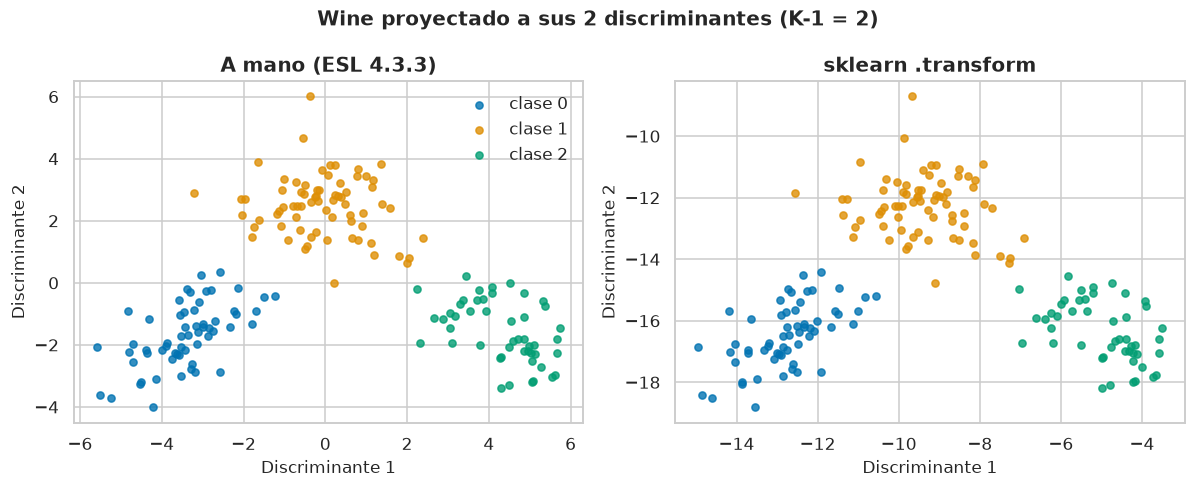

In [18]:
# Asi se hace en la industria: LDA(...).transform da los discriminantes
lda_tr_rda = LinearDiscriminantAnalysis(solver="eigen", n_components=2).fit(X_rda, y_rda)
Zsk_rda = lda_tr_rda.transform(X_rda)

# Coinciden salvo signo y escala por columna: comparamos con la correlacion absoluta
for l in range(2):
    c = abs(np.corrcoef(Z_rda[:, l], Zsk_rda[:, l])[0, 1])
    print(f"discriminante {l + 1}: |corr| mano vs sklearn = {c:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, Zp, titulo in zip(axes, [Z_rda, Zsk_rda], ["A mano (ESL 4.3.3)", "sklearn .transform"]):
    for k in clases_rda:
        ax.scatter(Zp[y_rda == k, 0], Zp[y_rda == k, 1], s=22, alpha=0.8, label=f"clase {k}")
    ax.set_title(titulo)
    ax.set_xlabel("Discriminante 1")
    ax.set_ylabel("Discriminante 2")
axes[0].legend()
fig.suptitle("Wine proyectado a sus 2 discriminantes (K-1 = 2)", fontweight="bold")
plt.tight_layout()
plt.show()

##### 🏭 Así se hace en la industria

La segunda celda de código es la versión de librería. Las dos figuras tienen que ser la misma nube salvo un posible espejo o un cambio de escala de los ejes, porque cada discriminante está definido salvo signo (un autovector sirve con $+$ o $-$) y `sklearn` normaliza los ejes de otra manera. Por eso comparamos con correlación absoluta y no con `allclose` directo.

Qué mirar en el gráfico: tres grupos bien separados en un plano que salió de un espacio de 13 variables. Esa es la versión chica de lo que muestra la Fig. 4.4 de las vocales. En wine $K-1 = 2$, así que **no perdimos nada** de lo que LDA necesita para clasificar (la demostración de arriba), a diferencia de las vocales, donde $K-1 = p$ y el plano de 2 dimensiones sí es una reducción con pérdida, pero que encima resulta ser la mejor para generalizar.

#### En código: rango reducido y regularización con datos simulados

Wine tiene $K-1=2$ y no deja ver el fenómeno de la Fig. 4.10: para eso hace falta $K-1$ grande con los centroides *realmente* en pocas dimensiones y pocos datos. Lo simulamos: $K=5$ clases en $p=10$ variables, con los centroides en un plano (2 dimensiones) más ruido con covarianza común, y sólo 15 puntos de entrenamiento por clase. Después comparamos el error de test usando $L=1,2,3,4$ discriminantes (con $L=4=K-1$ es LDA completo).

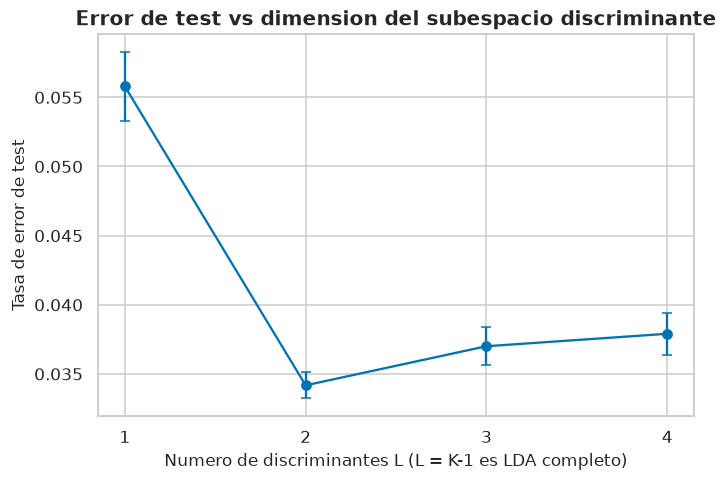

error medio por L: [0.056 0.034 0.037 0.038]


In [19]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

K_s, p_s, n_por_clase, n_test, reps = 5, 10, 15, 1000, 30
rng_rda = np.random.default_rng(0)
Q_rda = np.linalg.qr(rng_rda.normal(size=(p_s, 2)))[0].T       # base ortonormal de un plano
M_true_rda = 2.5 * rng_rda.normal(size=(K_s, 2)) @ Q_rda       # centroides en ese plano
L_cov_rda = np.eye(p_s) + 0.4 * rng_rda.normal(size=(p_s, p_s))  # covarianza comun = L L^T

def muestra_rda(n):
    y = np.repeat(np.arange(K_s), n)
    return M_true_rda[y] + rng_rda.normal(size=(len(y), p_s)) @ L_cov_rda.T, y

err_rda = np.zeros((reps, K_s - 1))
for r in range(reps):
    Xtr, ytr = muestra_rda(n_por_clase)
    Xte, yte = muestra_rda(n_test)
    full = LDA(solver="svd").fit(Xtr, ytr)
    Ztr, Zte = full.transform(Xtr), full.transform(Xte)
    for L in range(1, K_s):
        # Gaussiana en el subespacio de L discriminantes (aprende pi_k y centroides ahi)
        clf = LDA(solver="svd").fit(Ztr[:, :L], ytr)
        err_rda[r, L - 1] = 1 - clf.score(Zte[:, :L], yte)

fig, ax = plt.subplots()
ax.errorbar(range(1, K_s), err_rda.mean(0), yerr=err_rda.std(0) / np.sqrt(reps), marker="o", capsize=3)
ax.set_xticks(range(1, K_s))
ax.set_title("Error de test vs dimension del subespacio discriminante")
ax.set_xlabel("Numero de discriminantes L (L = K-1 es LDA completo)")
ax.set_ylabel("Tasa de error de test")
plt.show()
print("error medio por L:", np.round(err_rda.mean(0), 3))

El error baja hasta $L=2$ (la dimensión verdadera del plano de centroides) y de ahí ya no mejora: los discriminantes 3 y 4 sólo capturan ruido. Con pocos datos ese ruido se estima mal y hasta puede empeorar el test. Es el mismo mensaje de la Fig. 4.10 del libro: menos dimensiones, menos varianza. (La magnitud de la mejora depende de los datos simulados; no esperes el mismo tamaño de efecto que en la Fig. 4.10 del libro.)

Ahora el otro lado: el efecto de $\alpha$ y de la regularización hacia la esfera con $n$ chico y $p$ grande. Primero un RDA de ESL (4.13) hecho a mano, que `sklearn` no trae, usando la eigen-descomposición de 4.3.2 para el término cuadrático y el log-determinante.

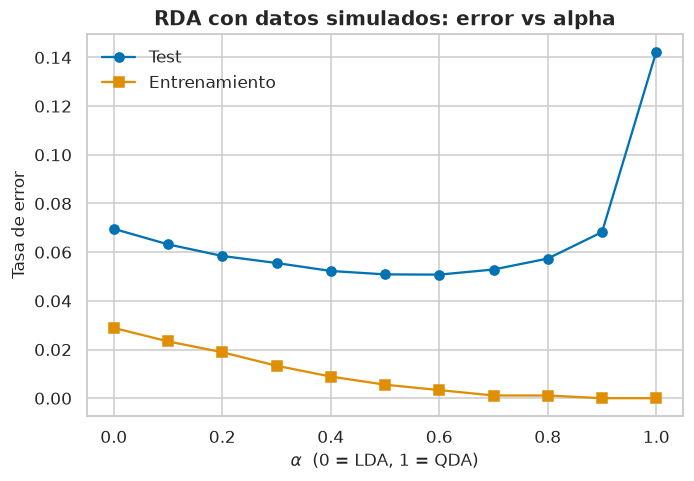

alpha con menor error de test: 0.6000000000000001
error de entrenamiento medio por alpha: [0.029 0.023 0.019 0.013 0.009 0.006 0.003 0.001 0.001 0.    0.   ]
error de test medio por alpha:          [0.07  0.063 0.058 0.056 0.052 0.051 0.051 0.053 0.057 0.068 0.142]


In [20]:
def rda_predecir_rda(Xtr, ytr, Xte, alpha, eps=1e-8):
    # Sigma_k(alpha) = alpha*Sigma_k + (1-alpha)*Sigma pooled (ESL 4.13); delta_k via eigh (4.3.2)
    ks = np.unique(ytr)
    mus = np.array([Xtr[ytr == k].mean(0) for k in ks])
    Rs = Xtr - mus[np.searchsorted(ks, ytr)]
    S_pool = Rs.T @ Rs / (len(ytr) - len(ks))
    deltas = []
    for i, k in enumerate(ks):
        Xk = Xtr[ytr == k] - mus[i]
        Sk = alpha * (Xk.T @ Xk / (len(Xk) - 1)) + (1 - alpha) * S_pool
        d, U = np.linalg.eigh(Sk)
        d = np.maximum(d, eps)                       # evita autovalores ~0 en QDA puro
        proy = (Xte - mus[i]) @ U                    # U^T (x - mu_k)
        deltas.append(-0.5 * np.sum(np.log(d)) - 0.5 * np.sum(proy ** 2 / d, axis=1)
                      + np.log(np.mean(ytr == k)))
    return ks[np.argmax(deltas, axis=0)]

# 3 clases, p=10, covarianzas DISTINTAS por clase, pocos datos de entrenamiento
rng2_rda = np.random.default_rng(1)
p2, K2 = 10, 3
mu2 = 1.2 * rng2_rda.normal(size=(K2, p2))
Ls2 = [np.eye(p2) + 0.2 * rng2_rda.normal(size=(p2, p2)) for _ in range(K2)]
def muestra2_rda(n):
    y = np.repeat(np.arange(K2), n)
    X = np.array([mu2[k] + Ls2[k] @ rng2_rda.normal(size=p2) for k in y])
    return X, y

alphas = np.linspace(0, 1, 11)
e_tr = np.zeros((20, len(alphas))); e_te = np.zeros_like(e_tr)
for r in range(20):
    Xtr, ytr = muestra2_rda(15); Xte, yte = muestra2_rda(500)
    for j, a in enumerate(alphas):
        e_tr[r, j] = np.mean(rda_predecir_rda(Xtr, ytr, Xtr, a) != ytr)
        e_te[r, j] = np.mean(rda_predecir_rda(Xtr, ytr, Xte, a) != yte)

fig, ax = plt.subplots()
ax.plot(alphas, e_te.mean(0), marker="o", label="Test")
ax.plot(alphas, e_tr.mean(0), marker="s", label="Entrenamiento")
ax.set_title("RDA con datos simulados: error vs alpha")
ax.set_xlabel(r"$\alpha$  (0 = LDA, 1 = QDA)")
ax.set_ylabel("Tasa de error")
ax.legend()
plt.show()
print("alpha con menor error de test:", alphas[e_te.mean(0).argmin()])
print("error de entrenamiento medio por alpha:", np.round(e_tr.mean(0), 3))
print("error de test medio por alpha:         ", np.round(e_te.mean(0), 3))

Lo que tenés que mirar: el error de entrenamiento baja casi monótonamente con $\alpha$ (más flexibilidad, más ajuste), pero el de test no. Es la forma de la Fig. 4.7: el óptimo de test suele estar en el medio y no en los extremos. El lugar exacto del mínimo depende de la semilla y del tamaño de muestra, no saques conclusiones del valor puntual.

Ahora el dial $\gamma$ de (4.14), hacia la covarianza esférica. `sklearn` lo implementa con el parámetro `shrinkage`. Ojo con la convención: su $s$ es el peso de la esfera, o sea $s = 1-\gamma$ (con $\hat\sigma^2 = \operatorname{tr}(\hat\Sigma)/p$, el promedio de la diagonal).

> 🔗 **Conexión con la clase 4**: lo que dijo la clase 4 (§3) sobre $\lambda$ vale idéntico para $\alpha$: el que mejor ajusta el entrenamiento es siempre el extremo más flexible ($\lambda=0$ allá, $\alpha=1$ acá), así que no se puede elegir mirando el error de entrenamiento. La curva de test en U de la Fig. 4.7 es la versión en clasificación de eso, y se resuelve igual: validación cruzada, con la partición tomada de adentro del entrenamiento (nunca del test).

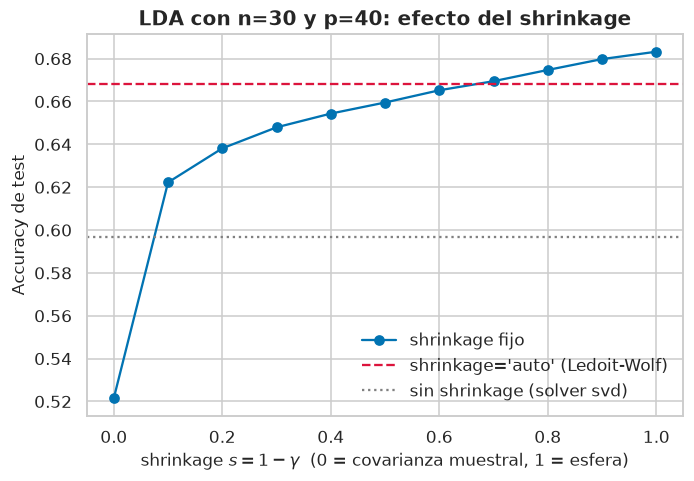

sin shrinkage 0.597 | mejor fijo 0.683 | auto 0.668


In [21]:
# n chico, p grande: 15 puntos por clase, p=40, dos clases, covarianza AR(1)
p3, n3, reps3 = 40, 15, 30
rho = 0.6
S3 = rho ** np.abs(np.subtract.outer(np.arange(p3), np.arange(p3)))
L3 = np.linalg.cholesky(S3)
delta3 = np.zeros(p3); delta3[:10] = 0.7
rng3 = np.random.default_rng(2)

def muestra3_rda(n):
    y = np.repeat([0, 1], n)
    return rng3.normal(size=(2 * n, p3)) @ L3.T + np.outer(y, delta3), y

shr = np.linspace(0, 1, 11)
acc = np.zeros((reps3, len(shr))); acc_auto = np.zeros(reps3); acc_none = np.zeros(reps3)
for r in range(reps3):
    Xtr, ytr = muestra3_rda(n3); Xte, yte = muestra3_rda(1000)
    for j, s in enumerate(shr):
        acc[r, j] = LDA(solver="lsqr", shrinkage=s).fit(Xtr, ytr).score(Xte, yte)
    acc_auto[r] = LDA(solver="lsqr", shrinkage="auto").fit(Xtr, ytr).score(Xte, yte)
    acc_none[r] = LDA(solver="svd").fit(Xtr, ytr).score(Xte, yte)

fig, ax = plt.subplots()
ax.plot(shr, acc.mean(0), marker="o", label="shrinkage fijo")
ax.axhline(acc_auto.mean(), color="crimson", ls="--", label="shrinkage='auto' (Ledoit-Wolf)")
ax.axhline(acc_none.mean(), color="gray", ls=":", label="sin shrinkage (solver svd)")
ax.set_title("LDA con n=30 y p=40: efecto del shrinkage")
ax.set_xlabel(r"shrinkage $s = 1-\gamma$  (0 = covarianza muestral, 1 = esfera)")
ax.set_ylabel("Accuracy de test")
ax.legend()
plt.show()
print(f"sin shrinkage {acc_none.mean():.3f} | mejor fijo {acc.mean(0).max():.3f} | auto {acc_auto.mean():.3f}")

Con $N=30 < p=40$ la covarianza muestral es singular: LDA sin encoger queda con una solución degenerada y el accuracy se resiente. Tirar la covarianza un poco hacia la esfera arregla el rango y baja la varianza de la estimación; `shrinkage="auto"` elige $s$ con la fórmula de Ledoit–Wolf, sin validación cruzada, y suele quedar cerca del mejor valor fijo. Es el mismo gesto que en ridge: $\hat\Sigma + \lambda I$ es invertible aunque $\hat\Sigma$ no lo sea.

#### ⚠️ Confusión típica

Mezclar los dos diales. $\alpha$ de (4.13) encoge **entre clases** (cada $\hat\Sigma_k$ hacia la común $\hat\Sigma$). $\gamma$ de (4.14) encoge **hacia la esfera** la propia $\hat\Sigma$. El parámetro `shrinkage` de `LinearDiscriminantAnalysis` es el segundo (y sólo existe con los solvers `lsqr` y `eigen`). `QuadraticDiscriminantAnalysis(reg_param=...)` no implementa el primero: encoge cada $\hat\Sigma_k$ hacia la identidad, no hacia la covarianza común. Por eso RDA de Friedman lo tuvimos que escribir a mano.

La otra trampa: creer que "reducir el rango" es lo mismo que PCA sobre $X$. PCA maximiza la varianza total de las proyecciones y no usa las etiquetas. Los discriminantes maximizan la varianza **entre clases relativa a la intra-clase**: se esferiza primero con $W$, y recién ahí se hace "PCA de los centroides". Un PCA puede tirar justo la dirección de menor varianza donde las clases se separan.

#### ❓ La pregunta que quedó abierta

¿Por qué reducir rango mejora también el error cuando ya estás clasificando bien? Porque cada dimensión discriminante extra agrega parámetros que hay que estimar (la posición de $K$ centroides en una dimensión más). Si esa dimensión casi no separa clases, lo que se gana en sesgo no compensa la varianza. ESL lo muestra con las vocales (Fig. 4.10) y vuelve a la cuestión en el capítulo 12, donde conecta LDA de rango reducido con regresión sobre la matriz indicadora y con otras formas de regularizar LDA.

> 🔗 **Conexión con las clases 4 y 5**: LDA sin encoger es equivariante ante cambios de escala, como OLS en la clase 4: reescalás una columna y $\hat\Sigma^{-1}$ lo compensa. Con `shrinkage` pasa lo de ridge: tirar hacia $\hat\sigma^2 I$ trata a todas las variables como si valieran lo mismo, y el resultado depende de las unidades. Chequealo en la celda de abajo. Si vas a encoger, estandarizá, y dentro de un `Pipeline`, como en la clase 4 (la clase 5 pide lo mismo para lasso).

In [22]:
# Equivarianza ante cambios de escala: multiplicamos una columna de wine por 100 y contamos cuántas predicciones cambian.
X_esc_eq = X_rda.copy()
X_esc_eq[:, 0] *= 100
for s_eq in (None, 0.5):
    p0_eq = LinearDiscriminantAnalysis(solver="lsqr", shrinkage=s_eq).fit(X_rda, y_rda).predict(X_rda)
    p1_eq = LinearDiscriminantAnalysis(solver="lsqr", shrinkage=s_eq).fit(X_esc_eq, y_rda).predict(X_esc_eq)
    print(f"shrinkage={s_eq}: cambian {(p0_eq != p1_eq).sum()} de {len(y_rda)} predicciones")

shrinkage=None: cambian 0 de 178 predicciones
shrinkage=0.5: cambian 40 de 178 predicciones


## 4.4 Regresión logística

📕 ESL §4.4 (con §4.3 como contraste)

Hasta acá, con LDA, modelamos cómo se **distribuyen las $X$ dentro de cada clase** y después dimos vuelta todo con Bayes. La regresión logística hace otra cosa: modela **directamente** la probabilidad de cada clase dado $x$, sin molestarse en describir cómo se ven las $X$.

Esta sección tiene seis partes: el modelo (4.4), cómo se ajusta (4.4.1), un ejemplo con datos de riesgo coronario (4.4.2), la inferencia que sale gratis del ajuste (4.4.3), la versión con penalización L1 (4.4.4) y la comparación con LDA (4.4.5).

> 🔗 **Conexión con la clase 1**: la regresión logística es el ejemplo típico de la **familia 2** del §7 (modelos discriminativos): modela solo $\Pr(G\mid X)$ y deja $p(X)$ sin tocar, porque para decidir no hace falta (se cancelaba en §5). Con LDA (§4.3, familia 1) ahora tenés los dos caminos del §7 lado a lado, y §4.4.5 es la discusión completa de cuándo conviene cada uno. La pregunta de la clase 1 "¿cuál es más fácil de medir, la conjunta o la condicional?" era el adelanto de esta sección.

#### El modelo: $K-1$ logits lineales

##### La idea en criollo

Queremos que $\Pr(G=k\mid X=x)$ sea función lineal de $x$. Problema: una combinación lineal cualquiera puede dar $-7$ o $12$, y una probabilidad vive en $[0,1]$. Además las $K$ probabilidades tienen que sumar uno.

La salida de ESL es no modelar la probabilidad sino su **log-odds** (o *logit*): el logaritmo del cociente entre la probabilidad de una clase y la de una clase de referencia. El log-odds sí puede valer cualquier número real, así que ahí la combinación lineal no molesta. Después se deshace el logaritmo y las probabilidades quedan bien portadas solas.

##### Formalizándolo

Se toma la última clase, $K$, como referencia y se escriben $K-1$ logits ($\beta_{k0}$ es el intercepto de la clase $k$ y $\beta_k$ el vector de pendientes):

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=K\mid X=x)} = \beta_{k0} + \beta_k^T x, \qquad k = 1,\dots,K-1.$$

Es el sistema (4.17) del libro. Despejamos. Llamemos $\eta_k = \beta_{k0}+\beta_k^Tx$ (leelo "eta": el logit de la clase $k$, o sea la combinación lineal antes de pasar por la exponencial). Aplicando la exponencial a ambos lados, $\Pr(G=k\mid x) = \Pr(G=K\mid x)\,e^{\eta_k}$. Como todo suma uno:

$$1 = \Pr(G=K\mid x)\Big(1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}\Big) \;\Rightarrow\; \Pr(G=K\mid x) = \frac{1}{1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}},$$

y reemplazando en la anterior:

$$\Pr(G=k\mid x) = \frac{e^{\eta_k}}{1+\sum_{\ell=1}^{K-1}e^{\eta_\ell}}, \qquad k=1,\dots,K-1.$$

Son las ecuaciones (4.18). Con $\theta$ (todos los parámetros juntos) las escribimos $p_k(x;\theta)$.

Dos observaciones:

- La elección de la clase de referencia es arbitraria: cambiarla reparametriza el modelo pero las probabilidades ajustadas son las mismas.
- Para $K=2$ queda **una sola** función lineal, $\log\frac{p}{1-p} = \beta^Tx$, y $p = \frac{1}{1+e^{-\beta^Tx}}$ (la sigmoide). Es el caso que se usa en biostatística: sobrevive/muere, enfermo/sano.

##### ¿Por qué nos importa?

Porque te da un clasificador con frontera lineal (los puntos donde dos logits se igualan) **y** probabilidades que, por construcción, caen en $[0,1]$ y suman uno, como salida directa del modelo, no un subproducto de un ajuste por mínimos cuadrados como en §4.2 (recordá que la regresión lineal de indicadores puede dar "probabilidades" fuera de $[0,1]$).

##### En código

Un chequeo corto con $K=3$: las probabilidades con clase de referencia suman uno y no importa cuál clase elijas de referencia.

In [23]:
import numpy as np
from scipy.special import softmax

rng_log = np.random.default_rng(0)
x_log = rng_log.normal(size=2)
B_log = rng_log.normal(size=(3, 2))   # tres clases, sin intercepto para simplificar
eta_log = B_log @ x_log

# Forma (4.18): clases 1..K-1 contra la referencia K (la tercera)
num_log = np.exp(eta_log[:2] - eta_log[2])
p_ref_log = np.append(num_log, 1) / (1 + num_log.sum())
# Forma simétrica (softmax) con las tres logits: es el mismo modelo
p_soft_log = softmax(eta_log)

print("con referencia K :", p_ref_log.round(4), "suma =", p_ref_log.sum().round(4))
print("softmax          :", p_soft_log.round(4))
print("mismas probabilidades:", np.allclose(p_ref_log, p_soft_log))

con referencia K : [0.3563 0.2971 0.3466] suma = 1.0
softmax          : [0.3563 0.2971 0.3466]
mismas probabilidades: True


##### ⚠️ Confusión típica

Creer que "logística" es una sigmoide aplicada a *cualquier cosa* y que lo lineal es la probabilidad. Lo lineal es el **logit**. La probabilidad es una curva en forma de S en $x$, y un mismo aumento de $x$ mueve la probabilidad distinto según dónde estés parado (cerca de $p=0{,}5$ mueve mucho; cerca de 0 o 1, casi nada).

#### 4.4.1 Ajuste: verosimilitud, gradiente, Hessiano, Newton e IRLS

##### La idea en criollo

Se ajusta por **máxima verosimilitud condicional**: elegimos los $\beta$ que hacen más probable haber observado las clases que observamos, dado los $x$. Como $\Pr(G\mid X)$ especifica por completo la distribución condicional de $G$, la distribución adecuada es la multinomial (para $K=2$, la Bernoulli).

No hay fórmula cerrada como en cuadrados mínimos: la ecuación a resolver es no lineal en $\beta$. Se resuelve iterando con Newton–Raphson, y resulta que cada paso de Newton es **una regresión por cuadrados mínimos ponderados**. Por eso se llama IRLS, *iteratively reweighted least squares*.

##### Formalizándolo: la log-verosimilitud

Para $N$ observaciones: $\ell(\theta)=\sum_{i=1}^N\log p_{g_i}(x_i;\theta)$ (4.19), donde $g_i$ es la clase observada de la observación $i$.

Nos quedamos con $K=2$. Codificamos $y_i=1$ si $g_i=1$ e $y_i=0$ si $g_i=2$, y escribimos $p(x;\beta)=p_1(x;\beta)$. Incluimos el 1 del intercepto dentro de $x_i$, así $\beta$ tiene $p+1$ componentes. (Ojo: el libro usa $p$ para dos cosas, la cantidad de predictores y la probabilidad $p(x;\beta)$; el contexto decide. Acá $p_i$ con subíndice es siempre la probabilidad.) Como $y_i$ es 0 o 1, el log de la probabilidad de la clase observada es $y_i\log p_i+(1-y_i)\log(1-p_i)$:

$$\ell(\beta)=\sum_{i=1}^N\Big\{y_i\log p(x_i;\beta)+(1-y_i)\log\big(1-p(x_i;\beta)\big)\Big\}.$$

Con $p_i = \frac{e^{\beta^Tx_i}}{1+e^{\beta^Tx_i}}$ tenemos $\log p_i=\beta^Tx_i-\log(1+e^{\beta^Tx_i})$ y $\log(1-p_i)=-\log(1+e^{\beta^Tx_i})$. Sustituyendo y juntando los $\log(1+e^{\beta^T x_i})$:

$$\ell(\beta)=\sum_{i=1}^N\Big\{y_i\,\beta^Tx_i-\log\big(1+e^{\beta^Tx_i}\big)\Big\}\qquad\text{(4.20)}.$$

##### Formalizándolo: gradiente (score)

Derivamos respecto de $\beta$. La derivada de $y_i\beta^Tx_i$ es $y_ix_i$. Para el segundo término, por regla de la cadena:

$$\frac{\partial}{\partial\beta}\log\big(1+e^{\beta^Tx_i}\big)=\frac{e^{\beta^Tx_i}}{1+e^{\beta^Tx_i}}\,x_i=p_i\,x_i.$$

Entonces

$$\frac{\partial\ell}{\partial\beta}=\sum_{i=1}^Nx_i\big(y_i-p(x_i;\beta)\big)=0\qquad\text{(4.21, ecuaciones de score)}.$$

Son $p+1$ ecuaciones no lineales en $\beta$ (porque $p_i$ depende de $\beta$). Mirá la primera: como la primera componente de $x_i$ es 1, da $\sum y_i=\sum p_i$. El número **esperado** de unos según el modelo es igual al número observado. Eso lo vamos a chequear en código.

##### Formalizándolo: Hessiano

Derivamos de nuevo. La derivada de $p_i$ respecto de $\beta$ es $p_i(1-p_i)x_i$ (derivada de la sigmoide por la cadena). La cuenta: con $\eta_i=\beta^Tx_i$ y $p_i=e^{\eta_i}/(1+e^{\eta_i})$, $\dfrac{dp_i}{d\eta_i}=\dfrac{e^{\eta_i}(1+e^{\eta_i})-e^{\eta_i}e^{\eta_i}}{(1+e^{\eta_i})^2}=\dfrac{e^{\eta_i}}{1+e^{\eta_i}}\cdot\dfrac{1}{1+e^{\eta_i}}=p_i(1-p_i)$, y por la cadena $\partial\eta_i/\partial\beta=x_i$. Como $\partial\,[x_i(y_i-p_i)]/\partial\beta^T=-x_i\,\partial p_i/\partial\beta^T$:

$$\frac{\partial^2\ell}{\partial\beta\,\partial\beta^T}=-\sum_{i=1}^Nx_ix_i^T\,p_i(1-p_i)\qquad\text{(4.22)}.$$

Este Hessiano es **definido negativo** cuando $\mathbf{X}$ tiene rango columna completo, porque $v^T\big(\sum x_ix_i^Tp_i(1-p_i)\big)v=\sum p_i(1-p_i)(x_i^Tv)^2>0$ con signo menos. Por eso $\ell$ es **cóncava** (no hay máximos locales, y hay un único máximo siempre que exista: con clases perfectamente separables no existe, ver 4.4.5). Esto es lo que el libro resume como "la log-verosimilitud es cóncava".

##### Formalizándolo: paso de Newton y paso a IRLS

En notación matricial: $\mathbf{y}$ vector de respuestas, $\mathbf{X}$ la matriz $N\times(p+1)$ de los $x_i$, $\mathbf{p}$ el vector de probabilidades ajustadas con $\beta^{old}$, y $\mathbf{W}$ diagonal $N\times N$ con $W_{ii}=p_i(1-p_i)$. Entonces

$$\frac{\partial\ell}{\partial\beta}=\mathbf{X}^T(\mathbf{y}-\mathbf{p})\quad(4.24),\qquad \frac{\partial^2\ell}{\partial\beta\partial\beta^T}=-\mathbf{X}^T\mathbf{W}\mathbf{X}\quad(4.25).$$

Newton: $\beta^{new}=\beta^{old}-\big(\text{Hessiano}\big)^{-1}\,\text{gradiente}$ (4.23). Con los signos:

$$\beta^{new}=\beta^{old}+(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T(\mathbf{y}-\mathbf{p}).$$

Ahora el truco. Escribimos $\beta^{old}=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{X}\beta^{old}$ (multiplicar por la identidad) y sacamos factor común a la izquierda. Como $\mathbf{X}^T(\mathbf{y}-\mathbf{p})=\mathbf{X}^T\mathbf{W}\,\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})$:

$$\beta^{new}=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\Big(\mathbf{X}\beta^{old}+\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})\Big)=(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\mathbf{X}^T\mathbf{W}\mathbf{z}\quad(4.26).$$

Con la **respuesta ajustada** $\mathbf{z}=\mathbf{X}\beta^{old}+\mathbf{W}^{-1}(\mathbf{y}-\mathbf{p})$ (4.27). Eso es exactamente la solución de cuadrados mínimos ponderados con pesos $W_{ii}$ (4.28):

$$\beta^{new}\leftarrow\arg\min_\beta(\mathbf{z}-\mathbf{X}\beta)^T\mathbf{W}(\mathbf{z}-\mathbf{X}\beta).$$

Leelo así: $\mathbf{z}$ es "el $\mathbf{y}$ linealizado" (la respuesta en la escala del logit) y $W_{ii}$ pesa más a las observaciones cuya probabilidad está cerca de 0,5 (donde $p(1-p)$ es máximo) y casi ignora las que ya están clarísimas. En cada iteración $\mathbf{p}$ cambia, y con él $\mathbf{W}$ y $\mathbf{z}$: de ahí el "reweighted".

##### Arranque, convergencia y multiclase

El libro sugiere arrancar con $\beta=0$. La convergencia no está garantizada (puede haber *overshooting*, pasarse de largo), aunque suele converger porque $\ell$ es cóncava; si la log-verosimilitud baja, se corrige **reduciendo a la mitad el paso**. Para $K\ge3$ también hay IRLS, pero con un vector de $K-1$ respuestas y una matriz de pesos **no diagonal** por observación, y ahí conviene trabajar directo con el vector $\theta$ expandido (ejercicio 4.4 del libro) o con descenso por coordenadas (el paquete `glmnet`; 📕 ESL §3.8.6).

##### ¿Por qué nos importa?

Porque es la primera vez que ves lo que va a repetirse todo el curso: un problema sin solución cerrada se resuelve como **una sucesión de problemas de cuadrados mínimos**. Y porque $(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}$ va a reaparecer como matriz de covarianza de $\hat\beta$ en 4.4.3.

> 🔗 **Conexión con las clases 2 y 3**: esto es el marco de máxima verosimilitud de la clase 3 (§2), la misma receta: independencia, producto, logaritmo y suma. Lo único que cambia es la distribución: en la clase 3 $y_i\mid x_i$ era normal y la log-verosimilitud te quedaba $-\tfrac{1}{2\sigma^2}RSS$ más constantes, de modo que maximizar equivalía a minimizar $RSS$ y salía la ecuación normal; acá $y_i$ es Bernoulli, la log-verosimilitud es (4.20) y ya no hay $RSS$ que minimizar. La clase 3 dejó dicho que ese marco se generaliza a modelos sin solución cerrada, con la regresión logística y los GLM como ejemplos. Y la clase 2 (§2) te avisaba lo mismo: cambiás la pérdida cuadrática por otra cosa (nombra justamente la regresión logística) y la solución cerrada desaparece. Lo que sobrevive es el **argumento de curvatura**: el Hessiano $-\mathbf{X}^T\mathbf{W}\mathbf{X}$ se prueba definido con el mismo truco que $v^T\mathbf{X}^T\mathbf{X}v=\|\mathbf{X}v\|^2$ (aquí, una suma ponderada de $(x_i^Tv)^2$), y cada paso de Newton es una ecuación normal ponderada que se resuelve con `solve`, no con `inv`. No lo confundas con el SGD de la clase 2 (§6): Newton usa también la curvatura.

> 🔗 **Conexión con la clase 4** (esto no lo dijo la clase, pero se sigue de su cuenta): la clase 4 (§4) mostró que $v^T(\mathbf{X}^T\mathbf{X}+\lambda I)v=\|\mathbf{X}v\|^2+\lambda\|v\|^2>0$ para todo $v\neq0$, sin pedirle nada a $\mathbf{X}$. Con los pesos del IRLS queda $\sum_i W_{ii}(x_i^Tv)^2+\lambda\|v\|^2$, positivo por el mismo motivo: una penalización cuadrática devuelve un máximo único aunque $\mathbf{X}$ no tenga rango completo.

##### Los datos: un riesgo coronario simulado

El dataset del libro (South African Heart Disease, 462 varones, 160 casos de infarto y 302 controles) **no lo podemos descargar desde acá**. Armamos uno **análogo con nuestro propio generador**: siete factores de riesgo con los mismos nombres y escalas parecidas (`sbp`, `tobacco`, `ldl`, `famhist`, `obesity`, `alcohol`, `age`), correlacionados entre sí como en el original (la presión y la obesidad crecen con la edad), y una respuesta generada con un modelo logístico **cuyos coeficientes verdaderos conocemos**. Así podemos comparar lo estimado contra lo verdadero. Los resultados numéricos **no** van a coincidir con la Tabla 4.2 del libro: es otro dataset.

In [24]:
from scipy.optimize import brentq

rng_log = np.random.default_rng(42)
n_log = 462
age_log = np.clip(rng_log.normal(43, 14, n_log), 15, 64)
obesity_log = 25.5 + 0.05 * (age_log - 43) + rng_log.normal(0, 3.5, n_log)
sbp_log = 138 + 0.4 * (age_log - 43) + 1.0 * (obesity_log - 25.5) + rng_log.normal(0, 15, n_log)
tobacco_log = rng_log.gamma(0.8, 4.0, n_log) + 0.05 * (age_log - 15)   # sesgada a la derecha
ldl_log = np.clip(4.7 + 0.02 * (age_log - 43) + rng_log.normal(0, 1.6, n_log), 1, None)
famhist_log = rng_log.binomial(1, 0.4, n_log).astype(float)
alcohol_log = rng_log.gamma(0.7, 20, n_log)

nombres_log = ["sbp", "tobacco", "ldl", "famhist", "obesity", "alcohol", "age"]
df_log = pd.DataFrame(dict(sbp=sbp_log, tobacco=tobacco_log, ldl=ldl_log, famhist=famhist_log,
                           obesity=obesity_log, alcohol=alcohol_log, age=age_log))

# Coeficientes verdaderos (el intercepto se calibra para tener ~35% de casos, como 160/462)
beta_ver_log = np.array([0.006, 0.08, 0.17, 0.9, -0.03, 0.0, 0.045])
Xs_log = df_log.values
f_log = lambda b0: (1 / (1 + np.exp(-(b0 + Xs_log @ beta_ver_log)))).mean() - 0.35
b0_ver_log = brentq(f_log, -20, 5)
p_ver_log = 1 / (1 + np.exp(-(b0_ver_log + Xs_log @ beta_ver_log)))
y_log = rng_log.binomial(1, p_ver_log).astype(float)
df_log["chd"] = y_log

print(f"intercepto verdadero = {b0_ver_log:.3f} | casos = {int(y_log.sum())} de {n_log}")
print(df_log.groupby("chd")[["tobacco", "ldl", "age", "sbp", "obesity"]].median().round(1))
print("corr(sbp, obesity) =", df_log[["sbp", "obesity"]].corr().iloc[0, 1].round(2),
      "| corr(sbp, age) =", df_log[["sbp", "age"]].corr().iloc[0, 1].round(2))

intercepto verdadero = -4.230 | casos = 146 de 462
     tobacco  ldl   age    sbp  obesity
chd                                    
0.0      2.9  4.5  39.4  135.9     25.3
1.0      4.5  5.3  49.7  142.6     25.5
corr(sbp, obesity) = 0.29 | corr(sbp, age) = 0.3


##### En código: IRLS a mano

Implementamos exactamente (4.26)–(4.28). Tres cuidados numéricos:

- el término $\mathbf{X}^T\mathbf{W}\mathbf{X}$ se arma como `X.T @ (w[:, None] * X)`, sin construir la matriz diagonal $N\times N$;
- en vez de invertir resolvemos el sistema con `np.linalg.solve`, igual que en cuadrados mínimos;
- guardamos $\ell(\beta)$ en cada iteración para ver la convergencia.

iteración 0: log-verosimilitud = -320.233997
iteración 1: log-verosimilitud = -237.945053
iteración 2: log-verosimilitud = -232.009838
iteración 3: log-verosimilitud = -231.788416
iteración 4: log-verosimilitud = -231.787945
iteración 5: log-verosimilitud = -231.787945
iteración 6: log-verosimilitud = -231.787945

suma(y) = 146.0 | suma(p_hat) = 146.0  <- primera ecuación de score
score X'(y-p) ~ 0: 1e-10


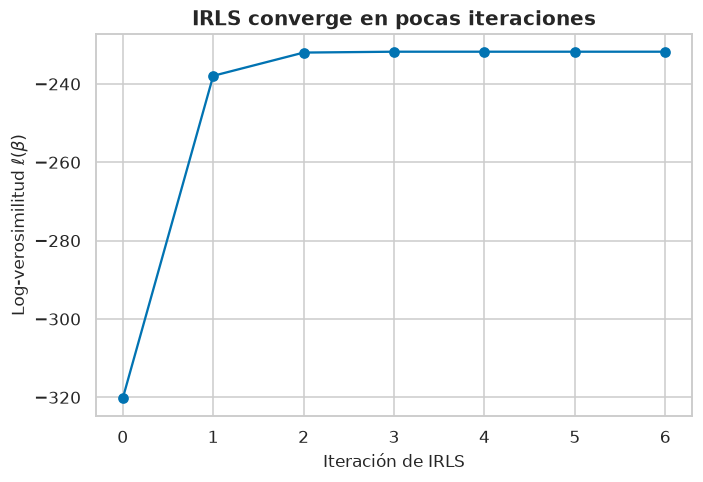

In [25]:
def loglik_log(beta, X, y):
    eta = X @ beta
    return np.sum(y * eta - np.logaddexp(0, eta))    # (4.20), estable numéricamente

def irls_log(X, y, tol=1e-10, max_iter=25):
    beta = np.zeros(X.shape[1])                      # arranque sugerido por el libro
    historia = [loglik_log(beta, X, y)]
    for _ in range(max_iter):
        p = 1 / (1 + np.exp(-(X @ beta)))
        w = p * (1 - p)                              # diagonal de W
        z = X @ beta + (y - p) / w                   # respuesta ajustada (4.27)
        XtWX = X.T @ (w[:, None] * X)
        beta = np.linalg.solve(XtWX, X.T @ (w * z))  # cuadrados mínimos ponderados (4.26)
        historia.append(loglik_log(beta, X, y))
        if abs(historia[-1] - historia[-2]) < tol:
            break
    return beta, historia, XtWX

X_log = np.column_stack([np.ones(n_log), df_log[nombres_log].values])   # columna de unos = intercepto
beta_irls_log, hist_log, XtWX_log = irls_log(X_log, y_log)

for i, l in enumerate(hist_log):
    print(f"iteración {i}: log-verosimilitud = {l:.6f}")

p_hat_log = 1 / (1 + np.exp(-(X_log @ beta_irls_log)))
print("\nsuma(y) =", y_log.sum(), "| suma(p_hat) =", p_hat_log.sum().round(6), " <- primera ecuación de score")
print("score X'(y-p) ~ 0:", np.abs(X_log.T @ (y_log - p_hat_log)).max().round(10))

fig, ax = plt.subplots()
ax.plot(range(len(hist_log)), hist_log, "o-")
ax.set_xlabel("Iteración de IRLS")
ax.set_ylabel(r"Log-verosimilitud $\ell(\beta)$")
ax.set_title("IRLS converge en pocas iteraciones")
plt.show()

Fijate en la curva: sube monótonamente y se estabiliza en unas 5 o 6 iteraciones. Newton converge cuadráticamente cerca del máximo, así que las últimas iteraciones cambian dígitos muy lejanos. Además comprobamos las dos propiedades que salían de la teoría: las ecuaciones de score se anulan y $\sum y_i=\sum\hat p_i$.

Además el paso de Newton lo hicimos **sin** reducir el paso a la mitad porque acá no hizo falta. Si la log-verosimilitud bajara, habría que hacerlo (ver el comentario del libro arriba).

##### 🏭 Así se hace en la industria

`statsmodels` (enfoque estadístico: errores estándar, tests) y `sklearn` (enfoque predictivo). Con `C=np.inf` (equivale al viejo `penalty=None`) sklearn resuelve el mismo problema sin penalización. Comparamos coeficientes, errores estándar y Z-scores. Los errores estándar salen de la raíz de la diagonal de $(\mathbf{X}^T\hat{\mathbf{W}}\mathbf{X})^{-1}$, que es la matriz de covarianza asintótica de $\hat\beta$ (la explicamos enseguida en 4.4.3).

In [26]:
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

cov_log = np.linalg.inv(XtWX_log)                 # (X' W X)^{-1} evaluada en beta-sombrero
se_irls_log = np.sqrt(np.diag(cov_log))

res_sm_log = sm.Logit(y_log, X_log).fit(disp=0)   # Newton (la misma idea) con errores estándar
skl_log = LogisticRegression(C=np.inf, max_iter=5000).fit(X_log[:, 1:], y_log)

idx_log = ["(Intercept)"] + nombres_log
tabla_log = pd.DataFrame({
    "coef IRLS": beta_irls_log, "coef statsmodels": res_sm_log.params,
    "coef sklearn": np.r_[skl_log.intercept_, skl_log.coef_.ravel()],
    "EE IRLS": se_irls_log, "EE statsmodels": res_sm_log.bse,
    "Z IRLS": beta_irls_log / se_irls_log, "Z statsmodels": res_sm_log.tvalues,
}, index=idx_log)
print(tabla_log.round(3).to_string())
print("\ncoeficientes coinciden (IRLS vs statsmodels):", np.allclose(beta_irls_log, res_sm_log.params, atol=1e-6))
print("coeficientes coinciden (IRLS vs sklearn)    :", np.allclose(beta_irls_log, tabla_log["coef sklearn"], atol=1e-3))
print("errores estándar coinciden                  :", np.allclose(se_irls_log, res_sm_log.bse, atol=1e-6))

             coef IRLS  coef statsmodels  coef sklearn  EE IRLS  EE statsmodels  Z IRLS  Z statsmodels
(Intercept)     -6.230            -6.230        -6.230    1.243           1.243  -5.014         -5.014
sbp              0.015             0.015         0.015    0.008           0.008   1.961          1.961
tobacco          0.096             0.096         0.096    0.032           0.032   3.039          3.039
ldl              0.126             0.126         0.126    0.074           0.074   1.715          1.715
famhist          0.846             0.846         0.846    0.233           0.233   3.629          3.629
obesity         -0.069            -0.069        -0.069    0.034           0.034  -2.014         -2.014
alcohol          0.002             0.002         0.002    0.006           0.006   0.295          0.295
age              0.080             0.080         0.080    0.011           0.011   7.055          7.055

coeficientes coinciden (IRLS vs statsmodels): True
coeficientes coincide

Tres implementaciones, mismos números. `statsmodels.GLM(..., family=Binomial())` también daría lo mismo: es justamente el "GLM" que el libro menciona en 4.4.3, implementado con IRLS. La versión de `sklearn` coincide hasta la tolerancia del optimizador (usa L-BFGS, no Newton).

##### ⚠️ Confusión típica

- Pensar que IRLS y "descenso por gradiente" son lo mismo. El gradiente usa solo la pendiente; Newton usa también la curvatura (el Hessiano), y por eso converge en una decena de iteraciones y no en cientos.
- Olvidarse de la columna de unos. En ESL el intercepto está *dentro* de $x_i$; si no la agregás, el modelo no tiene término constante y además deja de valer la propiedad $\sum y_i=\sum\hat p_i$.
- Que la probabilidad de 0,5 sea la frontera: es la frontera de decisión **bajo pérdida 0-1**. Si los errores cuestan distinto (como en medicina), el umbral cambia (ver §2.4).

##### ❓ La pregunta que quedó abierta

¿Qué pasa si las clases son perfectamente separables por un hiperplano? Entonces $\ell$ no tiene máximo finito: crece para siempre al agrandar $\|\beta\|$, IRLS no converge y los coeficientes se van al infinito. Lo retomamos en 4.4.5, donde LDA sí da estimaciones finitas para esos mismos datos.

> 🔗 **Conexión con la clase 1**: ese "ver §2.4" es el $\hat G(x)=\arg\min_g\sum_k L(\mathcal{G}_k,g)\,p(\mathcal{G}_k\mid x)$ de la clase 1 (§6). En el ejemplo de allá, si el falso "aprueba" costaba 5 veces más, el umbral subía de $0{,}5$ a $5/6$ sin tocar el modelo. Como la logística te entrega $\hat p(x)$, podés cambiar la matriz de pérdida después de ajustar y solo mover el umbral, cosa que no podías hacer con una función discriminante pura (§7).

#### 4.4.2 Ejemplo: riesgo coronario (South African Heart Disease)

##### La idea en criollo

El libro usa regresión logística en su versión "clásica": no para clasificar mejor sino para **entender** cuánto aporta cada factor de riesgo. Los datos son del estudio CORIS en tres zonas rurales de Western Cape, Sudáfrica: varones blancos de 15 a 64 años, respuesta = presencia de infarto de miocardio al momento de la encuesta (prevalencia global de 5,1% en la región; la muestra tiene 160 casos y 302 controles, o sea se sobremuestreó a los casos). La Tabla 4.2 del libro reporta para cada predictor: coeficiente, error estándar y Z-score.

Nosotros ya tenemos la tabla análoga arriba, con datos simulados. Leela como se lee la del libro.

**Las figuras y tablas del libro.** La **Figura 4.12** es una matriz de dispersión de los factores de riesgo, con los casos en rojo. Sirve para ver a ojo lo que el modelo después cuantifica: los casos tienen más tabaco y más edad, y `sbp` y `obesity` se mueven con la edad (predictores correlacionados). La **Tabla 4.2** es el ajuste con los siete predictores. Los que más cuentan son `famhist` (coef. $0{,}939$, $Z=4{,}18$), `age` ($0{,}043$, $Z=4{,}18$), `ldl` ($0{,}185$, $Z=3{,}22$) y `tobacco` ($0{,}080$, $Z=3{,}03$), y los dos "sorprendentes" son `sbp` ($0{,}006$, $Z=1{,}02$) y `obesity` ($-0{,}035$, $Z=-1{,}19$). La **Tabla 4.3** es el modelo que queda tras eliminar de a uno, con sólo `tobacco` ($0{,}081$, EE $0{,}026$), `ldl` ($0{,}168$), `famhist` ($0{,}924$) y `age` ($0{,}044$). Los $0{,}081$ que usamos abajo para el odds ratio salen de esta segunda tabla. En el libro el tabaco se mide en kg acumulados de por vida, con mediana de $1{,}0$ kg entre los controles y $4{,}1$ kg entre los casos. Por eso "1 kg más" es un salto razonable.

##### Formalizándolo: cómo se interpreta

- **Z-score** = coeficiente / error estándar. Corresponde formalmente a un test (de Wald) de que *ese* coeficiente es cero, **con los demás en el modelo**. $|Z|>2$ es significativo al 5% aproximadamente.
- **Sorpresas del libro:** `sbp` no es significativo, y `obesity` tampoco y además con signo negativo. El libro lo atribuye a la correlación entre predictores: por separado ambos son significativos y con signo positivo, pero **en presencia de otras variables correlacionadas ya no hacen falta**, y hasta pueden cambiar de signo. Nuestros datos simulados tienen predictores correlacionados (presión y obesidad crecen con la edad), así que se espera un efecto parecido, aunque no idéntico.
- **Selección de variables:** el libro primero elimina repetidamente el coeficiente menos significativo y reajusta (Tabla 4.3: quedan `tobacco`, `ldl`, `famhist`, `age`). Una estrategia mejor pero más lenta es reajustar el modelo sacando cada variable y hacer un **análisis de deviance**, que da el mismo modelo final. Definición del libro: la *deviance residual* de un modelo ajustado es $-2$ veces su log-verosimilitud, y la deviance entre dos modelos es la diferencia de sus deviances residuales (análogo a las sumas de cuadrados).
- **Interpretación como odds ratio:** el coeficiente de `tobacco` $=0{,}081$ (EE $=0{,}026$) significa que 1 kg más de tabaco acumulado multiplica los **odds** de enfermedad por $e^{0{,}081}=1{,}084$, es decir un aumento de 8,4%. Con el error estándar, un IC aproximado al 95% es $e^{0{,}081\pm2\times0{,}026}=(1{,}03;\,1{,}14)$. Cuidado: es el cambio en el *odds*, no en la probabilidad.

El libro cierra el ejemplo avisando que en el capítulo 5 algunas variables muestran efectos no lineales y, bien modeladas, no quedan excluidas.

##### ¿Por qué nos importa?

Porque en un modelo con predictores correlacionados **un coeficiente no significa lo mismo que un efecto marginal**. Es el mismo problema de multicolinealidad que viste en regresión lineal.

> 🔗 **Conexión con la clase 1**: acá se usa la logística en el modo **inferencia** de la tabla del §1 (entender qué factores pesan y cuánto, aun si predice un poco peor), no en el de predicción. Además, que la muestra esté sobremuestreada en casos (160 contra 302, con prevalencia real de 5,1%) te tiene que sonar al argumento del §3: como modelamos solo la condicional $\Pr(G\mid X)$, no necesitamos que la muestra reproduzca las proporciones reales de cada perfil. Ojo con el intercepto: esto no lo dijo la clase ni el capítulo, pero se sigue de que el modelo no ve el prior, y es la parte que sí "siente" esa proporción (en un muestreo de casos y controles como este, lo que se desplaza es el intercepto, no las pendientes).

##### En código

Empezamos con el equivalente de la Fig. 4.12 sobre nuestros datos simulados (los casos, `chd = 1`, en otro color). Después hacemos lo que hace el libro sobre nuestros datos: la tabla completa, la regresión descartando de a un coeficiente (eliminación hacia atrás) y la interpretación de `tobacco` como odds ratio.

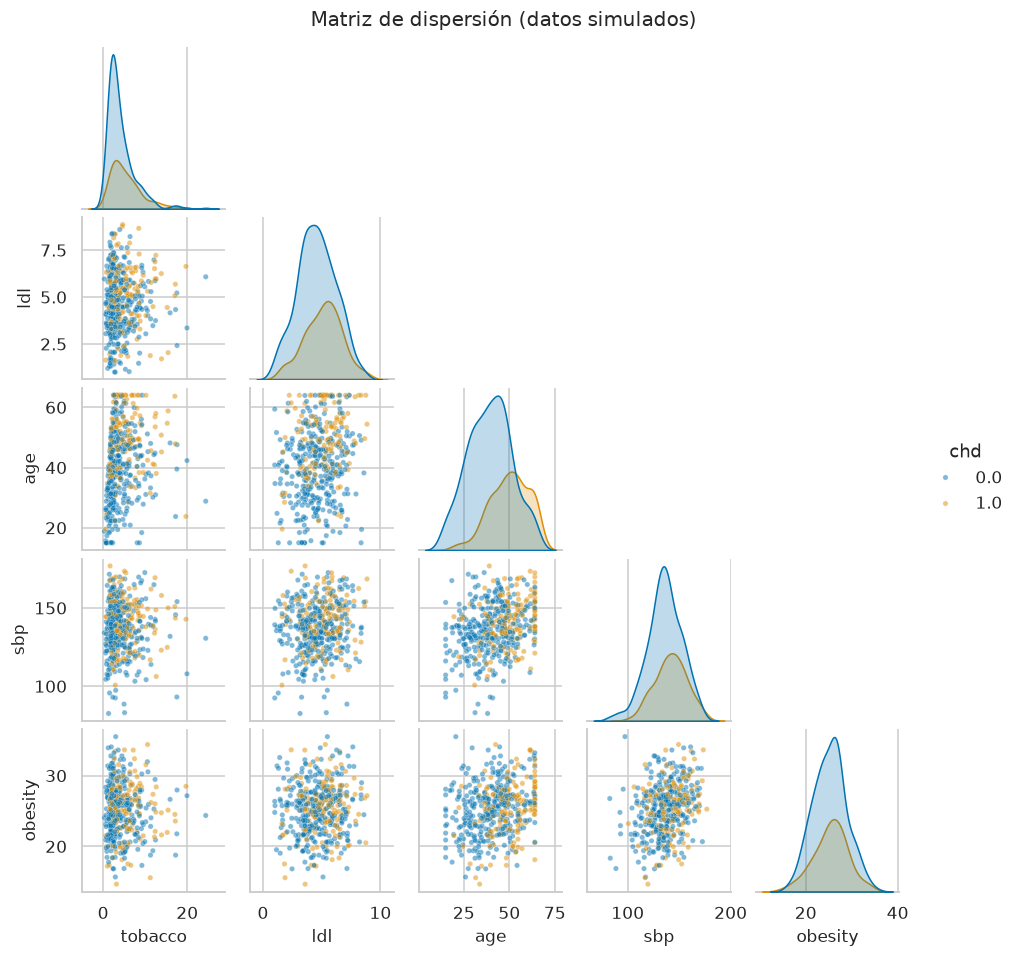

In [27]:
# Equivalente (con datos simulados) de la Fig. 4.12: matriz de dispersión con los casos en otro color.
g_pair = sns.pairplot(df_log[["tobacco", "ldl", "age", "sbp", "obesity", "chd"]], hue="chd",
                      corner=True, plot_kws=dict(s=12, alpha=0.5), height=1.7)
g_pair.figure.suptitle("Matriz de dispersión (datos simulados)", y=1.02)
plt.show()

In [28]:
# 1) ¿Las variables correlacionadas "se pisan"? sbp y obesity solas vs con todas
solo_log = {v: sm.Logit(y_log, sm.add_constant(df_log[[v]])).fit(disp=0) for v in ["sbp", "obesity"]}
for v, r in solo_log.items():
    print(f"{v:8s} sola  : coef = {r.params[v]: .3f}, Z = {r.tvalues[v]: .2f}")
    print(f"{v:8s} todas : coef = {res_sm_log.params[idx_log.index(v)]: .3f}, Z = {res_sm_log.tvalues[idx_log.index(v)]: .2f}")

# 2) Eliminación hacia atrás: sacamos la variable con menor |Z| hasta que todas pasen |Z| > 2
vars_log = list(nombres_log)
while True:
    r = sm.Logit(y_log, sm.add_constant(df_log[vars_log])).fit(disp=0)
    z = r.tvalues.drop("const").abs()
    if z.min() > 2 or len(vars_log) == 1:
        break
    vars_log.remove(z.idxmin())
print("\nModelo final:", vars_log)
print(pd.DataFrame({"coef": r.params, "EE": r.bse, "Z": r.tvalues}).round(3))

# 3) Odds ratio de tobacco con IC aproximado del 95% (coef +/- 2 EE, como en el libro)
b_t, se_t = res_sm_log.params[2], res_sm_log.bse[2]
print(f"\ntobacco: OR = {np.exp(b_t):.3f}, IC95% ~ ({np.exp(b_t - 2*se_t):.3f}, {np.exp(b_t + 2*se_t):.3f})")

sbp      sola  : coef =  0.023, Z =  3.59
sbp      todas : coef =  0.015, Z =  1.96
obesity  sola  : coef =  0.015, Z =  0.55
obesity  todas : coef = -0.069, Z = -2.01

Modelo final: ['tobacco', 'famhist', 'age']
          coef     EE      Z
const   -5.283  0.560 -9.430
tobacco  0.095  0.032  2.984
famhist  0.856  0.229  3.732
age      0.083  0.011  7.694

tobacco: OR = 1.101, IC95% ~ (1.033, 1.173)


Las salidas muestran el mecanismo que describía el libro: `sbp` sola tiene coeficiente positivo y Z alto, pero con las demás (que comparten la edad con ella) su Z cae a un valor marginal; `obesity`, que sola no dice nada, cambia de signo al entrar con el resto. Los números exactos dependen de la semilla: no es la Tabla 4.2 y no coincide en qué variables se caen, pero el fenómeno (los coeficientes individuales dependen de quién más esté en el modelo) es el mismo. La eliminación hacia atrás deja un modelo chico con las variables que más pesan.

##### ⚠️ Confusión típica

Leer un Z-score chico como "esta variable no importa". Lo que dice es que, **dado el resto del modelo**, su aporte adicional no se distingue del ruido. Si la sacás del modelo y otra correlacionada con ella queda adentro, la información sigue estando. Además, un $|Z|>2$ no te dice que la variable sea un *buen predictor*: te dice que el coeficiente es estadísticamente distinto de cero.

> 🔗 **Conexión con las clases 2, 3, 4 y 5**: lo de `obesity` cambiando de signo al entrar con el resto es el experimento de la clase 3 (§3) pero en escala de log-odds: con columnas casi redundantes cada coeficiente individual salta (hasta de signo) y solo se mantiene estable el efecto conjunto. Es la nube estirada de la clase 4 (§2): con predictores correlacionados el modelo sigue prediciendo bien, pero el reparto entre coeficientes es inestable. Y la advertencia sobre el Z-score es la de la clase 2 (§5) y la del lasso en la clase 5 (§8): un $Z$ chico, o un coeficiente en cero, dice que, **dadas las demás variables que quedaron**, ésta no agrega algo distinguible del ruido, no que no esté relacionada con $G$. Si sacás una, la otra carga con su trabajo.

> 🔗 **Conexión con la clase 5**: la eliminación hacia atrás de esta celda es selección de subconjuntos: cada variable está adentro, con su coeficiente sin encoger, o afuera. Es el primo *hard* del *soft-thresholding* de la clase 5 (§4): decisión discontinua y sensible a qué otras variables estén presentes. Más abajo, en §4.4.4, la penalización L1 es la relajación continua de esta misma idea.

#### 4.4.3 Aproximaciones cuadráticas e inferencia

##### La idea en criollo

Una vez que IRLS converge, el ajuste final es **un problema de cuadrados mínimos ponderados** con pesos $\hat w_i$ (los $w_i=\hat p_i(1-\hat p_i)$ de IRLS, evaluados en la solución) y respuesta $z_i$, evaluados en $\hat\beta$. Eso significa que casi toda la inferencia que conocés de regresión lineal (errores estándar, tests, intervalos) se traslada con pequeños cambios, y vale **asintóticamente** (muestras grandes), no de forma exacta.

##### Formalizándolo

Los estimadores de máxima verosimilitud cumplen una relación de autoconsistencia: son los coeficientes de un ajuste por cuadrados mínimos ponderados con respuestas y pesos

$$z_i=x_i^T\hat\beta+\frac{y_i-\hat p_i}{\hat p_i(1-\hat p_i)},\qquad w_i=\hat p_i(1-\hat p_i)\qquad\text{(4.29)},$$

ambos dependiendo del propio $\hat\beta$. De esa conexión salen cuatro cosas (las cuatro viñetas del libro):

1. **Estadístico de Pearson.** La suma de cuadrados residual ponderada es el estadístico $\chi^2$ de Pearson
$$\sum_{i=1}^N\frac{(y_i-\hat p_i)^2}{\hat p_i(1-\hat p_i)}\qquad\text{(4.30)},$$
una aproximación cuadrática de la **deviance**. (Mirá la analogía: en lineal, $RSS=\sum(y_i-\hat y_i)^2$; acá cada residuo se divide por su varianza de Bernoulli $p(1-p)$. Dónde se rompe: en lineal todos los residuos pesan igual porque la varianza es constante; acá la varianza $p(1-p)$ cambia con cada observación, y por eso el $RSS$ común no sirve y hay que ponderar.)
2. **Consistencia.** Si el modelo es correcto, $\hat\beta\to\beta$.
3. **Normalidad asintótica.** Por el teorema central del límite, la distribución de $\hat\beta$ converge a $N\big(\beta,(\mathbf{X}^T\mathbf{W}\mathbf{X})^{-1}\big)$. Por eso el error estándar de $\hat\beta_j$ es la raíz del $j$-ésimo elemento de la diagonal de $(\mathbf{X}^T\hat{\mathbf{W}}\mathbf{X})^{-1}$: es exactamente lo que calculamos en `se_irls_log`. El **Z-score** es $\hat\beta_j/\widehat{\mathrm{ee}}(\hat\beta_j)$, y se compara con una normal estándar: es el **test de Wald**.

   **Por qué esa matriz de covarianza y no $\sigma^2(\mathbf X^T\mathbf X)^{-1}$.** En cuadrados mínimos ponderados con pesos $w_i$ iguales a la inversa de $\mathrm{Var}(z_i)$, la covarianza de $\hat\beta$ es $(\mathbf X^T\mathbf W\mathbf X)^{-1}$. Acá se cumple, porque $\mathrm{Var}(y_i)=p_i(1-p_i)$ (varianza de una Bernoulli) y $z_i$ es $y_i$ reescalado por $1/(p_i(1-p_i))$, de modo que $\mathrm{Var}(z_i)=\frac{p_i(1-p_i)}{[p_i(1-p_i)]^2}=\frac1{w_i}$. Por eso la varianza no hay que estimarla aparte: la Bernoulli la fija, y es la diferencia con regresión lineal, donde había que estimar $\sigma^2$. Es la justificación heurística que el libro resume como "imitar la teoría normal"; la versión rigurosa pasa por la información de Fisher.

4. **Atajos para construir modelos.** Ajustar cada modelo candidato exige iterar. Dos atajos que **no requieren reajustar**, basados en el ajuste del modelo actual: el test de **score de Rao** (para evaluar si *agregar* un término) y el test de **Wald** (para evaluar si *sacar* uno). Los dos equivalen a agregar o quitar un término del ajuste de cuadrados mínimos ponderados con los mismos pesos.

Como el ajuste es una regresión ponderada, el software (en R, los objetos `glm` de la familia binomial) trata un GLM como un modelo lineal y le aplica todas las herramientas de modelos lineales.

**Test de grupos de términos y deviance.** Mirar los Z individuales no alcanza para variables que entran en grupos (p. ej. una categórica con varias dummies). Para eso se compara la deviance de dos modelos anidados: $D=-2\big(\ell_{chico}-\ell_{grande}\big)$, que bajo la hipótesis nula (los términos extra son cero) se distribuye aproximadamente $\chi^2$ con tantos grados de libertad como parámetros quitaste. El libro lo usa en 4.4.2 como la versión "mejor pero más lenta" de la selección. La distribución $\chi^2$ de la diferencia es el resultado asintótico estándar que completa lo que el texto solo nombra. Aviso de notación: acá $D$ es la deviance; en §4.5.1 la misma letra nombrará otra cosa, el criterio del perceptrón.

##### ¿Por qué nos importa?

Porque te dice **qué tan en serio tomar cada coeficiente** y es la herramienta para decidir si un conjunto de variables (por ejemplo `sbp`, `obesity` y `alcohol` juntas) aporta o no.

##### En código

Verificamos a mano: (i) el estadístico de Pearson, (ii) el test de deviance para el grupo `{sbp, obesity, alcohol}`, y (iii) que el Wald individual y el de deviance no coinciden exactamente, aunque sean cercanos.

> 🔗 **Conexión con las clases 2 y 3**: todo esto es la inferencia de la clase 2 (§5) trasplantada. El error estándar $\sqrt{[(\mathbf{X}^T\mathbf{X})^{-1}]_{jj}}\,\hat\sigma$ pasa a ser $\sqrt{[(\mathbf{X}^T\hat{\mathbf{W}}\mathbf{X})^{-1}]_{jj}}$, el $Z_j$ sigue siendo coeficiente sobre error estándar, y el $F$ de dos modelos anidados (que comparaba $RSS$) se convierte en la diferencia de deviances $D=-2(\ell_{chico}-\ell_{grande})$. Esa equivalencia no es casual: con errores normales, $-2\log\mathcal{L}$ es proporcional al $RSS$ (clase 3, §2). La diferencia es la garantía: con errores normales la clase 2 te daba una distribución exacta; acá la normalidad de $\hat\beta$ y la $\chi^2$ son solo **asintóticas**.

In [29]:
from scipy import stats

# (i) Pearson chi^2 (4.30) y deviance residual = -2 * loglik
pearson_log = np.sum((y_log - p_hat_log) ** 2 / (p_hat_log * (1 - p_hat_log)))
dev_log = -2 * loglik_log(beta_irls_log, X_log, y_log)
print(f"Pearson = {pearson_log:.1f} | deviance residual = {dev_log:.1f} | statsmodels: {-2 * res_sm_log.llf:.1f}")

# (ii) Test de grupo: modelo completo vs sin {sbp, obesity, alcohol}, por deviance
grupo_log = ["sbp", "obesity", "alcohol"]
chico_vars_log = [v for v in nombres_log if v not in grupo_log]
X_chico_log = np.column_stack([np.ones(n_log), df_log[chico_vars_log].values])
beta_chico_log, hist_chico_log, _ = irls_log(X_chico_log, y_log)

D_log = -2 * (hist_chico_log[-1] - hist_log[-1])
pval_log = stats.chi2.sf(D_log, df=len(grupo_log))
print(f"\nTest de deviance para {grupo_log}: D = {D_log:.2f}, gl = {len(grupo_log)}, p = {pval_log:.3f}")

# (iii) Wald individual vs deviance para UNA variable (obesity)
X_sin_ob_log = np.delete(X_log, idx_log.index("obesity"), axis=1)
_, h_sin_log, _ = irls_log(X_sin_ob_log, y_log)
D_ob_log = -2 * (h_sin_log[-1] - hist_log[-1])
z_ob_log = tabla_log.loc["obesity", "Z IRLS"]
print(f"obesity: Wald Z^2 = {z_ob_log**2:.3f} vs deviance D = {D_ob_log:.3f} (parecidos, no iguales)")

# Con statsmodels: mismo test de razón de verosimilitudes
res_chico_log = sm.Logit(y_log, X_chico_log).fit(disp=0)
print("LR de statsmodels:", round(2 * (res_sm_log.llf - res_chico_log.llf), 2))

Pearson = 480.5 | deviance residual = 463.6 | statsmodels: 463.6

Test de deviance para ['sbp', 'obesity', 'alcohol']: D = 6.63, gl = 3, p = 0.085
obesity: Wald Z^2 = 4.057 vs deviance D = 4.126 (parecidos, no iguales)
LR de statsmodels: 6.63


El test de grupo te dice si **en conjunto** esas tres variables aportan algo, y en nuestros datos (coeficientes verdaderos casi nulos para `sbp`, `obesity` y `alcohol`) el test no llega a rechazar al 5%, aunque queda cerca: con 462 observaciones y un efecto verdadero tan chico, la potencia es limitada. Y el caso de una sola variable deja a la vista algo importante: $Z^2$ y $D$ son **dos aproximaciones distintas** a lo mismo (las dos son válidas asintóticamente; la deviance suele ser más confiable en muestras chicas).

##### ⚠️ Confusión típica

- Asumir que "$\hat\beta$ es normal" vale siempre. Es un resultado **asintótico**: con pocos datos, o con separación casi perfecta, el Wald se vuelve poco confiable (y los errores estándar explotan). El test de deviance es más robusto.
- Confundir la deviance con el $R^2$. La deviance **siempre** baja al agregar variables (igual que el $RSS$ en lineal); por eso se compara *entre modelos anidados* con su distribución $\chi^2$, y no se la mira sola.

#### 4.4.4 Regresión logística con regularización L1

##### La idea en criollo

Es el lasso (📕 ESL §3.4.2) pero con la log-verosimilitud en lugar de la suma de cuadrados. Se le resta a la log-verosimilitud una penalidad proporcional a $\sum|\beta_j|$: si un coeficiente no compensa su "costo", se vuelve **exactamente cero**. Sirve para seleccionar variables y encoger coeficientes cuando $p$ es grande o los predictores están muy correlacionados.

##### Formalizándolo

Se maximiza

$$\max_{\beta_0,\beta}\left\{\sum_{i=1}^N\Big[y_i(\beta_0+\beta^Tx_i)-\log\big(1+e^{\beta_0+\beta^Tx_i}\big)\Big]-\lambda\sum_{j=1}^p|\beta_j|\right\}\qquad\text{(4.31)}.$$

Dos convenciones, igual que en lasso: **no se penaliza el intercepto** $\beta_0$, y se **estandarizan** los predictores para que la penalidad sea comparable entre variables (si no, una variable medida en miles de unidades pagaría muy poco por un coeficiente grande).

El criterio (4.31) es **cóncavo**, así que hay un único máximo y se puede hallar con programación no lineal. Otra opción, que usa las mismas aproximaciones cuadráticas de 4.4.1: aplicar repetidamente un **lasso ponderado** (cada iteración de IRLS resuelve un lasso con pesos $W_{ii}$ y respuesta $z_i$).

Las ecuaciones de score de las variables con coeficiente **distinto de cero** quedan:

$$x_j^T(\mathbf{y}-\mathbf{p})=\lambda\cdot\mathrm{sign}(\beta_j)\qquad\text{(4.32)},$$

que generaliza la del lasso (3.58): las variables activas están **empatadas** en su correlación generalizada con los residuos $\mathbf{y}-\mathbf{p}$. En el caso sin penalización, $\lambda=0$ y es el score (4.21) de antes.

Acá $x_j$ es la columna $j$ de $\mathbf X$ (ya estandarizada). Para las variables con coeficiente **cero** la condición es una desigualdad, $|x_j^T(\mathbf y-\mathbf p)|\le\lambda$ (es el mismo subgradiente del lasso de 📕 ESL §3.4.2): la variable queda afuera mientras su correlación con el residuo no supere $\lambda$. Es la razón por la que el camino entra variable por variable al bajar $\lambda$. Esta desigualdad es una consecuencia estándar de la optimalidad que el libro no escribe.

Los caminos de coeficientes son **suaves por tramos, no lineales** (por eso el algoritmo LAR no sirve directo). En la Figura 4.13 los perfiles se ven casi lineales; en otros ejemplos la curvatura se nota más. Con aproximaciones cuadráticas se puede avanzar igual, que es lo que hace `glmpath`. El libro muestra en la Figura 4.13 los perfiles de los coeficientes contra la norma L1 $\|\beta(\lambda)\|_1$, calculados exactamente con `glmpath` (un método predictor–corrector que encuentra los $\lambda$ donde cambia el conjunto activo). Para una grilla de $\lambda$ es muy eficiente el **descenso por coordenadas** (el paquete `glmnet`, que además aprovecha matrices ralas; 📕 ESL §18.4 trata el caso multinomial con L1).

##### ¿Por qué nos importa?

Porque es el camino estándar cuando $p$ se acerca a $N$ o supera a $N$ (genómica, texto): ahí la logística sin penalizar ni siquiera existe (separación perfecta, ver 4.4.5).

##### En código

En `sklearn` el parámetro es $C=1/\lambda$: minimiza $C\sum_i\text{pérdida}_i+\|\beta\|_1$, que es (4.31) dividida por $\lambda$. **Menos** $C$ = **más** regularización. Se pide L1 con `l1_ratio=1` (la forma vieja era `penalty="l1"`). Usamos `liblinear`, que penaliza también el intercepto (diferencia con el libro, menor con datos estandarizados) y es estable para L1. Dibujamos los coeficientes en función de la norma L1 como en la Figura 4.13.

> 🔗 **Conexión con la clase 5**: (4.32) es la ecuación "desprolija" de la clase 5 ($\beta_j-a+\lambda\,\mathrm{sign}(\beta_j)=0$) con el residuo $\mathbf y-\mathbf p$ en lugar del residuo parcial, y vale sólo para los coeficientes distintos de cero. Para los que están en cero te pasa lo mismo que allá: la derivada no existe y hay que usar subgradientes (esto no lo escribe el libro; es la misma cuenta de la clase 5 con otro residuo), que dan $|x_j^T(\mathbf y-\mathbf p)|\le\lambda$. Esa es la zona muerta del *soft-thresholding*. Las dos convenciones ($\beta_0$ sin penalizar, predictores estandarizados) son las de la clase 5 (§0) y la 4 (§3).

> 🔗 **Conexión con la clase 5**: el "lasso ponderado" de cada paso de IRLS se resuelve con el algoritmo de la clase 5: coordinate descent con *soft-thresholding*, que es lo que hace `glmnet`. Con un detalle, y esto no lo dijo ninguna de las dos fuentes sino que sale de repetir la cuenta: los pesos $W_{ii}$ rompen el supuesto $\sum_ix_{ij}^2=N$, así que queda un factor "colgado" como el de la autoevaluación 10 de la clase 5, que ahora sería $\sum_iW_{ii}x_{ij}^2$. Es la misma técnica: no sabés resolver $p$ variables, resolvés $p$ problemas de una variable en ronda.

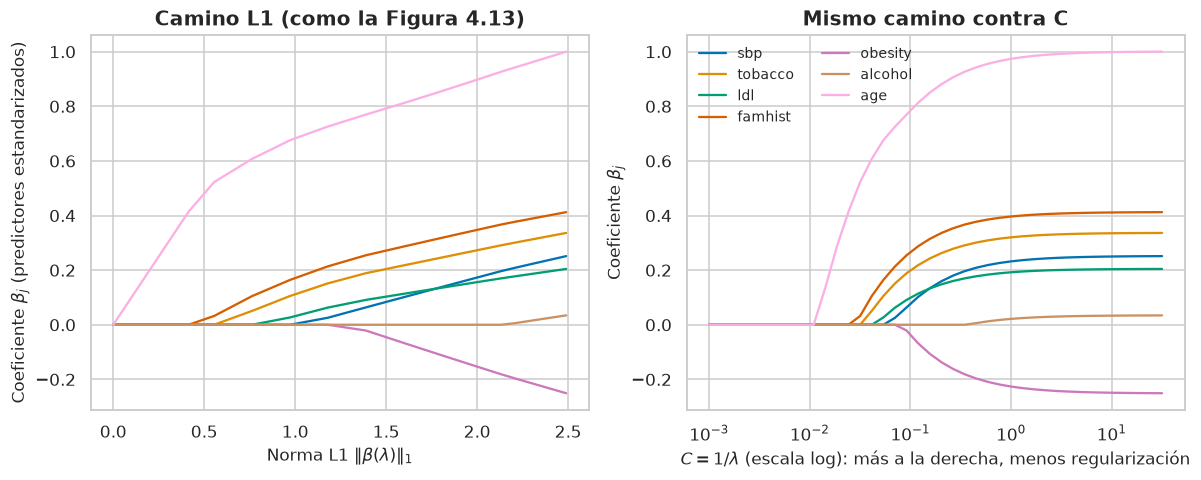

C a partir del cual cada variable se activa:
  age      C = 0.0143
  famhist  C = 0.0316
  tobacco  C = 0.0412
  ldl      C = 0.0538
  sbp      C = 0.0702
  obesity  C = 0.0915
  alcohol  C = 0.4507


In [30]:
from sklearn.preprocessing import StandardScaler

Z_log = StandardScaler().fit_transform(df_log[nombres_log])      # varianza unitaria, como en la Fig. 4.13
Cs_log = np.logspace(-3, 1.5, 40)
camino_log = np.array([
    LogisticRegression(l1_ratio=1, C=C, solver="liblinear", max_iter=1000).fit(Z_log, y_log).coef_.ravel()
    for C in Cs_log
])
l1_log = np.abs(camino_log).sum(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for j, nom in enumerate(nombres_log):
    axes[0].plot(l1_log, camino_log[:, j], label=nom)
    axes[1].plot(Cs_log, camino_log[:, j], label=nom)
axes[0].set_xlabel(r"Norma L1 $\|\beta(\lambda)\|_1$")
axes[0].set_ylabel(r"Coeficiente $\beta_j$ (predictores estandarizados)")
axes[0].set_title("Camino L1 (como la Figura 4.13)")
axes[1].set_xscale("log")
axes[1].set_xlabel(r"$C = 1/\lambda$ (escala log): más a la derecha, menos regularización")
axes[1].set_ylabel(r"Coeficiente $\beta_j$")
axes[1].set_title("Mismo camino contra C")
axes[1].legend(ncol=2, fontsize=9)
plt.tight_layout()
plt.show()

# Orden en que entran las variables al modelo al bajar la regularización
entrada_log = {nom: Cs_log[np.argmax(camino_log[:, j] != 0)] for j, nom in enumerate(nombres_log)}
print("C a partir del cual cada variable se activa:")
for nom, c in sorted(entrada_log.items(), key=lambda t: t[1]):
    print(f"  {nom:8s} C = {c:.4f}")

Mirá cómo, partiendo de la derecha (casi sin penalización, los coeficientes de la logística común), al bajar $C$ los coeficientes se encogen de a poco y los poco informativos (`alcohol`, `obesity`, `sbp`) llegan primero a cero, mientras `age`, `famhist` y `tobacco` son los últimos en irse (el `print` de la celda anterior da el orden exacto: `age`, `famhist` y `tobacco` se activan a los $C$ más chicos, o sea que son las últimas en irse, y `alcohol` es la última en activarse y la primera en irse). Es la misma historia que en el lasso de la clase 5.

##### ⚠️ Confusión típica

Creer que el libro y `sklearn` están parametrizados igual. En (4.31) $\lambda$ multiplica la penalidad; en `sklearn`, $C$ multiplica la **pérdida**. Son inversos: $\lambda$ grande $\leftrightarrow$ $C$ chico. Otro detalle: sin estandarizar, la penalidad L1 depende de las unidades, y el camino no tiene interpretación.

> 🔗 **Conexión con la clase 5**: en la clase 5 la trayectoria del lasso es lineal por tramos, y por eso LARS la calcula exacta de una. Acá cambia la pérdida y el camino pasa a ser suave por tramos, no lineal: LAR ya no sirve y hace falta `glmpath` o descenso por coordenadas. Y el eje $\|\beta(\lambda)\|_1$ de la Fig. 4.13 es el presupuesto $t$ de la forma con restricción de la §9 (cuando la restricción está activa, $\|\hat\beta\|_1=t$): $\lambda$ chico es $t$ grande, o sea la derecha del gráfico. El orden en que se apagan las variables se lee igual que allá: como un ranking.

> 🔗 **Conexión con las clases 4 y 5**: acá la trampa de la clase 5 tiene otra forma: `LogisticRegression` multiplica la pérdida por $C$ y suma la penalización, así que $\lambda_{ESL}=1/C$ sin factor $N$. Ni `alpha` de `Lasso` (costo $\tfrac1{2N}$, el $\lambda$ de la celda 15 de la clase 5) ni el $\lambda$ de (4.31) son intercambiables con $C$. Antes de pasar un número de una implementación a otra, escribí las dos funciones de costo una al lado de la otra.

#### 4.4.5 ¿Logística o LDA?

##### La idea en criollo

Las dos dan **logits lineales en $x$**. La diferencia no está en la forma del modelo sino en **cómo se estiman los coeficientes**, y por lo tanto en **qué supuestos** hacen falta. LDA es **generativo**: modela la densidad conjunta $\Pr(X,G)$ con gaussianas y deriva la posterior. La logística es **discriminativa**: modela solo $\Pr(G\mid X)$ y deja $\Pr(X)$ totalmente libre.

Una analogía: LDA es aprender a distinguir dos idiomas estudiando cómo suena cada uno (la gramática de cada lengua, por completo). La logística es aprender solo las pistas que los separan. Si tus supuestos sobre cómo suena cada idioma son correctos, el primero aprende con menos ejemplos. Dónde se rompe la analogía: un idioma tiene gramática que un estudiante puede aprender de a pedazos; LDA, en cambio, tiene que comprometerse con *una sola* forma gaussiana con covarianza común, sin "aprender un poco de cada cosa". Y la analogía sugiere que el discriminativo no mira la estructura de $X$, cuando en realidad usa $X$ en cada iteración: lo que no hace es modelarla. Lo que sí capta: si alguno de los idiomas tiene sonidos que tu modelo no contempla (datos no gaussianos, valores extremos), el enfoque generativo aprende cosas equivocadas sobre *cómo suena* y eso contamina la frontera, mientras el discriminativo no intenta modelar cómo suena.

##### Formalizándolo

De §4.3, los log-odds a posteriori entre la clase $k$ y la $K$ son lineales (4.9, 4.33):

$$\log\frac{\Pr(G=k\mid X=x)}{\Pr(G=K\mid X=x)}=\log\frac{\pi_k}{\pi_K}-\tfrac12(\mu_k+\mu_K)^T\Sigma^{-1}(\mu_k-\mu_K)+x^T\Sigma^{-1}(\mu_k-\mu_K)=\alpha_{k0}+\alpha_k^Tx.$$

Esta linealidad es **consecuencia** de suponer densidades de clase gaussianas con covarianza común $\Sigma$. La logística tiene logits lineales **por construcción** (4.34): $\beta_{k0}+\beta_k^Tx$. Parece el mismo modelo, y de hecho tiene la misma forma. La diferencia es cómo se ajusta.

Escribamos la densidad conjunta: $\Pr(X,G=k)=\Pr(X)\Pr(G=k\mid X)$ (4.35). Para ambos métodos el segundo factor tiene la forma logit-lineal de (4.36). Lo que cambia es qué se hace con $\Pr(X)$:

- **Logística:** maximiza la verosimilitud **condicional** (la multinomial con probabilidades $\Pr(G=k\mid X)$). $\Pr(X)$ queda como una densidad arbitraria, que se puede pensar como estimada de forma completamente no paramétrica por la distribución empírica (masa $1/N$ en cada observación).
- **LDA:** maximiza la verosimilitud **completa** basada en la conjunta (4.37) $\Pr(X,G=k)=\phi(X;\mu_k,\Sigma)\pi_k$, con $\phi$ la densidad gaussiana. Las estimaciones $\hat\mu_k,\hat\Sigma,\hat\pi_k$ son las de §4.3; como los parámetros lineales de (4.33) son funciones de los gaussianos, se obtienen por "plug-in". Acá la marginal de $X$ **sí importa**: es una **mezcla**

$$\Pr(X)=\sum_{k=1}^K\pi_k\,\phi(X;\mu_k,\Sigma)\qquad\text{(4.38)}$$

que depende de los mismos parámetros.

**¿Qué aporta ese componente extra?** Más información sobre los parámetros, entonces se estiman **más eficientemente** (menor varianza). Si las densidades verdaderas $f_k(x)$ son gaussianas, en el peor caso ignorar la marginal implica una pérdida de eficiencia de **alrededor de 30%** en la tasa de error, asintóticamente (Efron, 1975): con un 30% más de datos, la condicional rinde igual. Otras consecuencias que lista el libro:

- Las observaciones **lejos de la frontera** (que la logística desvaloriza vía los pesos $p(1-p)$) sí participan en la estimación de la covarianza común. No todas son buenas noticias: **LDA no es robusto a outliers groseros**.
- Con la formulación de mezcla, hasta las observaciones **sin etiqueta** aportan información sobre los parámetros. Etiquetar suele ser caro; observaciones sin clase, baratas. Con supuestos fuertes se pueden usar ambas.
- La verosimilitud marginal funciona como **regularizador**: pide que las densidades de clase "se vean" desde la marginal. Por ejemplo, si los datos de una logística de dos clases son **perfectamente separables** por un hiperplano, los estimadores de máxima verosimilitud **no están definidos** (son infinitos; ejercicio 4.5). Los coeficientes de LDA, en cambio, **sí quedan bien definidos** para los mismos datos.

En la práctica los supuestos nunca son correctos y a veces algunas componentes de $X$ son cualitativas. El libro opina que la logística es una apuesta **más segura y robusta** porque depende de menos supuestos, y agrega que, en su experiencia, los modelos dan resultados muy parecidos incluso cuando LDA se usa de forma inapropiada (p. ej. con predictores cualitativos).

##### ¿Por qué nos importa?

Porque es la versión concreta del dilema generativo–discriminativo: *más supuestos* = *menos varianza* si son ciertos, *más sesgo* si son falsos. Sirve para decidir con qué modelo empezar según lo que sepas de tus datos.

##### En código

Dos experimentos chicos. Primero, un simulador repetido (200 réplicas, $N=100$, $p=5$) con tres escenarios: datos gaussianos con covarianza común (los supuestos de LDA valen), predictores lognormales (asimétricos, no gaussianos) y gaussianos con 5% de outliers groseros en el entrenamiento. Segundo, datos perfectamente separables: coeficientes de la logística sin penalizar contra los de LDA.

Error de test medio (200 réplicas)
               LDA Logística
gaussiano  24.49 %   24.53 %
lognormal  27.82 %    26.7 %
outliers   36.96 %   31.66 %


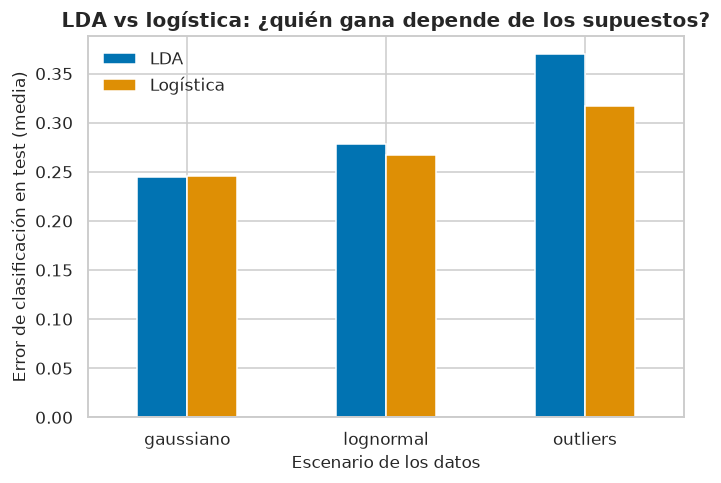

In [31]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

def generar_log(rng, n, escenario, p=5, dif=1.0):
    y = rng.binomial(1, 0.5, n)
    X = rng.normal(size=(n, p)) + dif * y[:, None] * np.array([1, .8, .6, .4, .2])  # medias distintas, cov = I
    if escenario == "lognormal":
        X = np.exp(X / 1.2)                     # asimétrica, NO gaussiana
    return X, y

def outliers_log(rng, X, y, frac=0.05):
    X, y = X.copy(), y.copy()
    k = rng.choice(len(y), int(frac * len(y)), replace=False)
    X[k] = X[k] + rng.normal(0, 1, (len(k), X.shape[1])) * 25 * (1 - 2 * y[k, None])   # muy lejos, del lado equivocado
    return X, y

resultados_log = {}
for esc in ["gaussiano", "lognormal", "outliers"]:
    errs = {"LDA": [], "Logística": []}
    for semilla in range(200):
        rng = np.random.default_rng(semilla)
        Xtr, ytr = generar_log(rng, 100, "lognormal" if esc == "lognormal" else "gaussiano")
        if esc == "outliers":
            Xtr, ytr = outliers_log(rng, Xtr, ytr)
        Xte, yte = generar_log(np.random.default_rng(10_000 + semilla), 4000, "lognormal" if esc == "lognormal" else "gaussiano")
        for nombre, modelo in [("LDA", LinearDiscriminantAnalysis()),
                               ("Logística", LogisticRegression(C=np.inf, max_iter=5000))]:
            errs[nombre].append(1 - modelo.fit(Xtr, ytr).score(Xte, yte))
    resultados_log[esc] = {k: np.mean(v) for k, v in errs.items()}

res_df_log = pd.DataFrame(resultados_log).T
print("Error de test medio (200 réplicas)")
print((100 * res_df_log).round(2).astype(str) + " %")

ax = res_df_log.plot.bar(rot=0)
ax.set_xlabel("Escenario de los datos")
ax.set_ylabel("Error de clasificación en test (media)")
ax.set_title("LDA vs logística: ¿quién gana depende de los supuestos?")
plt.show()

Leé el gráfico con las dos ideas del libro. Con datos gaussianos **empatan** (la ganancia de eficiencia de LDA que describe el libro existe, pero con estas diferencias entre medias y $N=100$ no se nota). Con lognormal, donde el supuesto de LDA no se cumple, la logística sale apenas mejor: nada dramático, en línea con lo que dice el libro sobre usar LDA de forma inapropiada. Con outliers groseros en el entrenamiento, LDA es la que más sufre (de 24,5 % a 37,0 %): la covarianza común estimada se infla porque todos los puntos, lejanos o no, entran en su cálculo (el libro lo advierte: LDA no es robusto a outliers groseros). La logística también empeora (de 24,5 % a 31,7 %), pero menos. Ojo con no sobreinterpretar el peso $p(1-p)$: es lo que hace que los puntos lejanos de la frontera pesen poco en cada paso de IRLS, pero un outlier del lado equivocado igual aporta $x_i(y_i-p_i)$ al score con $|y_i-p_i|\approx 1$. La logística es más robusta que LDA acá, no inmune.

Ahora el último punto del libro: datos separables.

In [32]:
rng_log = np.random.default_rng(3)
Xsep_log = np.r_[rng_log.normal(-2, 0.5, (20, 2)), rng_log.normal(2, 0.5, (20, 2))]
ysep_log = np.r_[np.zeros(20), np.ones(20)]
Xsep1_log = np.column_stack([np.ones(40), Xsep_log])

# Logística sin penalizar: los coeficientes crecen con cada iteración de Newton (no hay máximo finito)
beta_log = np.zeros(3)
for it in range(1, 16):
    p = 1 / (1 + np.exp(-np.clip(Xsep1_log @ beta_log, -30, 30)))
    w = np.clip(p * (1 - p), 1e-10, None)
    beta_log = beta_log + np.linalg.solve(Xsep1_log.T @ (w[:, None] * Xsep1_log), Xsep1_log.T @ (ysep_log - p))
    if it in (1, 3, 6, 10, 15):
        print(f"iteración {it:2d}: ||beta|| = {np.linalg.norm(beta_log):9.2f}")

lda_sep_log = LinearDiscriminantAnalysis().fit(Xsep_log, ysep_log)
print("\nLDA (finito y bien definido): coef =", lda_sep_log.coef_.round(2), " intercepto =", lda_sep_log.intercept_.round(2))

iteración  1: ||beta|| =      0.70
iteración  3: ||beta|| =      1.52
iteración  6: ||beta|| =      2.78
iteración 10: ||beta|| =      4.61
iteración 15: ||beta|| =      7.07

LDA (finito y bien definido): coef = [[14.76 14.38]]  intercepto = [1.38]


La norma de $\hat\beta$ de la logística crece sin parar (cada iteración de Newton lo agranda, porque siempre se puede mejorar un poco la verosimilitud empujando $\|\beta\|$ hacia el infinito), mientras que LDA da un número finito y estable. Es la idea del libro (traducida): la verosimilitud marginal no permite esas degeneraciones. Lo que sí se estabiliza en la logística es la *dirección* de $\hat\beta$, que apunta a un hiperplano separador; lo que no existe es el máximo de $\ell$ con $\hat\beta$ finito. Eso es lo que el libro resume en "la regresión logística siempre va a encontrar [un hiperplano separador], porque la log-verosimilitud se puede llevar a 0". En la práctica, `sklearn` evita el problema con su penalidad L2 por defecto, y `statsmodels` avisa cuando detecta separación perfecta.

##### ⚠️ Confusión típica

- Creer que "logística = no lineal y LDA = lineal". Las dos tienen frontera lineal.
- Creer que la logística es *siempre* mejor porque hace menos supuestos. Si los datos son realmente gaussianos con covarianza común y $N$ es chico, LDA puede ganar por varianza. Y si tenés muestras sin etiquetar, LDA puede sacarles provecho y la logística no.
- Pensar que "menos supuestos" significa "sin supuestos". La logística sigue asumiendo que el logit es **lineal en $x$** (bajo la forma de $x$ que elijas).

##### ❓ La pregunta que quedó abierta

Si LDA y la logística suelen dar resultados parecidos, ¿hay una tercera manera de elegir una frontera lineal, que no modele ni densidades ni probabilidades? Sí: elegirla por **geometría**, buscando directamente un hiperplano que separe las clases. Eso es §4.5, que sigue siendo lineal. Para abandonar de verdad la linealidad hay que agrandar el espacio de variables con funciones de base (📕 ESL cap. 5, que el propio libro anticipa al final de 4.4.2) o usar kernels (cap. 12).

> 🔗 **Conexión con la clase 4** (la idea es de la clase; aplicarla acá es extensión nuestra): la salida a la separabilidad es ridge. La log-verosimilitud no puede subir de 0, pero el peaje $\lambda\|\beta\|^2$ crece sin límite con $\|\beta\|$, así que el óptimo penalizado queda a distancia finita. Es el mismo argumento de la clase 4 ("la única forma de que el costo no explote es $\beta\to0$"): por eso el $C$ por defecto de `sklearn` es finito y la logística de `sklearn` tiene solución en estos datos. Con $C$ finito la norma de $\hat\beta$ es finita y crece muy despacio al subir $C$ (del orden de $\log C$), en vez de dispararse. La regularización deja de ser un refinamiento y pasa a ser lo que hace que el problema tenga solución, que es el mismo mensaje de la autoevaluación 7 de la clase 4 ($p>N$).

## 4.5 Hiperplanos separadores

📕 ESL §4.5 (con §4.5.1 y §4.5.2) · puente a 📕 ESL cap. 12 (SVM)

Hasta acá LDA y regresión logística estimaron fronteras lineales de formas parecidas pero distintas. Ahora cambiamos la pregunta. En vez de modelar densidades o probabilidades, buscamos **directamente una frontera lineal que separe las clases lo mejor posible**. ESL dice que el nivel matemático de esta sección es algo más alto que el de las anteriores, así que vamos despacio.

#### Geometría de un hiperplano

##### La idea en criollo

Un hiperplano es la generalización de una recta (en $\mathbb{R}^2$) o de un plano (en $\mathbb{R}^3$). Divide el espacio en dos lados. Clasificar con él es preguntar de qué lado cae cada punto.

Pensá en una red de tenis. La red es la frontera: un punto de la cancha cae de un lado o del otro, y además podés preguntar **a qué distancia de la red** está la pelota.

> **Dónde se rompe la analogía.** La red tiene una orientación fija y una altura fija. Un hiperplano en $\mathbb{R}^p$ se puede inclinar de $p-1$ maneras independientes (la dirección de su normal unitaria, que vive en una esfera de dimensión $p-1$), y además se puede correr de lugar: un grado más. Son $p$ números en total, aunque $(\beta,\beta_0)$ tenga $p+1$ componentes, porque multiplicarlos a todos por una constante no cambia el hiperplano. Y la "distancia con signo" no es un valor absoluto: el signo dice de qué lado estás, y eso es justo lo que usa el clasificador.

##### Formalizándolo

Un hiperplano (ESL lo llama también *conjunto afín* $L$) es el conjunto de puntos donde

$$f(x) = \beta_0 + \beta^T x = 0,$$

con $\beta$ el vector de coeficientes (leelo "beta": una dirección en el espacio de las variables) y $\beta_0$ el intercepto (un desplazamiento). Es la ecuación (4.39) de ESL. Tres propiedades, que ESL lista en §4.5:

**1. $\beta$ es perpendicular a $L$.** Tomá dos puntos $x_1, x_2$ que estén en $L$. Los dos cumplen $\beta_0 + \beta^T x_1 = 0$ y $\beta_0 + \beta^T x_2 = 0$. Restamos: $\beta^T(x_1 - x_2) = 0$. Como $x_1 - x_2$ es un vector que **yace dentro** de $L$ (cualquier dirección dentro del plano se obtiene así) y su producto con $\beta$ da cero, $\beta$ es ortogonal a todo el plano. El vector normal unitario es $\beta^* = \beta / \|\beta\|$ (la norma $\|\beta\|$ es la longitud de $\beta$).

**2. Para cualquier $x_0 \in L$, $\beta^T x_0 = -\beta_0$.** Sale directo de $f(x_0) = 0$.

**3. Distancia con signo.** Queremos la distancia de un punto cualquiera $x$ a $L$. Elegimos un $x_0 \in L$ y proyectamos el vector $x - x_0$ sobre la normal unitaria:

$$\beta^{*T}(x - x_0) = \frac{1}{\|\beta\|}\left(\beta^T x - \beta^T x_0\right) = \frac{1}{\|\beta\|}\left(\beta^T x + \beta_0\right) = \frac{f(x)}{\|\beta\|}.$$

En el segundo paso usamos la propiedad 2 ($-\beta^T x_0 = \beta_0$). Es la ecuación (4.40). Fijate que no depende de qué $x_0$ elegiste. Conclusión: **$f(x)$ es proporcional a la distancia con signo** de $x$ al hiperplano, y vale exactamente eso cuando $\|\beta\| = 1$.

**La figura de la clase (ESL Fig. 4.15).** El dibujo está en $\mathbb{R}^2$, donde el hiperplano $L$ es una recta. Fijate en tres elementos: un punto $x_0$ **sobre** la recta, el vector unitario $\beta^*$ saliendo de ella en perpendicular, y un punto $x$ cualquiera. La distancia con signo es la sombra del segmento $x_0\to x$ sobre $\beta^*$, y es lo que calcula la cuenta de arriba.

##### ¿Por qué nos importa?

Porque todo lo que sigue se escribe con esa cantidad. El perceptrón penaliza $-y_i f(x_i)$, y el margen máximo pide que $y_i f(x_i)/\|\beta\|$ sea grande para todos los puntos. Si no tenés clara la distancia con signo, el resto parece magia.

##### ⚠️ Confusión típica

Creer que $f(x)$ **es** la distancia. Lo es sólo si $\|\beta\| = 1$. Si multiplicás $\beta$ y $\beta_0$ por 10, el hiperplano es el mismo, pero $f(x)$ se multiplica por 10. Por eso, para comparar distancias, siempre hay que dividir por $\|\beta\|$.

> 🔗 **Conexión con la clase 1**: acá entramos a la **familia 3** del §7: el perceptrón y el hiperplano óptimo fusionan inferencia y decisión, devuelven $\operatorname{sign}\hat f(x)$ y no modelan ninguna probabilidad. Con eso heredan lo que la clase 1 decía que se pierde: no hay una medida de qué tan segura es la clasificación y no podés cambiar la matriz de pérdida sin reentrenar. El SVM que nombra la clase 1 es la versión con solapamiento de lo que sigue (cap. 12).

#### 4.5.1 El algoritmo del perceptrón de Rosenblatt

##### La idea en criollo

Partís de un hiperplano cualquiera. Mirás los puntos que quedaron del lado equivocado. Agarrás uno y **empujás el hiperplano hacia él**, lo justo para acercarlo a clasificarlo bien. Repetís hasta que no quede ningún error.

ESL cuenta que los clasificadores de este tipo (combinación lineal de las variables y se devuelve el signo) se llamaban *perceptrones* en la literatura de ingeniería de fines de los 50 (Rosenblatt, 1958), y que sentaron las bases de las redes neuronales de los 80 y 90.

##### Formalizándolo

Codificamos las clases como $y_i \in \{-1, +1\}$ (leelo: la etiqueta del punto $i$). Un punto está **bien clasificado** si $y_i f(x_i) > 0$, es decir, si el signo de $f$ coincide con la etiqueta. Si $y_i = +1$ y está mal clasificado, $x_i^T\beta + \beta_0 < 0$; y al revés para $y_i = -1$.

El perceptrón minimiza la **suma de las distancias (sin normalizar) de los mal clasificados a la frontera**:

$$D(\beta, \beta_0) = -\sum_{i \in \mathcal{M}} y_i\,(x_i^T\beta + \beta_0) \qquad (4.41)$$

donde $\mathcal{M}$ es el conjunto de índices de los puntos mal clasificados. Cada sumando es no negativo: para un mal clasificado $y_i f(x_i) < 0$, y el signo menos lo da vuelta. Es proporcional a la distancia de (4.40) (falta dividir por $\|\beta\|$). Si $\mathcal{M}$ es vacío, $D = 0$ y encontramos un hiperplano separador.

**Gradiente.** Suponiendo $\mathcal{M}$ fijo, $D$ es lineal en $(\beta, \beta_0)$, así que derivar es directo:

$$\frac{\partial D}{\partial \beta} = -\sum_{i \in \mathcal{M}} y_i x_i \quad (4.42), \qquad \frac{\partial D}{\partial \beta_0} = -\sum_{i \in \mathcal{M}} y_i \quad (4.43).$$

**Descenso por gradiente estocástico.** En lugar de sumar todas las contribuciones y dar un paso, se da un paso **después de visitar cada observación** mal clasificada. Moviéndose en la dirección opuesta al gradiente de ese único término:

$$\begin{pmatrix}\beta \\ \beta_0\end{pmatrix} \leftarrow \begin{pmatrix}\beta \\ \beta_0\end{pmatrix} + \rho \begin{pmatrix} y_i x_i \\ y_i \end{pmatrix} \qquad (4.44)$$

con $\rho$ la tasa de aprendizaje (el tamaño del paso). ESL aclara que puede tomarse $\rho = 1$ sin pérdida de generalidad. Si partís de $\beta = 0$, cambiar $\rho$ sólo reescala todo el vector por una constante y no cambia el hiperplano; con un arranque distinto de cero cambia el peso relativo del arranque.

**Convergencia.** Si las clases son **linealmente separables**, se puede probar que el algoritmo converge a un hiperplano separador en un número **finito** de pasos (ESL lo deja como Ejercicio 4.6; no lo demostramos acá). La idea de la prueba (la del Ejercicio 4.6 del libro): normalizá cada punto, $z_i=x_i^*/\|x_i^*\|$ con $x_i^*=(x_i,1)$. Sea $\beta_{sep}$ un separador escalado tal que $y_i\beta_{sep}^Tz_i\ge1$ para todo $i$. Cuando actualizás con un punto mal clasificado, $\beta_{new}=\beta_{old}+y_iz_i$, y $\|\beta_{new}-\beta_{sep}\|^2=\|\beta_{old}-\beta_{sep}\|^2+2y_iz_i^T(\beta_{old}-\beta_{sep})+1$. Como estaba mal clasificado, $y_iz_i^T\beta_{old}\le0$, y además $y_iz_i^T\beta_{sep}\ge1$, así que el término del medio es $\le-2$ y el total baja al menos 1. La distancia a $\beta_{sep}$ baja al menos 1 por actualización y nunca es negativa: hay una cantidad finita de actualizaciones. (Es el esqueleto, no la prueba completa.)

**Los tres problemas** (ESL los resume citando a Ripley, 1996):

- Si los datos son separables hay **muchas soluciones**, y cuál encontrás depende del arranque (y, en la práctica, del orden de visita).
- El número "finito" de pasos **puede ser enorme**: cuanto más chica la brecha entre las clases, más tarda.
- Si los datos **no son separables, no converge**: aparecen ciclos, que pueden ser largos y difíciles de detectar.

ESL agrega que el segundo problema suele aliviarse buscando el hiperplano en un espacio **agrandado** con muchas transformaciones de base de las variables originales. Es análogo a bajar los residuos a cero en una regresión polinómica subiendo el grado. Pero la separación perfecta no siempre es posible (por ejemplo, si dos observaciones de clases distintas tienen la misma entrada) y puede ni siquiera convenir: el modelo resultante probablemente sobreajuste.

##### ¿Por qué nos importa?

Porque muestra en miniatura el problema de fondo: "separar los datos" no define una única frontera. Y porque el perceptrón es el ancestro directo de las redes neuronales, que retoman la idea de actualizar parámetros observación por observación.

> 🔗 **Conexión con la clase 2**: la actualización del perceptrón tiene la misma forma que la del SGD del §6 de la clase 2, $\beta\leftarrow\beta+\eta\,e_i\,x_i$: un paso por observación, en la dirección de $x_i$ y escalado por un "error". La diferencia está en ese error: en cuadrados mínimos es el residuo $y_i-x_i^T\beta$ y se actualiza siempre; acá es solo $y_i$ y se actualiza **únicamente** cuando el punto está mal clasificado. La clase 2 ya decía que este esquema sostiene a las redes neuronales; acá aparece su antepasado directo.

##### En código

Implementamos el perceptrón a mano con `numpy`. Usamos las actualizaciones de (4.44) con $\rho = 1$. Guardamos el hiperplano al final de cada época (una pasada por los datos) y la cantidad de errores de esa época. Los datos son 20 puntos en $\mathbb{R}^2$, como la Figura 4.14 de ESL (pero generados por nosotros, no son los mismos).

**La figura de la clase (ESL Fig. 4.14).** Mirá tres rectas sobre los mismos 20 puntos separables. La **naranja** es la regresión lineal sobre la respuesta $\pm1$ (§4.2 con dos clases), y **comete un error** en entrenamiento, aunque existe un separador perfecto: minimiza un error cuadrático, no el número de errores. Según el libro es la misma frontera que encuentra LDA (por la equivalencia de §4.3, Ejercicio 4.2). Las dos **azules** son separadores del perceptrón con arranques aleatorios distintos: separan perfecto, pero son distintas entre sí. Esa figura junta los dos hechos: los métodos de las secciones anteriores pueden fallar con datos separables, y el perceptrón no tiene cómo elegir entre separadores.

errores por época: [3, 3, 1, 0]
errores finales sobre train: 0


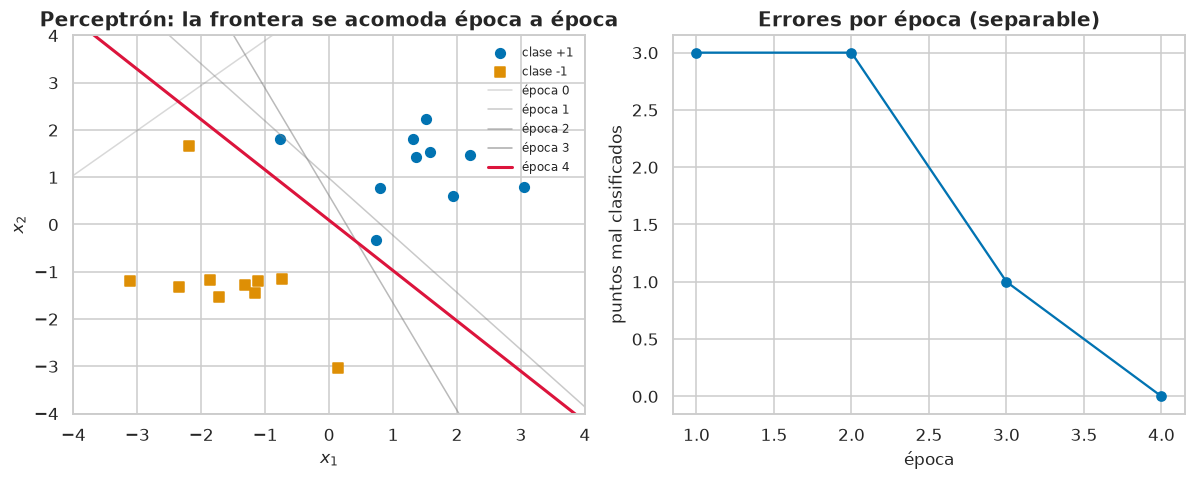

In [33]:
from sklearn.svm import SVC

def perceptron_hyp(X, y, semilla, max_epocas=100):
    # Arranque aleatorio y orden aleatorio de visita: las dos fuentes de no unicidad.
    rng = np.random.default_rng(semilla)
    w = rng.normal(size=X.shape[1])
    b = rng.normal()
    hist, errores = [(w.copy(), b)], []
    for _ in range(max_epocas):
        n_err = 0
        for i in rng.permutation(len(y)):
            if y[i] * (X[i] @ w + b) <= 0:      # mal clasificado: actualiza (4.44), rho = 1
                w, b = w + y[i] * X[i], b + y[i]
                n_err += 1
        errores.append(n_err)
        hist.append((w.copy(), b))
        if n_err == 0:                           # una época sin errores: separó todo
            break
    return w, b, hist, errores

# Datos separables: dos nubes bien distanciadas, 10 puntos por clase.
rng_hyp = np.random.default_rng(3)
X_hyp = np.vstack([rng_hyp.normal([-1.5, -1.0], 0.8, (10, 2)),
                   rng_hyp.normal([1.5, 1.0], 0.8, (10, 2))])
y_hyp = np.array([-1] * 10 + [1] * 10)

w_hyp, b_hyp, hist_hyp, err_hyp = perceptron_hyp(X_hyp, y_hyp, semilla=0)
print("errores por época:", err_hyp)
print("errores finales sobre train:", int(np.sum(y_hyp * (X_hyp @ w_hyp + b_hyp) <= 0)))

def dibujar_recta_hyp(ax, w, b, **kw):
    xs = np.array([-4.0, 4.0])
    if abs(w[1]) > 1e-9:
        ax.plot(xs, -(b + w[0] * xs) / w[1], **kw)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.scatter(*X_hyp[y_hyp == 1].T, label="clase +1", s=40)
ax.scatter(*X_hyp[y_hyp == -1].T, label="clase -1", s=40, marker="s")
pasos_hyp = np.unique(np.linspace(0, len(hist_hyp) - 1, 5).astype(int))
for k, idx in enumerate(pasos_hyp):
    ultimo = idx == pasos_hyp[-1]
    dibujar_recta_hyp(ax, *hist_hyp[idx], color="crimson" if ultimo else "gray",
                      alpha=1 if ultimo else 0.3 + 0.12 * k, lw=2 if ultimo else 1,
                      label=f"época {idx}")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Perceptrón: la frontera se acomoda época a época")
ax.legend(fontsize=8)
axes[1].plot(range(1, len(err_hyp) + 1), err_hyp, marker="o")
axes[1].set(xlabel="época", ylabel="puntos mal clasificados",
            title="Errores por época (separable)")
plt.tight_layout()
plt.show()

En el panel izquierdo las rectas grises son las fronteras a lo largo de las épocas (más oscuras a medida que avanzan) y la roja es la final. A la derecha, los errores por época bajan hasta cero: eso es el teorema de convergencia en acción. Con otras semillas puede subir entre épocas: una actualización que arregla un punto puede romper otros, y eso es normal, porque el algoritmo no minimiza la cantidad de errores sino $D$ paso a paso con un punto por vez.

Ahora los dos problemas que quedan: la **no unicidad** y la **no convergencia** cuando no hay separabilidad.

semilla 0: w = [4.32 4.05], b = -0.36, dirección = [0.73 0.68]
semilla 7: w = [2.22 1.22], b = 0.73, dirección = [0.88 0.48]


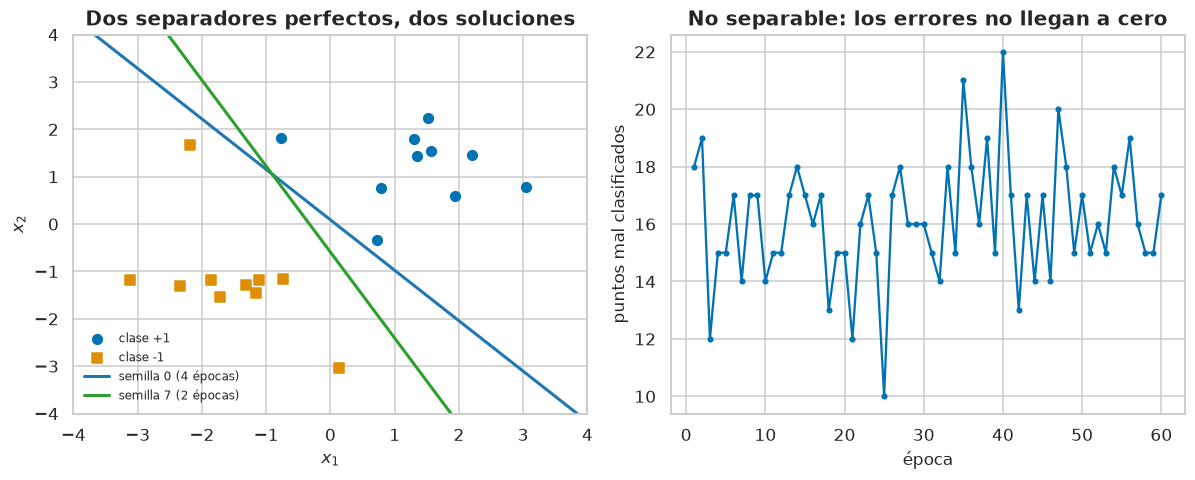

mínimo de errores en una época (no separable): 10 de 60


In [34]:
# (a) Mismos datos, distinta semilla (arranque y orden): dos hiperplanos separadores distintos.
corridas_hyp = [perceptron_hyp(X_hyp, y_hyp, semilla=s) for s in (0, 7)]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
ax = axes[0]
ax.scatter(*X_hyp[y_hyp == 1].T, s=40, label="clase +1")
ax.scatter(*X_hyp[y_hyp == -1].T, s=40, marker="s", label="clase -1")
for (w, b, _, e), col, s in zip(corridas_hyp, ("tab:blue", "tab:green"), (0, 7)):
    dibujar_recta_hyp(ax, w, b, color=col, lw=2, label=f"semilla {s} ({len(e)} épocas)")
    print(f"semilla {s}: w = {np.round(w, 2)}, b = {b:.2f}, dirección = {np.round(w / np.linalg.norm(w), 2)}")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Dos separadores perfectos, dos soluciones")
ax.legend(fontsize=8)

# (b) Datos que se solapan: no hay hiperplano separador, el perceptrón cicla.
rng2_hyp = np.random.default_rng(5)
Xn_hyp = np.vstack([rng2_hyp.normal([-0.7, -0.5], 1.0, (30, 2)),
                    rng2_hyp.normal([0.7, 0.5], 1.0, (30, 2))])
yn_hyp = np.array([-1] * 30 + [1] * 30)
_, _, _, err_n_hyp = perceptron_hyp(Xn_hyp, yn_hyp, semilla=0, max_epocas=60)
axes[1].plot(range(1, len(err_n_hyp) + 1), err_n_hyp, marker=".")
axes[1].set(xlabel="época", ylabel="puntos mal clasificados",
            title="No separable: los errores no llegan a cero")
plt.tight_layout()
plt.show()
print("mínimo de errores en una época (no separable):", min(err_n_hyp), "de", len(yn_hyp))

Arriba, las dos rectas clasifican **perfectamente** el conjunto de entrenamiento y sin embargo son distintas: es el primer problema, y es el de la Figura 4.14 de ESL, donde dos hiperplanos azules salen de arranques aleatorios distintos. ¿Cuál generaliza mejor? El perceptrón no tiene cómo decirlo. A la derecha, con clases que se solapan, el conteo de errores salta de una época a otra sin asentarse jamás: es el ciclo del que habla ESL. Sólo cortamos porque pusimos un tope de épocas.

##### ⚠️ Confusión típica

Pensar que "el perceptrón minimiza los errores de clasificación". Minimiza $D$, que pesa cada error por **qué tan lejos** quedó de la frontera. Y en el caso no separable ni siquiera converge a un mínimo de $D$ con este esquema de paso fijo: cicla. Que los errores bajen en promedio no garantiza nada época a época.

##### ❓ La pregunta que quedó abierta

Si hay infinitos separadores, ¿hay uno que merezca llamarse "el mejor"? ESL responde en la subsección siguiente: el que deja el **mayor margen** a ambos lados.

#### 4.5.2 El hiperplano separador óptimo

##### La idea en criollo

De todos los separadores, elegí el que queda **más lejos del punto más cercano de cada clase**. Es el que deja la calle más ancha entre las dos nubes. Se lo debemos a Vapnik (ESL cita Vapnik, 1996).

Pensá en tender una soga entre dos grupos de gente que no quieren mezclarse: no la tensás pegada a un grupo, la dejás lo más centrada posible.

> **Dónde se rompe la analogía.** Con la soga, vos elegís a ojo. Acá hay un problema de optimización bien definido, y la "calle" puede estar inclinada en un espacio de muchas dimensiones donde no hay ojo que valga. Y además la calle depende sólo de unos pocos puntos de los bordes, no de "los grupos" en conjunto.

ESL argumenta que esto no sólo da una solución única, sino que, al maximizar el margen en los datos de entrenamiento, suele dar **mejor clasificación en test**. Es una intuición, no un teorema.

##### Formalizándolo

Generalizamos el criterio (4.41) con este problema:

$$\max_{\beta, \beta_0, \|\beta\| = 1} M \quad \text{sujeto a} \quad y_i(x_i^T\beta + \beta_0) \geq M, \quad i = 1, \dots, N \qquad (4.45)$$

Con $\|\beta\| = 1$, $y_i f(x_i)$ es la distancia con signo (por (4.40)). Entonces las restricciones dicen: todos los puntos están al menos a distancia $M$ (el **margen**) de la frontera, del lado correcto. Buscamos el mayor $M$ posible.

**Sacarse de encima $\|\beta\| = 1$.** Esa restricción no es cómoda. La reemplazamos dividiendo por la norma:

$$\frac{1}{\|\beta\|}y_i(x_i^T\beta + \beta_0) \geq M \quad (4.46) \;\Longleftrightarrow\; y_i(x_i^T\beta + \beta_0) \geq M\|\beta\| \quad (4.47)$$

(ESL aclara que esto redefine $\beta_0$, por el reescalado.) Ahora notá que si $(\beta, \beta_0)$ cumple estas desigualdades, **cualquier múltiplo positivo** también: ambos lados escalan igual. Hay un grado de libertad de sobra, y lo fijamos arbitrariamente con $\|\beta\| = 1/M$. Sustituyendo, $M\|\beta\| = 1$ y queda:

$$\min_{\beta, \beta_0} \tfrac{1}{2}\|\beta\|^2 \quad \text{sujeto a} \quad y_i(x_i^T\beta + \beta_0) \geq 1, \quad i = 1, \dots, N \qquad (4.48)$$

Maximizar $M = 1/\|\beta\|$ es lo mismo que minimizar $\|\beta\|$, y minimizar $\tfrac12\|\beta\|^2$ es equivalente y más cómodo de derivar (el $\tfrac12$ simplifica el 2 de la derivada). Por (4.40), las restricciones definen una **franja vacía** (*slab*) alrededor de la frontera, de espesor $1/\|\beta\|$ de cada lado (el ancho total es $2/\|\beta\|=2M$). Es un problema **convexo**: criterio cuadrático con restricciones lineales de desigualdad.

**Lagrangiano.** Para cada restricción $y_i(x_i^T\beta + \beta_0) - 1 \geq 0$ introducimos un multiplicador $\alpha_i \geq 0$ (leelo "alfa i": cuánto "pesa" esa restricción). La función de Lagrange (primal) a minimizar respecto de $\beta$ y $\beta_0$ es:

$$L_P = \tfrac12\|\beta\|^2 - \sum_{i=1}^N \alpha_i\left[y_i(x_i^T\beta + \beta_0) - 1\right] \qquad (4.49)$$

Derivamos e igualamos a cero. Respecto de $\beta$: $\beta - \sum_i \alpha_i y_i x_i = 0$. Respecto de $\beta_0$: $-\sum_i \alpha_i y_i = 0$. Es decir:

$$\beta = \sum_{i=1}^N \alpha_i y_i x_i \quad (4.50), \qquad 0 = \sum_{i=1}^N \alpha_i y_i \quad (4.51).$$

Reemplazando en (4.49) se obtiene el llamado **dual de Wolfe**:

$$L_D = \sum_{i=1}^N \alpha_i - \tfrac12 \sum_{i=1}^N\sum_{k=1}^N \alpha_i\alpha_k y_i y_k x_i^T x_k \quad \text{sujeto a } \alpha_i \geq 0,\ \sum_i \alpha_i y_i = 0 \qquad (4.52)$$

Hagamos la sustitución. Abrimos (4.49): $L_P=\tfrac12\|\beta\|^2-\sum_i\alpha_iy_ix_i^T\beta-\beta_0\sum_i\alpha_iy_i+\sum_i\alpha_i$. Por (4.51) el término con $\beta_0$ vale cero. Por (4.50), $\sum_i\alpha_iy_ix_i^T\beta=\beta^T\beta=\|\beta\|^2$. Queda $L_P=\sum_i\alpha_i-\tfrac12\|\beta\|^2$, y escribiendo $\|\beta\|^2=\sum_i\sum_k\alpha_i\alpha_ky_iy_kx_i^Tx_k$ (otra vez por (4.50), dos veces) sale exactamente (4.52). Fijate que $\beta$ y $\beta_0$ desaparecieron: el dual sólo depende de los $\alpha_i$.

Se maximiza en el ortante positivo: un problema convexo más simple, para el que hay software estándar. Fijate que los datos entran sólo a través de **productos internos** $x_i^T x_k$. Esa observación es la puerta al capítulo 12.

**Condiciones de Karush–Kuhn–Tucker (KKT).** La solución tiene que cumplir, además de (4.50), (4.51) y (4.52), la condición de **holgura complementaria**:

$$\alpha_i\left[y_i(x_i^T\beta + \beta_0) - 1\right] = 0 \quad \forall i \qquad (4.53)$$

Por qué aparece (4.53): cada restricción $y_i(x_i^T\beta+\beta_0)-1\ge0$ tiene su multiplicador $\alpha_i\ge0$. Si la restricción está **floja** (el punto está estrictamente adentro), moverla no cambia el óptimo, así que su multiplicador tiene que ser cero. Si $\alpha_i>0$, la restricción está **activa**: se cumple con igualdad. Además de (4.50), (4.51) y (4.53), KKT exige $\alpha_i\ge0$ (parte de (4.52)) y que las restricciones originales se cumplan.

Un producto que da cero significa que uno de los dos factores es cero:

- si $\alpha_i > 0$, entonces $y_i(x_i^T\beta + \beta_0) = 1$: el punto está **justo sobre el borde de la franja**;
- si $y_i(x_i^T\beta + \beta_0) > 1$, el punto está adentro de su zona y $\alpha_i = 0$.

Por (4.50), $\beta$ es una **combinación lineal de los puntos soporte** (los $x_i$ con $\alpha_i > 0$). El resto de los puntos no influye. Y $\beta_0$ se obtiene resolviendo (4.53) para cualquier punto soporte. Finalmente se clasifica con

$$\hat G(x) = \operatorname{sign}\hat f(x), \quad \hat f(x) = x^T\hat\beta + \hat\beta_0 \qquad (4.54)$$

Ningún punto de entrenamiento cae dentro de la franja (por construcción), pero los de test sí pueden caer adentro.

##### ¿Por qué nos importa?

Resuelve el problema de unicidad del perceptrón, y cambia la mirada sobre qué datos importan. ESL contrasta: la solución del hiperplano se define con los puntos soporte y en ese sentido "se concentra en los puntos que cuentan". LDA, en cambio, depende de **todos** los datos, incluso los lejanos a la frontera. ESL advierte dos cosas: identificar los puntos soporte requirió usar todos los datos, y si las clases son realmente gaussianas, LDA es óptimo y el hiperplano separador paga el precio de fijarse en los datos de borde, que son los más ruidosos.

Sobre la relación con la logística: cuando existe un hiperplano separador, la regresión logística siempre lo encuentra, porque la log-verosimilitud puede llevarse a 0 (ESL Ejercicio 4.5). En el ejemplo de ESL (Figura 4.16) ambas soluciones son muy parecidas. Además, la logística comparte un rasgo cualitativo: sus pesos son mayores para los puntos cerca de la frontera que para los lejanos. Cuando **no** hay separabilidad, el problema (4.48) no tiene solución factible; ESL propone el *support vector machine* del capítulo 12, que permite solapamiento y minimiza una medida de cuánto se solapa.

> 🔗 **Conexión con las clases 3, 4 y 5**: fijate que los roles de la clase 5 (§9) se dieron vuelta. Ridge minimiza el error con $\|\beta\|^2\le t$ o con el peaje $\lambda\|\beta\|^2$; acá el objetivo es $\tfrac12\|\beta\|^2$ y lo que funciona como restricción es el ajuste ($y_if(x_i)\ge1$ para todos los puntos). Es la misma herramienta, los multiplicadores de Lagrange (que la clase 5 da por vistos), pero con un $\alpha_i$ por cada restricción en lugar de un único $\lambda$ o $t$. Minimizar $\|\beta\|$ y maximizar el margen $M=1/\|\beta\|$ es lo mismo. Hay además un parecido de fondo, y lo marco como analogía y no como igualdad, con la pseudoinversa de la clase 3 (§6): allá, con infinitas soluciones de mínimos cuadrados, se elegía la de $\|\hat\beta\|$ mínima; acá, entre los infinitos separadores, (4.48) elige el de $\|\beta\|$ mínimo con margen 1. Los conjuntos de soluciones son distintos, y acá la unicidad sale de pedir margen.

> 🔗 **Conexión con la clase 5**: hay un parecido y una diferencia con el lasso. Parecido: en los dos casos el óptimo es disperso por una condición de optimalidad que deja cosas "inactivas" (la holgura complementaria de acá, los subgradientes de la clase 5: $\beta_j=0$ cuando $|a|\le\lambda$). Diferencia: el lasso apaga **variables** (columnas de $\mathbf{X}$), el hiperplano óptimo apaga **observaciones** ($\alpha_i=0$ para los puntos que no tocan el borde). Por eso $\beta=\sum_i\alpha_iy_ix_i$ sólo depende de los puntos soporte.

##### En código

Primero resolvemos a mano el dual (4.52) con `scipy.optimize.minimize`: es un problema cuadrático con $\alpha_i \ge 0$ y una restricción lineal, $\sum_i\alpha_iy_i=0$. De ahí sacamos $\beta$ con (4.50) y $\beta_0$ despejando (4.53) en un punto soporte (el de mayor $\alpha_i$). Después lo comparamos con la versión de librería.

In [35]:
from scipy.optimize import minimize

# Dual (4.52): maximizar sum(alpha) - 1/2 alpha' Q alpha, con Q_ik = y_i y_k x_i.x_k, alpha >= 0 y sum(alpha_i y_i) = 0.
Q_dual = (y_hyp[:, None] * X_hyp) @ (y_hyp[:, None] * X_hyp).T
res_dual = minimize(lambda a: 0.5 * a @ Q_dual @ a - a.sum(), np.zeros(len(y_hyp)),
                    jac=lambda a: Q_dual @ a - 1, bounds=[(0, None)] * len(y_hyp),
                    constraints={"type": "eq", "fun": lambda a: a @ y_hyp}, method="SLSQP")
alpha_dual = res_dual.x
beta_dual = (alpha_dual * y_hyp) @ X_hyp                  # (4.50)
s_dual = np.argmax(alpha_dual)                            # un punto soporte
beta0_dual = y_hyp[s_dual] - X_hyp[s_dual] @ beta_dual    # despejar (4.53) en un soporte (y_i = +-1)
print("converge:", res_dual.success)
print("soportes (alpha > 1e-6):", np.where(alpha_dual > 1e-6)[0])
print("beta:", beta_dual.round(3), "| beta0:", round(beta0_dual, 3))
print("(4.51) sum alpha_i y_i =", round(alpha_dual @ y_hyp, 8))

converge: True
soportes (alpha > 1e-6): [ 4  9 18]
beta: [1.324 0.684] | beta0: 0.766
(4.51) sum alpha_i y_i = -0.0


##### 🏭 Así se hace en la industria

Resolvemos el problema (4.48) con `sklearn.svm.SVC(kernel="linear", C=1e10)`. Con $C$ enorme el solver no tolera ninguna violación del margen, y eso reproduce el problema de margen duro de esta sección (el parámetro $C$ recién cobra sentido en el capítulo 12). Después **verificamos a mano** las propiedades que derivamos: los puntos soporte están a distancia $1/\|\beta\|$, vale (4.50) y (4.51), y $\alpha_i > 0$ sólo en los soportes. Y comparamos con el dual que acabamos de resolver.

In [36]:
svm_hyp = SVC(kernel="linear", C=1e10).fit(X_hyp, y_hyp)
beta_hyp = svm_hyp.coef_[0]
beta0_hyp = svm_hyp.intercept_[0]
norma_hyp = np.linalg.norm(beta_hyp)
f_hyp = X_hyp @ beta_hyp + beta0_hyp                  # f(x) = x^T beta + beta_0
sop_hyp = svm_hyp.support_                            # índices de los puntos soporte

# sklearn guarda alpha_i * y_i para los soportes (dual_coef_).
ay_hyp = svm_hyp.dual_coef_[0]
print("puntos soporte (índices):", sop_hyp)
print("margen 1/||beta||:", round(1 / norma_hyp, 4))
print("y_i f(x_i) en soportes (debe ser 1):", np.round(y_hyp[sop_hyp] * f_hyp[sop_hyp], 4))
print("distancia con signo de soportes (debe ser 1/||beta||):",
      np.round(y_hyp[sop_hyp] * f_hyp[sop_hyp] / norma_hyp, 4))
no_sop_hyp = np.setdiff1d(np.arange(len(y_hyp)), sop_hyp)
print("y_i f(x_i) mínimo entre no soportes (debe ser > 1):",
      round((y_hyp[no_sop_hyp] * f_hyp[no_sop_hyp]).min(), 4))
print("KKT (4.50): beta == sum alpha_i y_i x_i ->",
      np.allclose(beta_hyp, ay_hyp @ X_hyp[sop_hyp]))
print("KKT (4.51): sum alpha_i y_i == 0        ->", np.isclose(ay_hyp.sum(), 0, atol=1e-6))
print("alpha_i >= 0 (alpha_i y_i con el signo de y_i) ->",
      bool(np.all(ay_hyp * y_hyp[sop_hyp] > 0)))
print("dual a mano == SVC: beta", np.allclose(beta_dual, beta_hyp, atol=1e-2),
      "| beta0", np.isclose(beta0_dual, beta0_hyp, atol=1e-2),
      "| mismos soportes", set(np.where(alpha_dual > 1e-6)[0]) == set(sop_hyp))

puntos soporte (índices): [ 4  9 18]
margen 1/||beta||: 0.6713
y_i f(x_i) en soportes (debe ser 1): [0.9999 1.0003 1.0001]
distancia con signo de soportes (debe ser 1/||beta||): [0.6712 0.6715 0.6714]
y_i f(x_i) mínimo entre no soportes (debe ser > 1): 1.1444
KKT (4.50): beta == sum alpha_i y_i x_i -> True
KKT (4.51): sum alpha_i y_i == 0        -> True
alpha_i >= 0 (alpha_i y_i con el signo de y_i) -> True
dual a mano == SVC: beta True | beta0 True | mismos soportes True


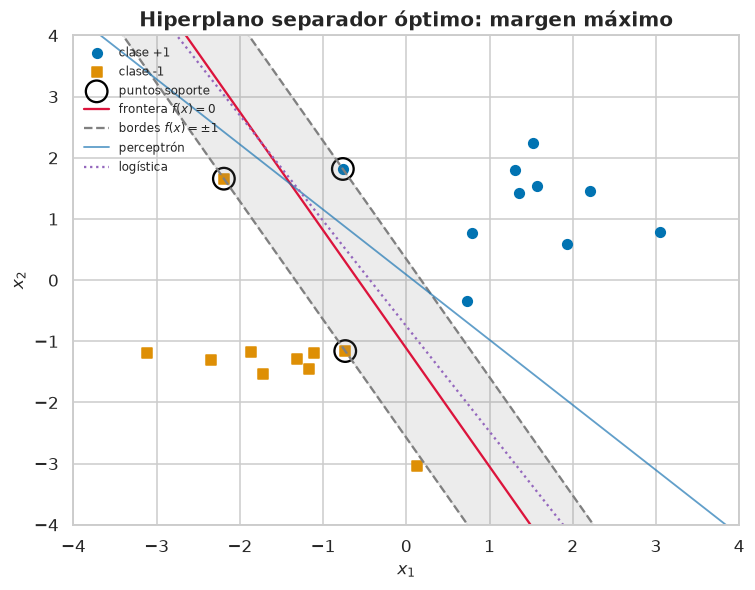

perceptrón s=0   margen = 0.2439
perceptrón s=7   margen = 0.4951
óptimo (SVC)     margen = 0.6712
logística        margen = 0.6301


In [37]:
fig, ax = plt.subplots(figsize=(7, 5.5))
ax.scatter(*X_hyp[y_hyp == 1].T, s=40, label="clase +1")
ax.scatter(*X_hyp[y_hyp == -1].T, s=40, marker="s", label="clase -1")
ax.scatter(*X_hyp[sop_hyp].T, s=200, facecolors="none", edgecolors="black",
           linewidths=1.5, label="puntos soporte")
xs = np.array([-4.0, 4.0])
for nivel, estilo, etiqueta in ((0, "-", "frontera $f(x)=0$"),
                                (1, "--", "bordes $f(x)=\\pm 1$"), (-1, "--", None)):
    ax.plot(xs, -(beta0_hyp - nivel + beta_hyp[0] * xs) / beta_hyp[1],
            color="crimson" if nivel == 0 else "gray", ls=estilo, label=etiqueta)
ax.fill_between(xs, -(beta0_hyp - 1 + beta_hyp[0] * xs) / beta_hyp[1],
                -(beta0_hyp + 1 + beta_hyp[0] * xs) / beta_hyp[1], color="gray", alpha=0.15)
# Para comparar: uno de los separadores del perceptrón.
dibujar_recta_hyp(ax, *corridas_hyp[0][:2], color="tab:blue", lw=1.2, alpha=0.7, label="perceptrón")
# Logística sin penalizar (C enorme): converge hacia un separador; su dirección se estabiliza aunque ||beta|| crece.
lr_hyp = LogisticRegression(C=1e10, max_iter=10000).fit(X_hyp, y_hyp)
b_lr, b0_lr = lr_hyp.coef_[0], lr_hyp.intercept_[0]
dibujar_recta_hyp(ax, b_lr, b0_lr, color="tab:purple", lw=1.5, ls=":", label="logística")
ax.set(xlim=(-4, 4), ylim=(-4, 4), xlabel="$x_1$", ylabel="$x_2$",
       title="Hiperplano separador óptimo: margen máximo")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

# Margen mínimo (distancia al punto más cercano) del perceptrón vs. el óptimo.
for nombre, (w, b) in (("perceptrón s=0", corridas_hyp[0][:2]), ("perceptrón s=7", corridas_hyp[1][:2]),
                       ("óptimo (SVC)", (beta_hyp, beta0_hyp)),
                       ("logística", (b_lr, b0_lr))):
    print(f"{nombre:16s} margen = {(y_hyp * (X_hyp @ w + b) / np.linalg.norm(w)).min():.4f}")

En el gráfico, los puntos con círculo negro son los soportes: caen sobre las rectas punteadas ($f = \pm 1$), salvo la tolerancia numérica del solver (por eso el `print` da 0.9999 y 1.0003 y no 1 justo), y la frontera roja pasa por la mitad de la franja gris. Fijate cómo los demás puntos no tocan la franja: si los movés un poco sin cruzar el borde, el hiperplano no cambia. En el último `print`, el margen del hiperplano óptimo es el mayor, y los dos del perceptrón quedan por debajo: separan bien, pero sin ninguna garantía de holgura.

Dato para cruzar con el libro: el ejemplo de ESL (Fig. 4.16) también tiene **tres** puntos soporte, y su recta de logística queda muy cerca de la del margen óptimo. Acá pasa algo parecido: la recta punteada violeta es la logística sin penalizar, y queda cerca de la del margen óptimo (no idéntica: el `print` de arriba da su margen, algo menor). La razón, según el libro, es que la logística pondera más a los puntos cerca de la frontera que a los lejanos, así que "se fija" en casi los mismos puntos que el margen máximo.

##### ⚠️ Confusión típica

Creer que los $\alpha_i$ o los puntos soporte se pueden conocer **antes** de resolver. ESL lo señala: identificar los soportes requirió usar todos los datos. Los soportes son un resultado del problema, no un filtro previo. Otro error frecuente: suponer que $\|\beta\| = 1/M$ es una condición del problema. Es una elección arbitraria de escala, permitida porque los múltiplos positivos de $(\beta, \beta_0)$ definen el mismo hiperplano.

##### ❓ La pregunta que quedó abierta

Cuando los datos no son separables, (4.48) no tiene solución factible. ¿Qué hacemos? Ampliar el espacio con bases puede provocar separación artificial por sobreajuste (ESL lo advierte). La salida que propone el libro es el *support vector machine* del 📕 ESL cap. 12, que tolera solapamiento pero penaliza cuánto se solapa. Es ahí donde el parámetro $C$ que dejamos "infinito" en el código adquiere sentido.

### 🌉 Puente con el resto del capítulo

LDA, regresión logística e hiperplanos separadores terminan en la **misma forma de frontera**, $\hat G(x) = \operatorname{sign}(\beta_0 + \beta^T x)$, y difieren en **cómo eligen $\beta$**: LDA usa todos los datos asumiendo gaussianas con covarianza común (y en dos clases tiene los mismos coeficientes, salvo un factor de escala, que la regresión lineal sobre $\pm 1$; la frontera coincide del todo si las dos clases tienen igual cantidad de observaciones, y en la Figura 4.14 de ESL esa recta, que es también la de LDA, comete un error aun con datos separables); la logística maximiza una verosimilitud y, si hay separabilidad, la encuentra; el perceptrón se conforma con cualquier separador; y el hiperplano óptimo elige el de mayor margen, apoyándose sólo en los puntos soporte. Cuando los datos son separables, logística e hiperplano óptimo dan fronteras muy parecidas (Figura 4.16 de ESL). Cuando no lo son, el camino sigue en el 📕 ESL cap. 12.

## 🔗 Conexiones con las clases previas

**Clase 1, teoría de la decisión.** Todo el capítulo es la teoría de la decisión con los modelos puestos. La regla de Bayes $\hat G(x)=\arg\max_k\Pr(G=k\mid x)$ (pérdida 0-1) es la que LDA implementa con $\delta_k$ y la que la logística usa con su posterior; el error de Bayes es el techo contra el que se miden las fronteras estimadas; y cuando los errores no cuestan igual, el umbral de 0,5 se mueve con la matriz de pérdida del §6. Los tres bloques del capítulo son las tres familias del §7: LDA/QDA generativos, logística discriminativa, hiperplanos como funciones discriminantes. §4.3 cumple además el "Ejemplo 3" que la clase dejó pendiente, y la regresión sobre indicadoras es la media condicional del §8 aplicada a $Y_k\in\{0,1\}$.

**Clase 2, regresión lineal.** La regresión sobre indicadoras es la ecuación normal con $\mathbf{y}\to\mathbf{Y}$, o sea $\hat{\mathbf{Y}}=\mathbf{H}\mathbf{Y}$ con la matriz sombrero de la clase, y "lineal en los parámetros" es lo que permite ampliar la base y curvar las fronteras. En la logística se pierde la solución cerrada que la clase anticipaba, pero sobreviven el argumento de curvatura, el IRLS (mínimos cuadrados ponderados resueltos con `solve`), los Z-scores y la comparación de modelos anidados, ahora asintóticos. El perceptrón es un SGD con la forma del de la clase, con otro "error".

**Clase 3, máxima verosimilitud y SVD.** La logística se ajusta con la receta de la clase (producto, log, suma) cambiando el error normal por una Bernoulli, y LDA es máxima verosimilitud sobre la conjunta, con el mismo dilema $N$ contra $N-K$ que $N$ contra $N-p-1$. El esferizado repite la álgebra $VD^2V^T$ (con $U$ y $V$ cruzadas de nombre), y `solver="svd"` evita armar la covarianza por la misma razón que `lstsq` evita $\mathbf{X}^T\mathbf{X}$. Multicolinealidad y rango deficiente reaparecen como covarianza singular ($N<p$) y como coeficientes que cambian de signo en el ejemplo coronario.

**Clases 4 y 5, ridge y lasso.** La regularización es la tercera parada de esas clases, ahora en clasificación. El $\lambda I$ de ridge reaparece como $\hat\Sigma+\lambda I$ en RDA ($\alpha$ y $\gamma$, §4.3.1), y el mecanismo de fondo es el mismo: un autovalor o valor singular chico se amplifica al invertir ($\mathrm{Var}(\hat\beta)=\sigma^2VD^{-2}V^T$ allá, $D^{-1/2}$ en el esferizado de §4.3.2) y sumarle algo a la diagonal lo controla. La distinción "truncar o encoger" (PCR contra ridge) se ve en LDA de rango reducido (corta) contra RDA (encoge). El lasso de la clase 5 es §4.4.4: misma penalización $L_1$ con la log-verosimilitud en lugar del $RSS$, mismas convenciones ($\beta_0$ sin penalizar, predictores estandarizados, cuidado con $C=1/\lambda$ contra el `alpha` de $\tfrac1{2N}$), y *soft-thresholding* y coordinate descent son el motor del "lasso ponderado" de cada paso de IRLS. Las dos clases comparten con el capítulo la misma deuda: el compromiso sesgo-varianza y la elección del hiperparámetro por validación cruzada, que acá se usan para explicar por qué LDA anda bien y para elegir $\alpha$, $L$ y $C$. Y la geometría de la clase 5 (forma con restricción contra forma lagrangiana) tiene su contraparte en el margen máximo de §4.5.2: allá se minimiza el error con $\|\beta\|$ acotada, acá se minimiza $\|\beta\|$ con el ajuste como restricción, y en vez de variables se apagan observaciones (puntos soporte).

## 🧵 El hilo conductor

Todo el capítulo responde una pregunta: ¿cómo trazamos fronteras lineales entre clases? Hay dos caminos. El **generativo** modela cómo se generan los $X$ dentro de cada clase y aplica Bayes (LDA, QDA, RDA, §4.3). El **discriminativo** modela directamente el posterior $\Pr(G\mid X)$ (logística, §4.4) o directamente la frontera, sin probabilidades (perceptrón e hiperplano óptimo, §4.5).

La regresión sobre indicadoras (§4.2) es el punto de partida ingenuo, y su falla (*masking*) motiva todo lo demás. LDA y logística producen la misma forma de frontera, log-odds lineales (§4.1), pero difieren en cómo estiman los coeficientes y en qué supuestos hacen. Los hiperplanos separadores abandonan el modelo probabilístico y piden geometría: separar con el mayor margen. La regresión logística, además, sirve para entender qué variable aporta qué (Z-scores, odds ratios, deviance: §4.4.2–4.4.3), no sólo para clasificar. Y en dos clases, la regresión sobre $\pm1$ de §4.2 y LDA de §4.3 comparten coeficientes (salvo escala): es lo que muestra la Figura 4.14.

Venimos del capítulo 3 (regresión lineal y regularización): acá reaparecen el shrinkage (RDA, L1) y los mínimos cuadrados (IRLS). Seguimos hacia el capítulo 5 (expansiones de base) y el cap. 12 (SVM), que llevan estas fronteras a espacios no lineales.

## ✅ Autoevaluación

De menor a mayor dificultad. Son 10 preguntas; las 3, 6 y 10 piden hacer la cuenta, y la 7 y la 9 son del tipo "¿qué pasa si...?". Intentá antes de abrir cada respuesta.

**1.** ¿Por qué la regresión sobre indicadoras puede fallar con $K\ge3$ aunque las clases sean separables linealmente?

<details><summary>Respuesta</summary>

Por *masking*: con $K=3$ y una clase en el medio, su ajuste lineal $\hat f_k$ es una recta que queda por debajo de la de alguna de las otras dos en todo el rango, así que nunca es la mayor y esa clase no se predice jamás. Las clases *sí* son separables linealmente, pero la regresión lineal sobre indicadoras no minimiza errores de clasificación, minimiza cuadrados. Se arregla agregando términos de grado mayor (el libro indica que grado $K-1$ puede hacer falta en el peor caso), o usando LDA o logística.

</details>

**2.** ¿Qué supuesto hace que las fronteras de LDA sean lineales? ¿Y qué le pasa a la frontera si lo relajás de a poco con el parámetro $\alpha$ de RDA?

<details><summary>Respuesta</summary>

Densidades gaussianas por clase con **la misma** matriz de covarianza $\Sigma$: al comparar $\log\Pr(G=k\mid x)$ entre dos clases, el término cuadrático $x^T\Sigma^{-1}x$ se cancela y queda una función lineal. RDA interpola, $\hat\Sigma_k(\alpha)=\alpha\hat\Sigma_k+(1-\alpha)\hat\Sigma$: con $\alpha=0$ es LDA (frontera lineal), con $\alpha=1$ es QDA (cuadrática), y en el medio la frontera se va curvando de a poco. $\alpha$ se elige por validación.

</details>

**3.** Con $p=10$ predictores y $K=3$ clases, contá los parámetros de LDA y de QDA.

<details><summary>Respuesta</summary>

LDA: medias $K p=30$, $\Sigma$ común $p(p+1)/2=55$, priors $K-1=2$, en total 87. QDA: medias 30, una $\Sigma_k$ por clase $3\cdot55=165$, priors 2, en total 197. Ojo: si contás sólo lo que determina la frontera (las diferencias $\delta_k-\delta_K$, como hace ESL) son $(K-1)(p+1)=22$ para LDA y $(K-1)\{p(p+3)/2+1\}=132$ para QDA. Son dos cuentas de cosas distintas, y en las dos QDA necesita muchos más parámetros, por eso necesita más datos.

</details>

**4.** ¿Cuántas dimensiones como máximo tiene el subespacio de LDA de rango reducido y por qué? ¿Por qué reducirlo puede mejorar el error de test?

<details><summary>Respuesta</summary>

$\min(p, K-1)$: los $K$ centroides generan un subespacio afín de dimensión a lo sumo $K-1$, y toda la información discriminante (con $\Sigma$ común) vive ahí. Reducir más regulariza: cada discriminante extra agrega parámetros por estimar, y si casi no separa clases la varianza que se agrega no compensa (la Fig. 4.10 de las vocales tiene el mejor test en dimensión 2, no en 10).

</details>

**5.** En IRLS para logística, ¿por qué hay que *re*ponderar y qué pesos aparecen?

<details><summary>Respuesta</summary>

El Hessiano es $-\mathbf X^T\mathbf W\mathbf X$ con $W_{ii}=p_i(1-p_i)$. El paso de Newton equivale a resolver un problema de cuadrados mínimos ponderados sobre la respuesta ajustada $\mathbf z$, y en cada iteración cambia $p_i$, así que cambian tanto los pesos $\mathbf W$ como la respuesta $\mathbf z$.

</details>

**6.** En el ejemplo de riesgo coronario, el coeficiente de `tobacco` es $0{,}081$ con error estándar $0{,}026$. ¿Por cuánto se multiplican los odds por cada kg más? Dá un intervalo aproximado al 95 %.

<details><summary>Respuesta</summary>

El logit es lineal en `tobacco`, así que +1 kg suma $0{,}081$ al log-odds y multiplica los odds por $e^{0{,}081}=1{,}084$ (+8,4 %). El intervalo sale de $0{,}081\pm2\cdot0{,}026=(0{,}029;\,0{,}133)$, y exponenciando, $(1{,}03;\,1{,}14)$. Es un cambio en los *odds*, no en la probabilidad. El $Z=0{,}081/0{,}026\approx3{,}1$ supera 2, así que el coeficiente es significativo al 5 %.

</details>

**7.** ¿Qué pasa con la logística sin regularizar si las clases son perfectamente separables? ¿Y si le agregás una penalización L2?

<details><summary>Respuesta</summary>

El máximo de la verosimilitud no existe a distancia finita: $\|\hat\beta\|\to\infty$, las probabilidades tienden a 0 y 1 y IRLS no converge a nada estable (los errores estándar explotan). Lo que sí se estabiliza es la *dirección* de $\hat\beta$, que apunta a un hiperplano separador. LDA, en cambio, da estimaciones finitas para los mismos datos. Con una penalización L2 (el $C$ finito de `sklearn`) el óptimo vuelve a existir y es finito.

</details>

**8.** ¿Qué pasa si los datos no son gaussianos: LDA o logística?

<details><summary>Respuesta</summary>

La logística suele ser una apuesta más segura: no asume nada sobre la distribución de $X$, sólo que el logit es lineal. LDA aprovecha esa información extra cuando es cierta (más eficiente: el libro calcula hasta alrededor de 30 % de pérdida de eficiencia en la tasa de error si se ignora) y se degrada cuando no, sobre todo con outliers groseros. Pero el libro agrega que en su experiencia ambos modelos dan resultados muy parecidos aun cuando LDA se usa de forma inapropiada (p. ej. con predictores cualitativos). En nuestra simulación de §4.4.5: con datos gaussianos empataron (24,5 %); con lognormales la diferencia fue de un punto (27,8 % contra 26,7 %); con outliers LDA perdió bastante más (37,0 % contra 31,7 %).

</details>

**9.** En `sklearn`, ¿qué les pasa a los coeficientes de una logística L1 si bajás $C$ de $10$ a $0{,}01$? ¿Qué relación tiene $C$ con el $\lambda$ del libro?

<details><summary>Respuesta</summary>

$C=1/\lambda$, así que bajar $C$ es subir $\lambda$: más penalidad, coeficientes más chicos y cada vez más ceros exactos (las variables salen una a una, las menos informativas primero). Con $C$ muy chico todos los coeficientes quedan en cero. Para las variables activas vale (4.32), $x_j^T(\mathbf y-\mathbf p)=\lambda\,\mathrm{sign}(\beta_j)$: todas las activas empatan en su correlación con el residuo.

</details>

**10.** Sea el hiperplano $f(x)=-5+3x_1+4x_2$ y el punto $x=(3,\,2)$ con etiqueta $y=-1$. (a) ¿A qué distancia de la frontera está $x$? ¿Lo clasifica bien? (b) Si fuera un paso del perceptrón con $\rho=1$, ¿cómo quedan $\beta$ y $\beta_0$? (c) Si $\beta$ define un hiperplano con margen $M$ y $\|\beta\|=1/M$ (normalización del libro), ¿qué propiedad tienen los vectores soporte?

<details><summary>Respuesta</summary>

(a) $f(x)=-5+9+8=12$. Como $\|\beta\|=\sqrt{3^2+4^2}=5$, la distancia con signo es $12/5=2{,}4$, del lado positivo. La etiqueta es $-1$, así que $y\,f(x)=-12<0$: está mal clasificado. (b) Actualización (4.44) con $\rho=1$: $\beta\leftarrow(3,4)+(-1)(3,2)=(0,2)$ y $\beta_0\leftarrow-5+(-1)=-6$. El nuevo $f(x)=-6+0\cdot3+2\cdot2=-2$: ahora $y\,f(x)=2>0$, bien clasificado con un solo paso. (c) Los vectores soporte están exactamente a distancia $M=1/\|\beta\|$ del hiperplano, y son los únicos puntos con multiplicador de Lagrange $\alpha_i>0$ (condiciones KKT); la solución es combinación lineal sólo de ellos.

</details>
